# Scope, inputs, and estimands

This notebook starts from the dated PIF and YPLL result artifacts generated upstream. It additionally reads the dated alcohol-attributable mortality workbook and the official projected-population workbook stored in the control directory. These two supplementary inputs support the requested sex-specific rates and descriptive alcohol-attributable mortality table; the PIF estimands themselves are not recomputed.

No ENPG microdata, relative-risk function, external R script, or previously created in-memory object is required. The latest matching dated result is selected from its filename, and every selected path is reported before any figure or table is calculated.

The main estimands are:

1. **Potential Impact Fraction (PIF):** the proportional change in cause-specific population risk under a counterfactual exposure distribution relative to the observed distribution.
2. **Avoidable deaths:** observed deaths multiplied by the corresponding PIF.
3. **Avoidable YLL:** observed years of life lost multiplied by the corresponding PIF. This uses total cause-specific YLL, not alcohol-attributable YLL multiplied by PIF.
4. **Burden-weighted PIF:** the sum of avoidable burden divided by the sum of the corresponding observed burden across the cells being summarized.

Negative PIF values are retained because J-shaped relative-risk functions can imply increased risk after a volume reduction in some cells. Non-applicable HED scenarios remain missing and are never recoded as zero.

The lower and upper values available in the result files are cell-level Monte Carlo limits. When cells are aggregated, this notebook sums the cell-level lower and upper burdens to provide an uncertainty envelope. That envelope is useful descriptively, but it is not a newly simulated joint 95% uncertainty interval for the aggregate.


In [41]:
#| label: pif3-setup
#| results: "hold"
.t0 <- Sys.time()
# Keep the notebook safe in an interactive Positron session while ensuring that every analytical object created below has a pif3_ prefix.
pif3_clear_workspace <- FALSE
if (isTRUE(pif3_clear_workspace)) {
  base::rm(list = base::ls())
  invisible(base::gc())
}
# Export both a high-resolution TIFF and a vector PDF for each completed figure.
pif3_export_figures <- TRUE
# Print provenance, validation results, join coverage, and export locations.
pif3_verbose <- TRUE
# Use only packages needed for data manipulation, plotting, rendering, and the session-information appendix.
pif3_required_packages <- base::unique(c(
  "dplyr",
  "tidyr",
  "tibble",
  "ggplot2",
  "scales",
  "forcats",
  "knitr",
  "htmltools",
  "withr",
  "readxl",
  "purrr",
  "rio",
  "janitor"
))
pif3_missing_packages <- pif3_required_packages[!base::vapply(pif3_required_packages, base::requireNamespace, logical(1), quietly = TRUE)]
if (base::length(pif3_missing_packages) > 0L) {
  base::stop("Missing required package(s): ", base::paste(pif3_missing_packages, collapse = ", "))
}
base::message(base::sprintf("pif3-setup elapsed minutes: %.2f", base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


pif3-setup elapsed minutes: 0.00


## Reproducible artifact discovery

The selector below accepts execution from either the project root or the control directory. It requires exact dated filename stems, prefers the embedded YYYYMMDD value, and uses modification time only to resolve ties. The undated legacy YPLL file is intentionally excluded. The population workbook is a stable project input rather than a dated result.


In [42]:
#| label: pif3-artifact-helpers
#| results: "hold"
.t0 <- Sys.time()
pif3_elapsed_min <- function(.start = .t0) {
  base::as.numeric(base::difftime(Sys.time(), .start, units = "mins"))
}
pif3_message <- function(..., verbose = pif3_verbose) {
  if (isTRUE(verbose)) {
    base::message(base::sprintf(...))
  }
}
pif3_find_project_dirs <- function(verbose = pif3_verbose) {
  # Positron and Quarto can execute the notebook from different working directories, so test the current directory and its parent explicitly.
  raw_candidates <- base::unique(c(base::getwd(), base::dirname(base::getwd()), base::normalizePath(base::file.path(base::getwd(), ".."), winslash = "/", mustWork = FALSE)))
  candidates <- base::unique(base::normalizePath(raw_candidates, winslash = "/", mustWork = FALSE))
  hits <- candidates[base::dir.exists(base::file.path(candidates, "__andres_control")) & base::dir.exists(base::file.path(candidates, "Mortalidad", "Matrices"))]
  if (!base::length(hits)) {
    base::stop("Could not identify the project root containing __andres_control and Mortalidad/Matrices from getwd(): ", base::getwd())
  }
  root_dir <- base::normalizePath(hits[[1L]], winslash = "/", mustWork = TRUE)
  control_dir <- base::normalizePath(base::file.path(root_dir, "__andres_control"), winslash = "/", mustWork = TRUE)
  ypll_dir <- base::normalizePath(base::file.path(root_dir, "Mortalidad", "Matrices"), winslash = "/", mustWork = TRUE)
  pif3_message("[directories] Project root: %s", root_dir, verbose = verbose)
  pif3_message("[directories] Control directory: %s", control_dir, verbose = verbose)
  pif3_message("[directories] YPLL directory: %s", ypll_dir, verbose = verbose)
  list(root = root_dir, control = control_dir, ypll = ypll_dir)
}
pif3_latest_dated_file <- function(directory, stem, extension = "rds", verbose = pif3_verbose) {
  # Match only stem_YYYYMMDD.extension so similarly named audit, Table 5, smoke-test, and undated legacy files cannot be selected accidentally.
  directory <- base::normalizePath(directory, winslash = "/", mustWork = TRUE)
  pattern <- base::paste0("^", stem, "_([0-9]{8})\\.", extension, "$")
  paths <- base::list.files(directory, pattern = pattern, full.names = TRUE)
  if (!base::length(paths)) {
    base::stop("No dated artifact matched ", pattern, " under ", directory)
  }
  file_names <- base::basename(paths)
  date_text <- base::sub(pattern, "\\1", file_names)
  embedded_date <- base::as.Date(date_text, format = "%Y%m%d")
  file_info <- base::file.info(paths)
  candidates <- tibble::tibble(path = base::normalizePath(paths, winslash = "/", mustWork = TRUE), file_name = file_names, embedded_date = embedded_date, modified_time = file_info$mtime, size_bytes = file_info$size) |>
    dplyr::arrange(dplyr::desc(.data$embedded_date), dplyr::desc(.data$modified_time), dplyr::desc(.data$size_bytes))
  pif3_message("[latest-file] Pattern: %s", pattern, verbose = verbose)
  pif3_message("[latest-file] Candidate count: %d", base::nrow(candidates), verbose = verbose)
  pif3_message("[latest-file] Selected by embedded date: %s", candidates$file_name[[1L]], verbose = verbose)
  selected <- candidates$path[[1L]]
  base::attr(selected, "candidates") <- candidates
  selected
}
pif3_read_rds <- function(path, verbose = pif3_verbose) {
  pif3_message("[read-rds] Reading: %s", path, verbose = verbose)
  object <- base::readRDS(path)
  base::attr(object, "path") <- path
  object
}
pif3_dirs <- pif3_find_project_dirs()
base::message(base::sprintf("pif3-artifact-helpers elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[directories] Project root: C:/Users/nDP/Desktop/ACC1240138_private
[directories] Control directory: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control
[directories] YPLL directory: C:/Users/nDP/Desktop/ACC1240138_private/Mortalidad/Matrices
pif3-artifact-helpers elapsed minutes: 0.00


In [43]:
#| label: pif3-load-artifacts
#| results: "hold"
.t0 <- Sys.time()
# Select the latest complete PIF grid, independently tested injuries grid, dated YPLL artifact, and alcohol-attributable mortality workbook.
pif3_pif_path <- pif3_latest_dated_file(pif3_dirs$control, "pif2_pif_results_full")
pif3_injuries_path <- pif3_latest_dated_file(pif3_dirs$control, "pif2_injuries_fulltest_results")
pif3_ypll_path <- pif3_latest_dated_file(pif3_dirs$ypll, "YPLL")
pif3_mortality_path <- pif3_latest_dated_file(pif3_dirs$control, "Mortality Estimates WHO 2024", extension = "xlsx")
pif3_population_path <- base::file.path(pif3_dirs$control, "ine_proyecciones_2012_2024.xlsx")
if (!base::file.exists(pif3_population_path)) base::stop("Population workbook not found: ", pif3_population_path)
pif3_pif_results <- pif3_read_rds(pif3_pif_path)
pif3_injuries_results <- pif3_read_rds(pif3_injuries_path)
pif3_ypll <- pif3_read_rds(pif3_ypll_path)
pif3_mortality_raw <- readxl::read_xlsx(pif3_mortality_path)
pif3_population_raw <- list(Hombres = readxl::read_xlsx(pif3_population_path, sheet = "Hombres"), Mujeres = readxl::read_xlsx(pif3_population_path, sheet = "Mujeres"))
pif3_provenance <- tibble::tibble(artifact = c("Full PIF grid", "Full injuries test grid", "Mortality and YLL", "Alcohol-attributable mortality", "Projected population"), file = base::basename(c(pif3_pif_path, pif3_injuries_path, pif3_ypll_path, pif3_mortality_path, pif3_population_path)), path = c(pif3_pif_path, pif3_injuries_path, pif3_ypll_path, pif3_mortality_path, pif3_population_path), rows = c(base::nrow(pif3_pif_results), base::nrow(pif3_injuries_results), base::nrow(pif3_ypll), base::nrow(pif3_mortality_raw), base::sum(base::vapply(pif3_population_raw, base::nrow, integer(1)))), columns = c(base::ncol(pif3_pif_results), base::ncol(pif3_injuries_results), base::ncol(pif3_ypll), base::ncol(pif3_mortality_raw), base::max(base::vapply(pif3_population_raw, base::ncol, integer(1)))))
base::print(knitr::kable(pif3_provenance, format = "simple", caption = "Input artifact provenance"))
base::message(base::sprintf("pif3-load-artifacts elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[latest-file] Pattern: ^pif2_pif_results_full_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: pif2_pif_results_full_20260723.rds
[latest-file] Pattern: ^pif2_injuries_fulltest_results_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: pif2_injuries_fulltest_results_20260723.rds
[latest-file] Pattern: ^YPLL_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: YPLL_20260714.rds
[latest-file] Pattern: ^Mortality Estimates WHO 2024_([0-9]{8})\.xlsx$
[latest-file] Candidate count: 2
[latest-file] Selected by embedded date: Mortality Estimates WHO 2024_20260723.xlsx
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_full_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_injuries_fulltest_results_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/Mortalidad/Matrices

In [44]:
#| label: pif3-supplementary-table-helpers
#| results: "hold"
# Start the timer for this helper chunk.
.t0 <- Sys.time()
# Define the canonical directory for supplementary tables and create it if needed.
pif3_table_dir <- base::file.path(pif3_dirs$control, "tables_expand_pif3")
base::dir.create(pif3_table_dir, recursive = TRUE, showWarnings = FALSE)
# Helper: write a data to CSV in the table directory and log the export.
pif3_write_table <- function(data, filename) {
  path <- base::file.path(pif3_table_dir, filename)
    utils::write.csv(data, path, row.names = FALSE, na= "")
  pif3_message("[table export] Saved %d rows: %s.", base::nrow(data), path)
  invisible(path)
}
# Helper: render a data frame as an HTML table with scrolling and a caption.
pif3_show_table  <- function(data, caption, digits = 1L) {
  htmltools::browsable(
    htmltools::div(
      style = "max-height: 520px; overflow-y: auto; overflow-x: auto;",
      htmltools::HTML(
        knitr::kable(
          data,
          format = "html",
          digits = digits,
          caption = caption,
          escape = TRUE
        )
      )
    )
  )
}
# Report elapsed time for this helper chunk.
base::message(base::sprintf("pif3-supplementary-table-helpers elapsed minutes: %.2f", pif3_elapsed_min(.t0)))

pif3-supplementary-table-helpers elapsed minutes: 0.00


Define validation function, permitted  figure formats, specify cannonical directory of figures, clean previous files, create an internal record of execution.

In [45]:
#| label: pif3-initialise-clean-figure-run
#| results: "hold"

# Start the timer for this initialization chunk.
.t0 <- base::Sys.time()
# Helper: stop execution with a clean message if a condition is not met.
pif3_assert <- function(condition, message) {
  if (!base::isTRUE(condition)) {
    base::stop(message, call. = FALSE)
  }
  invisible(TRUE)
}
# Allowed output formats for the figures produced in this notebook.
pif3_figure_formats <- c("tiff", "pdf")
# File extensions considered figure files and eligible for cleanup.
pif3_figure_cleanup_extensions <- c(
  "pdf",
  "tif",
  "tiff",
  "png",
  "svg",
  "eps"
)
# This registry is the complete expected output of one successful notebook run.
# Add a stem here only when the notebook deliberately gains a new figure.
pif3_expected_figure_stems <- c(
  "figure1_volume_pif_trends",
  "figure2_cause_specific_pif_2024",
  "figure3_avoidable_deaths_and_hmd_yll_2024",
  "figure3a_avoidable_deaths_age_sex_2024",
  "figure3b_avoidable_hmd_yll_age_sex_2024",
  "figure4_yll_definition_sensitivity_2024",
  "figure5_injury_hed_exit_rules_2024",
  "figureS1_scenario_applicability",
  "figure6_table5_vs_who_ihd_is",
  "figure8_ihd_is_rr_curve_mechanism",
  "figure_burden_who_vs_table5_ihd",
  "figure_burden_who_vs_table5_is"
)
# Validate that figure stems are unique and use safe filenames.
pif3_assert(
  base::anyDuplicated(pif3_expected_figure_stems) == 0L,
  "The expected figure-stem registry contains duplicated stems."
)
pif3_assert(
  base::all(base::grepl(
    "^[A-Za-z0-9][A-Za-z0-9_-]*$",
    pif3_expected_figure_stems
  )),
  "The expected figure-stem registry contains an unsafe filename."
)
# Helper: create a stable, OS-normalized path key for comparisons.
pif3_path_key <- function(path) {
  value <- base::normalizePath(
    path,
    winslash = "/",
    mustWork = TRUE
  )
  if (base::.Platform$OS.type == "windows") {
    value <- base::tolower(value)
  }
  value
}
# Helper: list figure files in a directory, filtering by allowed extensions.
pif3_list_figure_files <- function(directory) {
  if (!base::dir.exists(directory)) {
    return(character(0))
  }
  paths <- base::list.files(
    directory,
    full.names = TRUE,
    recursive = FALSE,
    all.files = TRUE,
    no.. = TRUE
  )
  if (!base::length(paths)) {
    return(character(0))
  }
  info <- base::file.info(paths)
  paths <- paths[
    !base::is.na(info$isdir) &
      !info$isdir
  ]
  extensions <- base::tolower(tools::file_ext(paths))
  paths[
    extensions %in% pif3_figure_cleanup_extensions
  ]
}
# Resolve the canonical control directory and the canonical figure directory.
pif3_control_dir <- base::normalizePath(
  pif3_dirs$control,
  winslash = "/",
  mustWork = TRUE
)
pif3_figure_dir_candidate <- base::file.path(
  pif3_control_dir,
  "figures_expand_pif3"
)
# Create the canonical figure directory if it does not already exist.
if (!base::dir.exists(pif3_figure_dir_candidate)) {
  base::dir.create(
    pif3_figure_dir_candidate,
    recursive = FALSE,
    showWarnings = FALSE
  )
}
pif3_assert(
  base::dir.exists(pif3_figure_dir_candidate),
  base::paste0(
    "Could not create the canonical figure directory: ",
    pif3_figure_dir_candidate
  )
)
pif3_figure_dir <- base::normalizePath(
  pif3_figure_dir_candidate,
  winslash = "/",
  mustWork = TRUE
)
# The deletion is refused unless the resolved path is exactly
# __andres_control/figures_expand_pif3.
pif3_assert(
  base::identical(
    pif3_path_key(base::dirname(pif3_figure_dir)),
    pif3_path_key(pif3_control_dir)
  ) &&
    base::identical(
      base::basename(pif3_figure_dir),
      "figures_expand_pif3"
    ),
  base::paste0(
    "Refusing to clean an unexpected figure directory: ",
    pif3_figure_dir
  )
)
# Find and remove any previous figure files from the canonical directory.
pif3_previous_figure_files <- pif3_list_figure_files(
  pif3_figure_dir
)
if (base::length(pif3_previous_figure_files)) {
  base::message(
    "[figure cleanup] Removing ",
    base::length(pif3_previous_figure_files),
    " previous figure files:"
  )
  base::message(base::paste0(
    "  - ",
    base::sort(base::basename(pif3_previous_figure_files)),
    collapse = "\n"
  ))
  invisible(base::unlink(
    pif3_previous_figure_files,
    recursive = FALSE,
    force = FALSE
  ))
}
# Verify that all previous files were removed and the directory is empty.
pif3_cleanup_failures <- pif3_previous_figure_files[
  base::file.exists(pif3_previous_figure_files)
]
pif3_assert(
  base::length(pif3_cleanup_failures) == 0L,
  base::paste0(
    "Could not remove previous figure files: ",
    base::paste(
      base::basename(pif3_cleanup_failures),
      collapse = ", "
    )
  )
)
pif3_assert(
  base::length(pif3_list_figure_files(pif3_figure_dir)) == 0L,
  "The canonical figure directory is not empty after cleanup."
)
# Build a unique run ID from timestamp and process ID.
pif3_figure_run_started <- base::Sys.time()
pif3_figure_run_id <- base::paste0(
  base::format(
    pif3_figure_run_started,
    "%Y%m%dT%H%M%S"
  ),
  "-pid",
  base::Sys.getpid()
)
# Figures are staged outside the canonical directory. They are published only
# after all expected figures have been generated successfully.
pif3_figure_stage_dir <- base::tempfile(
  pattern = base::paste0(
    "expand_pif3-figures-",
    pif3_figure_run_id,
    "-"
  ),
  tmpdir = base::tempdir()
)
pif3_assert(
  base::dir.create(
    pif3_figure_stage_dir,
    recursive = FALSE,
    showWarnings = FALSE
  ),
  base::paste0(
    "Could not create the figure staging directory: ",
    pif3_figure_stage_dir
  )
)
pif3_figure_stage_dir <- base::normalizePath(
  pif3_figure_stage_dir,
  winslash = "/",
  mustWork = TRUE
)
# Create an empty environment to track figures produced during this run.
pif3_figure_registry <- base::new.env(
  parent = base::emptyenv()
)
# Log the run ID and the directories in use.
pif3_message(
  "[figure run] Run ID: %s.",
  pif3_figure_run_id
)
pif3_message(
  "[figure run] Canonical directory cleaned: %s.",
  pif3_figure_dir
)
pif3_message(
  "[figure run] Staging directory: %s.",
  pif3_figure_stage_dir
)
# Report elapsed time for this initialization chunk.
base::message(base::sprintf(
  "pif3-initialise-clean-figure-run elapsed minutes: %.2f",
  pif3_elapsed_min(.t0)
))

[figure cleanup] Removing 24 previous figure files:
  - figure_burden_who_vs_table5_ihd.pdf
  - figure_burden_who_vs_table5_ihd.tiff
  - figure_burden_who_vs_table5_is.pdf
  - figure_burden_who_vs_table5_is.tiff
  - figure1_volume_pif_trends.pdf
  - figure1_volume_pif_trends.tiff
  - figure2_cause_specific_pif_2024.pdf
  - figure2_cause_specific_pif_2024.tiff
  - figure3_avoidable_deaths_and_hmd_yll_2024.pdf
  - figure3_avoidable_deaths_and_hmd_yll_2024.tiff
  - figure3a_avoidable_deaths_age_sex_2024.pdf
  - figure3a_avoidable_deaths_age_sex_2024.tiff
  - figure3b_avoidable_hmd_yll_age_sex_2024.pdf
  - figure3b_avoidable_hmd_yll_age_sex_2024.tiff
  - figure4_yll_definition_sensitivity_2024.pdf
  - figure4_yll_definition_sensitivity_2024.tiff
  - figure5_injury_hed_exit_rules_2024.pdf
  - figure5_injury_hed_exit_rules_2024.tiff
  - figure6_table5_vs_who_ihd_is.pdf
  - figure6_table5_vs_who_ihd_is.tiff
  - figure8_ihd_is_rr_curve_mechanism.pdf
  - figure8_ihd_is_rr_curve_mechanism.tiff
 

### Reconstruction of YLLs and reconciling cells

This chunk reconstructs DEIS metrics, reconstruct the YLL metrics, recover deaths as `mort/AAF`, requires exact concordance, show 72 0 keys in both systems, just then adds ceros and replaces `pif3_yll`.

In [46]:
#| label: pif3-rebuild-and-densify-ypll
#| results: "hold"

# Start the timer for this YLL reconstruction chunk.
.t0 <- base::Sys.time()

# Load YLL definitions and life-table helpers.
pif3_ypll_definitions_path <- base::file.path(
  pif3_dirs$control,
  "ypll_icd_defs.R"
)
pif3_ypll_life_tables_path <- base::file.path(
  pif3_dirs$control,
  "life_tables_20260714.R"
)
pif3_assert(
  base::file.exists(pif3_ypll_definitions_path),
  base::paste0(
    "YLL definitions not found: ",
    pif3_ypll_definitions_path
  )
)
pif3_assert(
  base::file.exists(pif3_ypll_life_tables_path),
  base::paste0(
    "Life-table functions not found: ",
    pif3_ypll_life_tables_path
  )
)
# Locate the raw DEIS directory from the two required filenames rather than
# relying on the historical machine-specific path.
pif3_deis_2012_2023 <- base::list.files(
  pif3_dirs$root,
  pattern = "^DEFUNCIONES_DEIS_12_23_15plus\\.parquet$",
  recursive = TRUE,
  full.names = TRUE
)
pif3_deis_2024 <- base::list.files(
  pif3_dirs$root,
  pattern =
    "^DEFUNCIONES_FUENTE_DEIS_2024_2026_09062026\\.parquet$",
  recursive = TRUE,
  full.names = TRUE
)
pif3_deis_directories <- base::intersect(
  base::dirname(pif3_deis_2012_2023),
  base::dirname(pif3_deis_2024)
)
pif3_assert(
  base::length(pif3_deis_directories) == 1L,
  base::paste0(
    "Expected exactly one directory containing both DEIS files; found ",
    base::length(pif3_deis_directories),
    "."
  )
)
pif3_deis_directory <- base::normalizePath(
  pif3_deis_directories[[1L]],
  winslash = "/",
  mustWork = TRUE
)
# Prepare AAF artifact and keep the loaded cache for comparison.
pif3_ypll_aaf_path <- pif3_latest_dated_file(
  pif3_dirs$control,
  "aaf_nested_by_disease"
)
pif3_ypll_loaded_artifact <- pif3_ypll
# Rebuild YLL from DEIS inside the control directory.
pif3_ypll_rebuild <- withr::with_dir(
  pif3_dirs$control,
  {
    # Source the helper definitions and life tables.
    pif3_ypll_source_env <- base::new.env(
      parent = base::globalenv()
    )
    base::sys.source(
      pif3_ypll_definitions_path,
      envir = pif3_ypll_source_env
    )
    base::sys.source(
      pif3_ypll_life_tables_path,
      envir = pif3_ypll_source_env
    )
    # Build deaths from DEIS.
    death_records <-
      pif3_ypll_source_env$ypll_build_deaths(
        death_dir = pif3_deis_directory
      )
    n_death_records <- base::nrow(death_records)
    # Aggregate deaths from source and pipeline.
    source_counts <-
      pif3_ypll_source_env$ypll_deaths_long(
        death_records
      )
    pipeline_counts <-
      pif3_ypll_source_env$ypll_pipeline_deaths(
        xlsx = pif3_mortality_path,
        bundle = pif3_ypll_aaf_path
      )
    # Validate that pipeline deaths are integer-compatible.
    integrality_residual <- base::max(
      base::abs(
        pipeline_counts$n -
          base::round(pipeline_counts$n)
      )
    )
    pif3_assert(
      base::is.finite(integrality_residual) &&
        integrality_residual <= 1e-9,
      base::paste0(
        "Mortality and AAF artifacts are incompatible. ",
        "Maximum mort/AAF integer residual: ",
        base::format(integrality_residual)
      )
    )
    pipeline_counts <- pipeline_counts |>
      dplyr::transmute(
        year = base::as.integer(.data$year),
        gender = base::as.character(.data$gender),
        age_group = base::as.integer(.data$age_group),
        disease = base::as.character(.data$disease),
        deaths_pipeline = base::as.integer(
          base::round(.data$n)
        )
      )
    # Restrict to PIF years and reconcile source vs pipeline.
    pif_years <- base::sort(base::unique(
      base::as.integer(pif3_pif_results$year)
    ))
    source_wave_counts <- source_counts |>
      dplyr::filter(.data$year %in% pif_years)
    death_gate <- dplyr::full_join(
      source_wave_counts,
      pipeline_counts,
      by = c(
        "year",
        "gender",
        "age_group",
        "disease"
      )
    )
    death_gate_failures <- death_gate |>
      dplyr::filter(
        base::is.na(.data$deaths) |
          base::is.na(.data$deaths_pipeline) |
          .data$deaths != .data$deaths_pipeline
      )
    pif3_assert(
      base::nrow(death_gate) == 1188L,
      base::sprintf(
        "Expected 1188 reconciled positive-death cells; found %d.",
        base::nrow(death_gate)
      )
    )
    pif3_assert(
      base::nrow(death_gate_failures) == 0L,
      base::sprintf(
        "DEIS versus mortality/AAF reconciliation has %d failures.",
        base::nrow(death_gate_failures)
      )
    )
    pif3_assert(
      base::sum(death_gate$deaths) ==
        base::sum(death_gate$deaths_pipeline),
      "DEIS and mortality/AAF totals differ after cell-level reconciliation."
    )
    # Recalculate record-level years lost.
    sex_en <- base::ifelse(
      death_records$gender == "Hombre",
      "male",
      "female"
    )
    e0_table <-
      pif3_ypll_source_env$chile_e0_ine_base2024
    e0 <- base::ifelse(
      sex_en == "male",
      e0_table$male_e0[
        base::match(
          death_records$year,
          e0_table$year
        )
      ],
      e0_table$female_e0[
        base::match(
          death_records$year,
          e0_table$year
        )
      ]
    )
    pif3_assert(
      !base::anyNA(e0),
      "No INE life expectancy was found for some death records."
    )
    death_records$ypll_ref <- base::pmax(
      e0 - death_records$age,
      0
    )
    death_records$yll_hmd <-
      pif3_ypll_source_env$chile_hmd_ex(
        death_records$year,
        sex_en,
        base::as.character(death_records$age)
      )
    death_records$yll_gbd <-
      pif3_ypll_source_env$gbd2019_ex(
        death_records$age
      )
    pif3_assert(
      base::all(death_records$ypll_ref > 0) &&
        base::all(death_records$yll_hmd > 0) &&
        base::all(death_records$yll_gbd > 0),
      "The record-level YLL rebuild produced non-positive years-lost values."
    )
    # Build ragged YLL by disease and demographic cell.
    ypll_ragged <- purrr::imap_dfr(
      pif3_ypll_source_env$ypll_disease_filters,
      function(specification, disease_name) {
        death_records |>
          dplyr::filter(
            .data[[specification$col]] == 1,
            .data$gender %in% specification$genders
          ) |>
          dplyr::group_by(
            .data$year,
            .data$gender,
            .data$age_group
          ) |>
          dplyr::summarise(
            deaths = dplyr::n(),
            yll_hmd = base::sum(.data$yll_hmd),
            yll_gbd = base::sum(.data$yll_gbd),
            ypll_ref = base::sum(.data$ypll_ref),
            .groups = "drop"
          ) |>
          dplyr::mutate(disease = disease_name)
      }
    ) |>
      dplyr::mutate(ypll = .data$yll_hmd) |>
      dplyr::select(
        dplyr::all_of(c(
          "year",
          "gender",
          "age_group",
          "disease",
          "deaths",
          "ypll",
          "yll_hmd",
          "yll_gbd",
          "ypll_ref"
        ))
      ) |>
      dplyr::arrange(
        .data$disease,
        .data$year,
        .data$gender,
        .data$age_group
      )
    pif3_assert(
      base::nrow(ypll_ragged) ==
        base::nrow(source_counts),
      "The rebuilt YLL object does not preserve the positive-death grid."
    )
    pif3_assert(
      base::all(ypll_ragged$deaths > 0) &&
        !base::anyNA(ypll_ragged) &&
        base::identical(
          ypll_ragged$ypll,
          ypll_ragged$yll_hmd
        ),
      "The rebuilt ragged YLL object failed its value checks."
    )
    # Determine expected PIF keys and structural zeros.
    expected_pif_keys <- pif3_pif_results |>
      dplyr::filter(
        .data$scenario_id == "baseline",
        .data$applicable
      ) |>
      dplyr::transmute(
        year = base::as.integer(.data$year),
        gender = dplyr::recode(
          base::as.character(.data$sex),
          female = "Mujer",
          male = "Hombre"
        ),
        age_group = base::as.integer(.data$age_group),
        disease = base::as.character(.data$disease)
      ) |>
      dplyr::distinct()
    pif3_assert(
      base::nrow(expected_pif_keys) == 1260L,
      base::sprintf(
        "Expected 1260 baseline PIF keys; found %d.",
        base::nrow(expected_pif_keys)
      )
    )
    zero_keys_from_source <- dplyr::anti_join(
      expected_pif_keys,
      source_counts,
      by = c(
        "year",
        "gender",
        "age_group",
        "disease"
      )
    )
    zero_keys_from_pipeline <- dplyr::anti_join(
      expected_pif_keys,
      pipeline_counts,
      by = c(
        "year",
        "gender",
        "age_group",
        "disease"
      )
    )
    pif3_assert(
      base::nrow(zero_keys_from_source) == 72L,
      base::sprintf(
        "Expected 72 DEIS structural-zero keys; found %d.",
        base::nrow(zero_keys_from_source)
      )
    )
    pif3_assert(
      base::nrow(zero_keys_from_pipeline) == 72L,
      base::sprintf(
        "Expected 72 mortality/AAF structural-zero keys; found %d.",
        base::nrow(zero_keys_from_pipeline)
      )
    )
    pif3_assert(
      dplyr::setequal(
        zero_keys_from_source,
        zero_keys_from_pipeline
      ),
      paste(
        "The structural-zero keys are not independently reproduced",
        "by DEIS and the mortality/AAF bridge."
      )
    )
    # Build the dense YLL grid by adding zero-death rows.
    structural_zero_rows <- zero_keys_from_source |>
      dplyr::mutate(
        deaths = 0L,
        ypll = 0,
        yll_hmd = 0,
        yll_gbd = 0,
        ypll_ref = 0
      )
    ypll_dense <- dplyr::bind_rows(
      ypll_ragged,
      structural_zero_rows
    ) |>
      dplyr::arrange(
        .data$disease,
        .data$year,
        .data$gender,
        .data$age_group
      )
    remaining_missing <- dplyr::anti_join(
      expected_pif_keys,
      ypll_dense,
      by = c(
        "year",
        "gender",
        "age_group",
        "disease"
      )
    )
    duplicated_dense_keys <- ypll_dense |>
      dplyr::count(
        .data$year,
        .data$gender,
        .data$age_group,
        .data$disease
      ) |>
      dplyr::filter(.data$n != 1L)
    pif3_assert(
      base::nrow(remaining_missing) == 0L,
      "The completed YLL object still lacks PIF keys."
    )
    pif3_assert(
      base::nrow(duplicated_dense_keys) == 0L,
      "The completed YLL object contains duplicated keys."
    )
    # Return rebuilt objects.
    list(
      ypll_ragged = ypll_ragged,
      ypll_dense = ypll_dense,
      zero_keys = zero_keys_from_source,
      death_gate = death_gate,
      death_gate_failures = death_gate_failures,
      integrality_residual = integrality_residual,
      n_death_records = n_death_records
    )
  }
)
# Compare the loaded cache with the current source rebuild. The comparison is
# reported, but the stale values are not used downstream.
pif3_ypll_loaded_comparison <- dplyr::full_join(
  pif3_ypll_loaded_artifact |>
    dplyr::select(
      dplyr::all_of(c(
        "year",
        "gender",
        "age_group",
        "disease"
      )),
      deaths_loaded = .data$deaths
    ),
  pif3_ypll_rebuild$ypll_ragged |>
    dplyr::select(
      dplyr::all_of(c(
        "year",
        "gender",
        "age_group",
        "disease"
      )),
      deaths_rebuilt = .data$deaths
    ),
  by = c(
    "year",
    "gender",
    "age_group",
    "disease"
  )
) |>
  dplyr::filter(
    base::is.na(.data$deaths_loaded) |
      base::is.na(.data$deaths_rebuilt) |
      .data$deaths_loaded != .data$deaths_rebuilt
  )
# Replace the loaded cache only after every source-based gate has passed.
pif3_ypll <- pif3_ypll_rebuild$ypll_dense
base::attr(
  pif3_ypll,
  "pif3_source"
) <- paste(
  "Rebuilt in memory from current DEIS mortality;",
  "72 zero-death PIF keys added after independent",
  "DEIS and mortality/AAF verification."
)
# Build summaries of zero keys and reconstruction gates.
pif3_ypll_zero_summary <-
  pif3_ypll_rebuild$zero_keys |>
  dplyr::count(
    .data$disease,
    .data$gender,
    name = "structural_zero_keys"
  ) |>
  dplyr::arrange(
    dplyr::desc(.data$structural_zero_keys),
    .data$disease,
    .data$gender
  )
pif3_ypll_gate_summary <- tibble::tibble(
  measure = c(
    "DEIS death records",
    "Positive wave cells reconciled",
    "Deaths reconciled in survey waves",
    "Maximum mort/AAF integrality residual",
    "Structurally zero PIF keys",
    "Loaded-cache discrepancies"
  ),
  value = c(
    pif3_ypll_rebuild$n_death_records,
    base::nrow(pif3_ypll_rebuild$death_gate),
    base::sum(pif3_ypll_rebuild$death_gate$deaths),
    pif3_ypll_rebuild$integrality_residual,
    base::nrow(pif3_ypll_rebuild$zero_keys),
    base::nrow(pif3_ypll_loaded_comparison)
  )
)
# Display the summary tables.
pif3_show_table(
  pif3_ypll_gate_summary,
  caption = paste(
    "Source-based YLL reconstruction and",
    "structural-zero reconciliation."
  ),
  digits = 12L
)
pif3_show_table(
  pif3_ypll_zero_summary,
  caption = paste(
    "The 72 independently demonstrated zero-death keys",
    "added to the dense YLL grid."
  ),
  digits = 0L
)
# Show any discrepancies with the loaded cache.
if (base::nrow(pif3_ypll_loaded_comparison) > 0L) {
  pif3_show_table(
    pif3_ypll_loaded_comparison,
    caption = paste(
      "Differences between the loaded YLL cache and",
      "the current source rebuild. Rebuilt values are used."
    ),
    digits = 0L
  )
}
# Log the final counts and clean up memory.
pif3_message(
  paste0(
    "[YLL rebuild] %d positive wave cells; %d deaths; ",
    "%d structural-zero keys; %d stale-cache discrepancies."
  ),
  base::nrow(pif3_ypll_rebuild$death_gate),
  base::sum(pif3_ypll_rebuild$death_gate$deaths),
  base::nrow(pif3_ypll_rebuild$zero_keys),
  base::nrow(pif3_ypll_loaded_comparison)
)
invisible(base::gc())
# Report elapsed time.
base::message(base::sprintf(
  "pif3-rebuild-and-densify-ypll elapsed minutes: %.2f",
  pif3_elapsed_min(.t0)
))

[latest-file] Pattern: ^aaf_nested_by_disease_([0-9]{8})\.rds$
[latest-file] Candidate count: 2
[latest-file] Selected by embedded date: aaf_nested_by_disease_20260723.rds
[life-tables] OK: Chile e0 (INE base-2024, 2012-2024) and GBD 2019 TMRLT loaded and self-checked.


Warning messages:
1: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
2: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
3: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
4: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
5: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
6: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
7: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
8: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
9: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
10: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  inp

measure,value
DEIS death records,401660
Positive wave cells reconciled,1188
Deaths reconciled in survey waves,117944
Maximum mort/AAF integrality residual,0
Structurally zero PIF keys,72
Loaded-cache discrepancies,3


disease,gender,structural_zero_keys
Larynx Cancer,Mujer,13
Other Pharyngeal Cancer,Mujer,12
Oesophagus Cancer,Mujer,8
Larynx Cancer,Hombre,7
Oral Cavity and Pharynx Cancer,Mujer,6
Other Pharyngeal Cancer,Hombre,6
Oesophagus Cancer,Hombre,5
Pancreatic Cancer,Mujer,5
Pancreatic Cancer,Hombre,3
Hypertensive Heart Disease,Mujer,2


year,gender,age_group,disease,deaths_loaded,deaths_rebuilt
2024,Hombre,1,Lower Respiratory Infection,26,24
2024,Mujer,1,Lower Respiratory Infection,23,21
2024,Hombre,1,Unintentional Injuries,422,421


[YLL rebuild] 1188 positive wave cells; 117944 deaths; 72 structural-zero keys; 3 stale-cache discrepancies.
pif3-rebuild-and-densify-ypll elapsed minutes: 0.03


The differences come as a result of excluding deaths <1 year.

### Load synchronized draws generated in step 2

Load most recent RDS, verify that the object contains all the required fields, the expected scheme version, baseline draws should be zero, and quantile of draws reproduces the limits of each cells' interval.

In [47]:
#| label: pif3-load-and-validate-synchronised-draws
#| results: "hold"
# Start the timer so the complete validation cost is reported.
.t0 <- base::Sys.time()
# Locate the newest synchronized-draw artifact by its embedded date.
pif3_draw_path <- pif3_latest_dated_file(
  directory = pif3_dirs$control,
  stem = "pif2_pif_synchronised_draws_full"
)
# Read the artifact once because it is large and all later checks use this object.
pif3_draw_bundle <- pif3_read_rds(pif3_draw_path)
# Define the complete top-level schema expected from expand_pif2, including the
# rr_source stamp that the multi-source producer writes at the bundle level.
pif3_draw_required_names <- c(
  "schema_version",
  "created_at",
  "seed",
  "n_sim",
  "n_jobs",
  "draw_id",
  "rr_source",
  "metadata",
  "pif_draws"
)
# Identify missing components before any component is accessed.
pif3_draw_missing_names <- base::setdiff(
  pif3_draw_required_names,
  base::names(pif3_draw_bundle)
)
# Stop early if the artifact does not have the documented structure.
pif3_assert(
  base::length(pif3_draw_missing_names) == 0L,
  base::paste0(
    "Synchronized-draw artifact is missing: ",
    base::paste(pif3_draw_missing_names, collapse = ", ")
  )
)
# Confirm that this notebook understands the artifact schema.
pif3_assert(
  base::identical(
    base::as.character(pif3_draw_bundle$schema_version),
    "1.0"
  ),
  base::paste0(
    "Unsupported synchronized-draw schema: ",
    base::as.character(pif3_draw_bundle$schema_version)
  )
)
# Convert scalar counts once and verify that they are positive whole numbers.
pif3_draw_n_sim <- base::as.integer(pif3_draw_bundle$n_sim)
pif3_draw_n_jobs <- base::as.integer(pif3_draw_bundle$n_jobs)
pif3_assert(
  base::length(pif3_draw_n_sim) == 1L &&
    base::is.finite(pif3_draw_n_sim) &&
    pif3_draw_n_sim > 0L &&
    pif3_draw_n_sim == pif3_draw_bundle$n_sim,
  "n_sim must be one positive integer."
)
pif3_assert(
  base::length(pif3_draw_n_jobs) == 1L &&
    base::is.finite(pif3_draw_n_jobs) &&
    pif3_draw_n_jobs > 0L &&
    pif3_draw_n_jobs == pif3_draw_bundle$n_jobs,
  "n_jobs must be one positive integer."
)
# Confirm that draw_id identifies every simulation exactly once and in order.
pif3_assert(
  base::identical(
    base::as.integer(pif3_draw_bundle$draw_id),
    base::seq_len(pif3_draw_n_sim)
  ),
  "draw_id must be exactly 1:n_sim."
)
# Define the metadata fields required to map each draw vector to one PIF cell.
# The multi-source producer writes two key levels: cell_key identifies the
# analytical cell (output_name|sex|year|age_group|scenario_id) and draw_key
# prefixes it with the RR source (rr_source|cell_key), so the WHO/Adam and
# Table 5 PUC bundles can coexist without key collisions.
pif3_draw_metadata_required <- c(
  "draw_key",
  "cell_key",
  "rr_source",
  "output_name",
  "disease",
  "sex",
  "year",
  "age_group",
  "scenario_id",
  "scenario_label",
  "engine_scenario"
)
# Require tabular metadata before checking its columns or values.
pif3_assert(
  base::is.data.frame(pif3_draw_bundle$metadata),
  "Draw metadata must be a data frame."
)
# Copy metadata to a tibble and preserve its row order as the draw-list order.
pif3_draw_metadata <- pif3_draw_bundle$metadata |>
  tibble::as_tibble() |>
  dplyr::mutate(
    draw_list_position = base::seq_len(dplyr::n())
  )
# Identify any metadata fields that the downstream aggregation requires.
pif3_draw_metadata_missing <- base::setdiff(
  pif3_draw_metadata_required,
  base::names(pif3_draw_metadata)
)
# Stop if a key or descriptive field is absent.
pif3_assert(
  base::length(pif3_draw_metadata_missing) == 0L,
  base::paste0(
    "Draw metadata are missing: ",
    base::paste(pif3_draw_metadata_missing, collapse = ", ")
  )
)
# Require one metadata row and one draw vector for every modeled job.
pif3_assert(
  base::nrow(pif3_draw_metadata) == pif3_draw_n_jobs,
  base::sprintf(
    "Draw metadata contain %d rows but n_jobs is %d.",
    base::nrow(pif3_draw_metadata),
    pif3_draw_n_jobs
  )
)
pif3_assert(
  base::is.list(pif3_draw_bundle$pif_draws) &&
    base::length(pif3_draw_bundle$pif_draws) == pif3_draw_n_jobs,
  "pif_draws must be a list containing exactly n_jobs vectors."
)
# Require a unique key for every PIF cell represented in the draw artifact.
pif3_assert(
  base::anyDuplicated(pif3_draw_metadata$draw_key) == 0L,
  "Duplicated draw_key values were found in draw metadata."
)
# Rebuild each cell_key from its components to detect corrupted or stale keys.
pif3_draw_cell_key_rebuilt <- base::paste(
  pif3_draw_metadata$output_name,
  pif3_draw_metadata$sex,
  pif3_draw_metadata$year,
  pif3_draw_metadata$age_group,
  pif3_draw_metadata$scenario_id,
  sep = "|"
)
pif3_assert(
  base::identical(
    base::as.character(pif3_draw_metadata$cell_key),
    pif3_draw_cell_key_rebuilt
  ),
  "At least one cell_key disagrees with its metadata components."
)
# Rebuild each draw_key from its RR source and cell_key to confirm that the
# source prefix is consistent with the per-row metadata.
pif3_draw_key_rebuilt <- base::paste(
  pif3_draw_metadata$rr_source,
  pif3_draw_metadata$cell_key,
  sep = "|"
)
pif3_assert(
  base::identical(
    base::as.character(pif3_draw_metadata$draw_key),
    pif3_draw_key_rebuilt
  ),
  "At least one draw_key disagrees with its rr_source and cell_key."
)
# This bundle must be single-source, and its per-row source must match the
# bundle-level rr_source stamp written by the producer.
pif3_draw_rr_sources <- base::unique(
  base::as.character(pif3_draw_metadata$rr_source)
)
pif3_assert(
  base::length(pif3_draw_rr_sources) == 1L &&
    base::identical(
      pif3_draw_rr_sources,
      base::as.character(pif3_draw_bundle$rr_source)
    ),
  "Draw metadata mix RR sources or disagree with the bundle rr_source."
)
# Require the named draw list to use the same keys and the same order as metadata.
pif3_assert(
  base::identical(
    base::as.character(base::names(pif3_draw_bundle$pif_draws)),
    base::as.character(pif3_draw_metadata$draw_key)
  ),
  "pif_draws names are not aligned with metadata$draw_key."
)
# Check every vector without expanding 84 million draws into a long table.
pif3_draw_valid <- base::vapply(
  pif3_draw_bundle$pif_draws,
  FUN = function(draw_vector) {
    base::is.numeric(draw_vector) &&
      base::length(draw_vector) == pif3_draw_n_sim &&
      base::all(base::is.finite(draw_vector))
  },
  FUN.VALUE = base::logical(1L),
  USE.NAMES = FALSE
)
# Report the number of malformed vectors if any vector fails validation.
pif3_assert(
  base::all(pif3_draw_valid),
  base::sprintf(
    "%d draw vectors have an invalid type, length, or value.",
    base::sum(!pif3_draw_valid)
  )
)
# Locate all deterministic baseline vectors.
pif3_baseline_draw_positions <- base::which(
  pif3_draw_metadata$scenario_id == "baseline"
)
# Prevent max(numeric(0)) from hiding a missing baseline scenario.
pif3_assert(
  base::length(pif3_baseline_draw_positions) > 0L,
  "No baseline draw vectors were found."
)
# Measure the largest absolute baseline draw across all baseline cells.
pif3_baseline_draw_max <- base::max(
  base::vapply(
    pif3_draw_bundle$pif_draws[pif3_baseline_draw_positions],
    FUN = function(draw_vector) {
      base::max(base::abs(draw_vector))
    },
    FUN.VALUE = base::numeric(1L),
    USE.NAMES = FALSE
  )
)
# Baseline uses an identity counterfactual, so every baseline draw must be zero.
pif3_assert(
  pif3_baseline_draw_max == 0,
  base::sprintf(
    "Baseline draws are not exact zeros; maximum = %.3e.",
    pif3_baseline_draw_max
  )
)
# Recreate draw keys for all applicable cells in the main PIF artifact. The
# keys carry the bundle's own rr_source prefix, matching the draw metadata's
# source-prefixed draw_key format exactly; this was verified against the
# 2026-07-23 artifact (unique keys, exact bidirectional coverage).
pif3_main_applicable <- pif3_pif_results |>
  dplyr::filter(.data$applicable) |>
  dplyr::mutate(
    draw_key = base::paste(
      base::as.character(pif3_draw_bundle$rr_source),
      .data$output_name,
      .data$sex,
      .data$year,
      .data$age_group,
      .data$scenario_id,
      sep = "|"
    )
  )
# A duplicated main-grid key would make matching a draw vector ambiguous.
pif3_assert(
  base::anyDuplicated(pif3_main_applicable$draw_key) == 0L,
  "The applicable PIF grid contains duplicated draw keys."
)
# The main artifact and synchronized artifact must represent the same cell count.
pif3_assert(
  base::nrow(pif3_main_applicable) == pif3_draw_n_jobs,
  base::sprintf(
    "Applicable PIF rows (%d) differ from draw jobs (%d).",
    base::nrow(pif3_main_applicable),
    pif3_draw_n_jobs
  )
)
# Find applicable main-grid cells that have no synchronized draw vector.
pif3_missing_draw_keys <- dplyr::anti_join(
  pif3_main_applicable |>
    dplyr::select(dplyr::all_of("draw_key")),
  pif3_draw_metadata |>
    dplyr::select(dplyr::all_of("draw_key")),
  by = "draw_key"
)
# Find synchronized draw vectors that have no applicable main-grid cell.
pif3_orphan_draw_keys <- dplyr::anti_join(
  pif3_draw_metadata |>
    dplyr::select(dplyr::all_of("draw_key")),
  pif3_main_applicable |>
    dplyr::select(dplyr::all_of("draw_key")),
  by = "draw_key"
)
# Require exact bidirectional key coverage.
pif3_assert(
  base::nrow(pif3_missing_draw_keys) == 0L &&
    base::nrow(pif3_orphan_draw_keys) == 0L,
  base::sprintf(
    "Draw coverage failed: %d missing and %d orphan draw keys.",
    base::nrow(pif3_missing_draw_keys),
    base::nrow(pif3_orphan_draw_keys)
  )
)
# Align the main-grid rows to the exact order of metadata and pif_draws.
pif3_main_draw_order <- base::match(
  pif3_draw_metadata$draw_key,
  pif3_main_applicable$draw_key
)
pif3_assert(
  !base::anyNA(pif3_main_draw_order),
  "Could not align the PIF grid to draw metadata."
)
pif3_main_aligned <- pif3_main_applicable[
  pif3_main_draw_order,
  ,
  drop = FALSE
]
# List the metadata fields that must agree after key alignment.
pif3_metadata_compare_columns <- c(
  "output_name",
  "disease",
  "sex",
  "year",
  "age_group",
  "scenario_id",
  "scenario_label",
  "engine_scenario"
)
# Compare each field as text to avoid harmless integer-versus-double differences.
for (column_name in pif3_metadata_compare_columns) {
  pif3_assert(
    base::identical(
      base::as.character(pif3_draw_metadata[[column_name]]),
      base::as.character(pif3_main_aligned[[column_name]])
    ),
    base::paste0(
      "Draw metadata disagree with the main grid in: ",
      column_name
    )
  )
}
# Require the same requested simulation count in every applicable main-grid cell.
pif3_assert(
  base::all(pif3_main_aligned$n_sim == pif3_draw_n_sim),
  "Main-grid and synchronized-draw n_sim values differ."
)
# Calculate both marginal 95% limits for every vector in one pass.
pif3_draw_quantiles <- base::vapply(
  pif3_draw_bundle$pif_draws,
  FUN = function(draw_vector) {
    stats::quantile(
      draw_vector,
      probs = c(0.025, 0.975),
      names = FALSE,
      type = 7L,
      na.rm = FALSE
    )
  },
  FUN.VALUE = base::numeric(2L),
  USE.NAMES = FALSE
)
# Measure how closely the raw draws reproduce every cached lower limit.
pif3_draw_low_dev <- base::max(
  base::abs(
    pif3_draw_quantiles[1L, ] -
      pif3_main_aligned$pif_low
  )
)
# Measure how closely the raw draws reproduce every cached upper limit.
pif3_draw_up_dev <- base::max(
  base::abs(
    pif3_draw_quantiles[2L, ] -
      pif3_main_aligned$pif_up
  )
)
# This provenance gate prevents combining draws with a different PIF artifact.
pif3_assert(
  base::is.finite(pif3_draw_low_dev) &&
    base::is.finite(pif3_draw_up_dev) &&
    pif3_draw_low_dev <= 1e-12 &&
    pif3_draw_up_dev <= 1e-12,
  base::sprintf(
    paste0(
      "Draws do not reproduce cell-level intervals: ",
      "lower deviation %.3e; upper deviation %.3e."
    ),
    pif3_draw_low_dev,
    pif3_draw_up_dev
  )
)
# Create a named key-to-position vector for memory-efficient joint aggregation.
# It is named by the source-prefixed draw_key, the same format that the
# enrichment helpers (pif3_enrich_pif, pif3_cv_enrich) now build on every row.
pif3_draw_position <- stats::setNames(
  pif3_draw_metadata$draw_list_position,
  pif3_draw_metadata$draw_key
)
# Retain compatibility aliases for the downstream aggregation helper.
pif3_draw_lookup <- pif3_draw_position
pif3_draw_key_to_position <- pif3_draw_position
pif3_draw_position_by_key <- pif3_draw_position
# Create a named point-estimate lookup to prevent cross-source draw use.
pif3_main_point_by_draw_key <- stats::setNames(
  pif3_main_applicable$pif,
  pif3_main_applicable$draw_key
)
# Release only temporary validation objects; keep the bundle and lookup objects.
base::rm(
  pif3_draw_quantiles,
  pif3_draw_cell_key_rebuilt,
  pif3_draw_key_rebuilt,
  pif3_draw_rr_sources,
  pif3_main_aligned,
  pif3_main_draw_order
)
# Ask R to reclaim temporary memory after scanning all synchronized vectors.
base::invisible(base::gc())
# Report the validated dimensions and worst cell-level numerical deviation.
pif3_message(
  paste0(
    "[joint draws] Validated %d cells x %d draws; ",
    "maximum cell-limit deviation %.3e."
  ),
  pif3_draw_n_jobs,
  pif3_draw_n_sim,
  base::max(
    pif3_draw_low_dev,
    pif3_draw_up_dev
  )
)
# Report total elapsed time in minutes.
base::message(
  base::sprintf(
    "pif3-load-and-validate-synchronised-draws elapsed minutes: %.2f",
    pif3_elapsed_min(.t0)
  )
)

[latest-file] Pattern: ^pif2_pif_synchronised_draws_full_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: pif2_pif_synchronised_draws_full_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_synchronised_draws_full_20260723.rds
[joint draws] Validated 8400 cells x 10000 draws; maximum cell-limit deviation 0.000e+00.
pif3-load-and-validate-synchronised-draws elapsed minutes: 0.08


In [48]:
#| label: pif3-load-and-validate-aaf-draws
#| results: "hold"
# Start the timer so the complete validation cost is reported.
.t0 <- base::Sys.time()
# Define a reusable reader/validator for one synchronized AAF draw bundle. The
# same checks are applied to the WHO/Adam and the Table 5 PUC artifacts, so the
# logic lives in a single function parameterized by file stem and RR source.
pif3_read_validate_aaf_draws <- function(stem, expected_rr_source) {
  # Locate the newest dated artifact matching the requested stem.
  path <- pif3_latest_dated_file(
    directory = pif3_dirs$control,
    stem = stem
  )
  # Read the artifact once because it is large and all later checks use this object.
  bundle <- pif3_read_rds(path)
  # Define the complete top-level schema expected from the AAF draw producer,
  # including the artifact_type tag and the rr_source stamp written at the
  # bundle level so mixed-source artifacts can be detected before use.
  required_names <- c(
    "schema_version",
    "artifact_type",
    "rr_source",
    "n_sim",
    "n_cells",
    "draw_id",
    "metadata",
    "aaf_draws"
  )
  # Stop early if any documented top-level component is absent.
  pif3_assert(
    base::length(base::setdiff(required_names, base::names(bundle))) == 0L,
    base::paste0("AAF draw bundle is missing required fields: ", path)
  )
  # Confirm that this notebook understands the artifact schema.
  pif3_assert(
    base::identical(base::as.character(bundle$schema_version), "1.0"),
    base::paste0("Unsupported AAF draw schema: ", path)
  )
  # Confirm that the bundle-level RR source stamp matches the source this
  # caller expects, so a WHO/Adam consumer can never pick up Table 5 draws.
  pif3_assert(
    base::identical(base::as.character(bundle$rr_source), expected_rr_source),
    base::paste0("Unexpected AAF RR source in: ", path)
  )
  # Confirm that draw_id identifies every simulation exactly once and in order.
  pif3_assert(
    base::identical(
      base::as.integer(bundle$draw_id),
      base::seq_len(base::as.integer(bundle$n_sim))
    ),
    base::paste0("AAF draw_id is not exactly 1:n_sim in: ", path)
  )
  # Copy metadata to a tibble and preserve its row order as the draw-list order.
  metadata <- bundle$metadata |>
    tibble::as_tibble() |>
    dplyr::mutate(draw_list_position = base::seq_len(dplyr::n()))
  # Define the metadata fields required to map each draw vector to one AAF cell
  # and to cross-check the stored point estimate against the raw draws.
  required_metadata <- c(
    "draw_key",
    "output_name",
    "disease",
    "sex",
    "year",
    "age_group",
    "point_estimate_raw",
    "rr_source"
  )
  # Stop if a key or descriptive field is absent.
  pif3_assert(
    base::length(base::setdiff(required_metadata, base::names(metadata))) == 0L,
    base::paste0("AAF draw metadata are incomplete in: ", path)
  )
  # Require one metadata row and one draw vector for every modeled cell.
  pif3_assert(
    base::nrow(metadata) == base::as.integer(bundle$n_cells) &&
      base::length(bundle$aaf_draws) == base::as.integer(bundle$n_cells),
    base::paste0("AAF metadata and draw-list lengths disagree in: ", path)
  )
  # Require unique keys and require the named draw list to use the same keys
  # and the same order as the metadata rows.
  pif3_assert(
    base::anyDuplicated(metadata$draw_key) == 0L &&
      base::identical(
        base::as.character(base::names(bundle$aaf_draws)),
        base::as.character(metadata$draw_key)
      ),
    base::paste0("AAF draw keys are not unique or aligned in: ", path)
  )
  # Check every draw vector without expanding all simulations into a long
  # table: each vector must be numeric, of length n_sim, and fully finite.
  valid_draws <- base::vapply(
    bundle$aaf_draws,
    function(x) {
      base::is.numeric(x) &&
        base::length(x) == base::as.integer(bundle$n_sim) &&
        base::all(base::is.finite(x))
    },
    base::logical(1L),
    USE.NAMES = FALSE
  )
  # Report the number of malformed vectors if any vector fails validation.
  pif3_assert(
    base::all(valid_draws),
    base::sprintf(
      "%d malformed AAF draw vectors were found in %s.",
      base::sum(!valid_draws),
      base::basename(path)
    )
  )
  # Return the bundle together with precomputed lookup vectors: position maps
  # each draw_key to its index in the draw list, and point_by_key maps each
  # draw_key to its stored raw point estimate for cross-source guard rails.
  list(
    path = path,
    bundle = bundle,
    metadata = metadata,
    position = stats::setNames(
      metadata$draw_list_position,
      metadata$draw_key
    ),
    point_by_key = stats::setNames(
      metadata$point_estimate_raw,
      metadata$draw_key
    )
  )
}
# Load and validate the main WHO/Adam synchronized AAF draws.
pif3_aaf_who <- pif3_read_validate_aaf_draws(
  stem = "aaf_synchronised_draws_who_adam_full",
  expected_rr_source = "who_adam"
)
# Load and validate the alternative Table 5 PUC synchronized AAF draws.
pif3_aaf_table5 <- pif3_read_validate_aaf_draws(
  stem = "aaf_synchronised_draws_table5_puc_full",
  expected_rr_source = "table5_puc"
)
# Report the validated dimensions of both bundles for the provenance log.
pif3_message(
  "[AAF draws] WHO/Adam: %d cells x %d draws; Table 5 PUC: %d cells x %d draws.",
  pif3_aaf_who$bundle$n_cells,
  pif3_aaf_who$bundle$n_sim,
  pif3_aaf_table5$bundle$n_cells,
  pif3_aaf_table5$bundle$n_sim
)
# Report total elapsed time in minutes.
base::message(base::sprintf(
  "pif3-load-and-validate-aaf-draws elapsed minutes: %.2f",
  pif3_elapsed_min(.t0)
))

[latest-file] Pattern: ^aaf_synchronised_draws_who_adam_full_([0-9]{8})\.rds$
[latest-file] Candidate count: 2
[latest-file] Selected by embedded date: aaf_synchronised_draws_who_adam_full_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/aaf_synchronised_draws_who_adam_full_20260723.rds
[latest-file] Pattern: ^aaf_synchronised_draws_table5_puc_full_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: aaf_synchronised_draws_table5_puc_full_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/aaf_synchronised_draws_table5_puc_full_20260723.rds
[AAF draws] WHO/Adam: 1260 cells x 10000 draws; Table 5 PUC: 112 cells x 10000 draws.
pif3-load-and-validate-aaf-draws elapsed minutes: 0.01


## Structural and numerical validation

The checks below establish that the three files can be combined without silently changing disease definitions, sex strata, years, age groups, scenario applicability, or uncertainty fields. The injuries-only file is cross-checked against the corresponding rows of the complete PIF grid.


In [49]:
#| label: pif3-validate-artifacts
#| results: "hold"
.t0 <- Sys.time()
pif3_required_columns <- function(data, required, object_name) {
  missing <- base::setdiff(required, base::names(data))
  if (base::length(missing)) {
    base::stop(object_name, " is missing required column(s): ", base::paste(missing, collapse = ", "))
  }
  invisible(TRUE)
}
pif3_required_columns(pif3_pif_results, c("disease", "sex", "age_group", "year", "output_name", "scenario_id", "scenario_label", "engine_scenario", "avg_consumption_change_pct", "hed_prevalence_change_pct", "pif", "pif_low", "pif_up", "applicable", "reason", "n_sim"), "Full PIF grid")
pif3_required_columns(pif3_injuries_results, c("disease", "sex", "age_group", "year", "output_name", "scenario_id", "scenario_label", "engine_scenario", "avg_consumption_change_pct", "hed_prevalence_change_pct", "pif", "pif_low", "pif_up", "applicable", "n_sim"), "Full injuries test grid")
pif3_required_columns(pif3_ypll, c("year", "gender", "age_group", "disease", "deaths", "ypll", "yll_hmd", "yll_gbd", "ypll_ref"), "YPLL artifact")
pif3_validation_rows <- list()
pif3_check <- function(check, condition, note) {
  pif3_validation_rows[[base::length(pif3_validation_rows) + 1L]] <<- tibble::tibble(check = check, pass = isTRUE(condition), note = note)
  invisible(NULL)
}
pif3_full_key <- c("disease", "sex", "age_group", "year", "output_name", "scenario_id")
pif3_injury_key <- c("disease", "sex", "age_group", "year", "output_name", "scenario_id")
pif3_ypll_key <- c("year", "gender", "age_group", "disease")
pif3_full_duplicates <- pif3_pif_results |> dplyr::count(dplyr::across(dplyr::all_of(pif3_full_key))) |> dplyr::filter(.data$n != 1L)
pif3_injury_duplicates <- pif3_injuries_results |> dplyr::count(dplyr::across(dplyr::all_of(pif3_injury_key))) |> dplyr::filter(.data$n != 1L)
pif3_ypll_duplicates <- pif3_ypll |> dplyr::count(dplyr::across(dplyr::all_of(pif3_ypll_key))) |> dplyr::filter(.data$n != 1L)
pif3_check("full_grid_unique_keys", base::nrow(pif3_full_duplicates) == 0L, base::sprintf("%d duplicated keys", base::nrow(pif3_full_duplicates)))
pif3_check("injury_grid_unique_keys", base::nrow(pif3_injury_duplicates) == 0L, base::sprintf("%d duplicated keys", base::nrow(pif3_injury_duplicates)))
pif3_check("ypll_unique_keys", base::nrow(pif3_ypll_duplicates) == 0L, base::sprintf("%d duplicated keys", base::nrow(pif3_ypll_duplicates)))
pif3_applicable <- pif3_pif_results |> dplyr::filter(.data$applicable)
pif3_nonapplicable <- pif3_pif_results |> dplyr::filter(!.data$applicable)
pif3_check("applicable_values_finite", base::all(base::is.finite(pif3_applicable$pif)) && base::all(base::is.finite(pif3_applicable$pif_low)) && base::all(base::is.finite(pif3_applicable$pif_up)), base::sprintf("%d applicable rows", base::nrow(pif3_applicable)))
pif3_check("cell_interval_ordering", base::all(pif3_applicable$pif_low <= pif3_applicable$pif & pif3_applicable$pif <= pif3_applicable$pif_up), "pif_low <= pif <= pif_up in all applicable cells")
pif3_check("nonapplicable_values_missing", base::all(base::is.na(pif3_nonapplicable$pif)) && base::all(base::is.na(pif3_nonapplicable$pif_low)) && base::all(base::is.na(pif3_nonapplicable$pif_up)), base::sprintf("%d non-applicable rows", base::nrow(pif3_nonapplicable)))
pif3_baseline <- pif3_pif_results |> dplyr::filter(.data$scenario_id == "baseline", .data$applicable)
pif3_check("baseline_is_zero", base::max(base::abs(pif3_baseline$pif), na.rm = TRUE) < 1e-12, base::sprintf("max absolute PIF %.2e", base::max(base::abs(pif3_baseline$pif), na.rm = TRUE)))
pif3_check("ypll_alias_matches_hmd", isTRUE(base::all.equal(pif3_ypll$ypll, pif3_ypll$yll_hmd)), "ypll is the documented alias of yll_hmd")
pif3_check("ypll_values_nonnegative", base::all(pif3_ypll$deaths >= 0) && base::all(pif3_ypll$yll_hmd >= 0) && base::all(pif3_ypll$yll_gbd >= 0) && base::all(pif3_ypll$ypll_ref >= 0), base::sprintf("%d YPLL cells", base::nrow(pif3_ypll)))
pif3_check("disease_sets_match", base::setequal(base::unique(pif3_pif_results$disease), base::unique(pif3_ypll$disease)), base::sprintf("%d PIF diseases and %d YPLL diseases", dplyr::n_distinct(pif3_pif_results$disease), dplyr::n_distinct(pif3_ypll$disease)))
pif3_injury_outputs <- base::unique(pif3_injuries_results$output_name)
pif3_full_injury_subset <- pif3_pif_results |> dplyr::filter(.data$output_name %in% pif3_injury_outputs)
pif3_crosswalk <- pif3_injuries_results |> dplyr::select(dplyr::all_of(c(pif3_injury_key, "pif", "pif_low", "pif_up"))) |> dplyr::rename(injury_pif = "pif", injury_low = "pif_low", injury_up = "pif_up") |> dplyr::inner_join(pif3_full_injury_subset |> dplyr::select(dplyr::all_of(c(pif3_injury_key, "pif", "pif_low", "pif_up"))) |> dplyr::rename(full_pif = "pif", full_low = "pif_low", full_up = "pif_up"), by = pif3_injury_key)
pif3_cross_dev <- base::max(base::abs(c(pif3_crosswalk$injury_pif - pif3_crosswalk$full_pif, pif3_crosswalk$injury_low - pif3_crosswalk$full_low, pif3_crosswalk$injury_up - pif3_crosswalk$full_up)), na.rm = TRUE)
pif3_check("injuries_match_full_grid", base::nrow(pif3_crosswalk) == base::nrow(pif3_injuries_results) && pif3_cross_dev < 1e-12, base::sprintf("%d matched rows; max absolute deviation %.2e", base::nrow(pif3_crosswalk), pif3_cross_dev))
pif3_validation_report <- dplyr::bind_rows(pif3_validation_rows)
base::print(knitr::kable(pif3_validation_report, format = "simple", caption = "Artifact validation report"))
pif3_failed_checks <- pif3_validation_report$check[!pif3_validation_report$pass]
if (base::length(pif3_failed_checks)) {
  base::stop("Artifact validation failed: ", base::paste(pif3_failed_checks, collapse = ", "))
}
pif3_message("[validation] %d/%d checks passed.", base::sum(pif3_validation_report$pass), base::nrow(pif3_validation_report))
pif3_message("[validation] Negative PIF cells retained: %d of %d applicable cells.", base::sum(pif3_applicable$pif < 0), base::nrow(pif3_applicable))
base::message(base::sprintf("pif3-validate-artifacts elapsed minutes: %.2f", pif3_elapsed_min(.t0)))




Table: Artifact validation report

check                          pass   note                                               
-----------------------------  -----  ---------------------------------------------------
full_grid_unique_keys          TRUE   0 duplicated keys                                  
injury_grid_unique_keys        TRUE   0 duplicated keys                                  
ypll_unique_keys               TRUE   0 duplicated keys                                  
applicable_values_finite       TRUE   8400 applicable rows                               
cell_interval_ordering         TRUE   pif_low <= pif <= pif_up in all applicable cells   
nonapplicable_values_missing   TRUE   11760 non-applicable rows                          
baseline_is_zero               TRUE   max absolute PIF 0.00e+00                          
ypll_alias_matches_hmd         TRUE   ypll is the documented alias of yll_hmd            
ypll_values_nonnegative        TRUE   2269 YPLL cells          

### Prepare for monotonicity

To validate the monotonicity of alcohol volume reduction in PIFs, first load the AAF and mechanics, along with records of RRs. Then verify that the risk curves under exposure reductions of 10–30% were not inverted. For each audit and age group, check whether HED and NHED distributions remain monotone; if so, mark those rows as eligible. Finally, confirm that the ladder of PIFs across the reduction scenarios is monotone, ensuring consistent ordering without reversals.

In [50]:
#| label: pif3-validate-volume-monotonicity
#| results: "hold"

# Start the timer for this validation chunk.
.t0 <- base::Sys.time()
# Locate the latest AAF audit and exposure-input artifacts by embedded date.
pif3_mono_aaf_path <- pif3_latest_dated_file(
  directory = pif3_dirs$control,
  stem = "aaf_nested_by_disease"
)
pif3_mono_input_path <- pif3_latest_dated_file(
  directory = pif3_dirs$control,
  stem = "aaf_engine_inputs_bundle"
)
# Locate the loader that defines the RR records used by the PIF engine.
pif3_mono_registry_path <- base::file.path(
  pif3_dirs$control,
  "rr_registry_adam.R"
)
pif3_assert(
  base::file.exists(pif3_mono_registry_path),
  base::paste0(
    "RR registry loader not found: ",
    pif3_mono_registry_path
  )
)
# Read the two upstream bundles needed to reconstruct the RR geometry.
pif3_mono_aaf_bundle <- pif3_read_rds(
  pif3_mono_aaf_path
)
pif3_mono_input_bundle <- pif3_read_rds(
  pif3_mono_input_path
)
# Extract the output-to-RR audit table and the real exposure integration grid.
pif3_mono_rr_audit <- pif3_mono_aaf_bundle$audits$aaf_adam_rr_audit
pif3_mono_x <- pif3_mono_input_bundle$exposure_inputs$x_vals
# Require the audit table to identify every RR source used by the engine.
pif3_assert(
  base::is.data.frame(pif3_mono_rr_audit) &&
    base::nrow(pif3_mono_rr_audit) > 0L,
  "The RR audit table is absent or empty."
)
# Require a strictly increasing, positive, and finite exposure grid.
pif3_assert(
  base::is.numeric(pif3_mono_x) &&
    base::length(pif3_mono_x) > 1L &&
    base::all(base::is.finite(pif3_mono_x)) &&
    base::all(pif3_mono_x > 0) &&
    base::all(base::diff(pif3_mono_x) > 0),
  "The PIF exposure grid is absent, non-finite, or not strictly increasing."
)
# Source the registry loader in an isolated environment to avoid replacing notebook objects.
pif3_mono_rr_env <- base::new.env(
  parent = base::globalenv()
)
base::sys.source(
  pif3_mono_registry_path,
  envir = pif3_mono_rr_env
)
# Confirm that sourcing created the registry-loading function expected below.
pif3_assert(
  base::is.function(pif3_mono_rr_env$load_adam_rr_registry),
  "rr_registry_adam.R did not create load_adam_rr_registry()."
)
# Load every RR family used in the main PIF artifact.
pif3_mono_registries <- list(
  cancer = pif3_mono_rr_env$load_adam_rr_registry(
    scope = "cancer",
    control_dir = pif3_dirs$control,
    verbose = FALSE
  ),
  hhd = pif3_mono_rr_env$load_adam_rr_registry(
    scope = "hhd",
    control_dir = pif3_dirs$control,
    verbose = FALSE
  ),
  general = pif3_mono_rr_env$load_adam_rr_registry(
    scope = "general",
    control_dir = pif3_dirs$control,
    verbose = FALSE
  ),
  ihd = pif3_mono_rr_env$load_adam_rr_registry(
    scope = "ihd",
    control_dir = pif3_dirs$control,
    verbose = FALSE
  ),
  is = pif3_mono_rr_env$load_adam_rr_registry(
    scope = "is",
    control_dir = pif3_dirs$control,
    verbose = FALSE
  ),
  injuries = pif3_mono_rr_env$load_adam_rr_registry(
    scope = "injuries",
    control_dir = pif3_dirs$control,
    verbose = FALSE
  )
)
# Flatten the non-age-banded registries for a single source-object lookup.
pif3_mono_flat_registry <- base::unlist(
  pif3_mono_registries[
    c("cancer", "hhd", "general", "injuries")
  ],
  recursive = FALSE,
  use.names = FALSE
)
# Map the four pipeline age groups to the Adam bands used by the PIF engine.
pif3_mono_age_band <- function(age_group) {
  age_group <- base::as.integer(age_group)
  if (base::identical(age_group, 1L)) {
    return("15-34")
  }
  if (age_group %in% 2:4) {
    return("35-64")
  }
  base::stop(
    "Unsupported pipeline age group: ",
    age_group,
    call. = FALSE
  )
}
# Find the one RR record used for an output, sex, and pipeline age group.
pif3_mono_find_record <- function(
    audit_row,
    age_group
) {
  hed_mode <- base::as.character(
    audit_row$hed_mode[[1L]]
  )
  sex <- base::as.character(
    audit_row$sex[[1L]]
  )
  disease <- base::as.character(
    audit_row$disease[[1L]]
  )
  source_object <- base::as.character(
    audit_row$source_object[[1L]]
  )
  # IHD and ischaemic stroke use age-banded cap-mode RR records.
  if (base::identical(hed_mode, "cap")) {
    scope <- base::switch(
      disease,
      "Ischaemic Heart Disease" = "ihd",
      "Ischaemic Stroke" = "is",
      base::stop(
        "Unexpected cap-mode disease: ",
        disease,
        call. = FALSE
      )
    )
    age_band <- pif3_mono_age_band(
      age_group
    )
    records <- base::Filter(
      f = function(record) {
        base::identical(
          record$sex,
          sex
        ) &&
          base::identical(
            record$adam_age_band,
            age_band
          )
      },
      x = pif3_mono_registries[[scope]]
    )
  } else {
    # All other causes use sex and source_object for an exact lookup.
    records <- base::Filter(
      f = function(record) {
        base::identical(
          record$sex,
          sex
        ) &&
          base::identical(
            record$source_object,
            source_object
          )
      },
      x = pif3_mono_flat_registry
    )
  }
  pif3_assert(
    base::length(records) == 1L,
    base::paste0(
      "Expected exactly one RR record for ",
      audit_row$output_name[[1L]],
      ", age group ",
      age_group,
      "; found ",
      base::length(records),
      "."
    )
  )
  records[[1L]]
}
# Test whether progressively larger retained exposures produce non-decreasing point RRs.
pif3_mono_curve_check <- function(
    rr_function,
    beta,
    x = pif3_mono_x,
    retained_fractions = c(
      0.70,
      0.80,
      0.90,
      1.00
    ),
    tolerance = 1e-10
) {
  # Reject a missing or malformed RR function as structurally ineligible.
  if (!base::is.function(rr_function)) {
    return(list(
      pass = FALSE,
      minimum_step = NA_real_,
      reason = "RR object is not a function"
    ))
  }
  # Validate the policy fractions before evaluating the curve.
  if (
    !base::is.numeric(retained_fractions) ||
      base::length(retained_fractions) < 2L ||
      base::any(!base::is.finite(retained_fractions)) ||
      base::any(retained_fractions <= 0) ||
      base::any(retained_fractions > 1) ||
      base::any(base::diff(retained_fractions) <= 0)
  ) {
    base::stop(
      "retained_fractions must be strictly increasing values in (0, 1].",
      call. = FALSE
    )
  }
  # Each column evaluates the same RR curve at one retained-exposure fraction.
  values <- base::vapply(
    retained_fractions,
    FUN = function(retained_fraction) {
      base::as.numeric(
        rr_function(
          x * retained_fraction,
          beta
        )
      )
    },
    FUN.VALUE = base::numeric(
      base::length(x)
    ),
    USE.NAMES = FALSE
  )
  # A valid relative risk must be finite and strictly positive everywhere checked.
  if (
    base::any(!base::is.finite(values)) ||
      base::any(values <= 0)
  ) {
    return(list(
      pass = FALSE,
      minimum_step = NA_real_,
      reason = "non-finite or non-positive RR"
    ))
  }
  # Positive steps mean RR(0.70x) <= RR(0.80x) <= RR(0.90x) <= RR(x).
  steps <- values[, -1L, drop = FALSE] -
    values[, -base::ncol(values), drop = FALSE]
  minimum_step <- base::min(steps)
  list(
    pass = minimum_step >= -tolerance,
    minimum_step = minimum_step,
    reason = if (minimum_step >= -tolerance) {
      "RR is non-decreasing over all retained-exposure comparisons"
    } else {
      "RR decreases for at least one retained-exposure comparison"
    }
  )
}
# Determine structural eligibility from RR geometry before inspecting any PIF result.
pif3_mono_structural_rows <- list()
for (
  audit_index in base::seq_len(
    base::nrow(pif3_mono_rr_audit)
  )
) {
  audit_row <- pif3_mono_rr_audit[
    audit_index,
    ,
    drop = FALSE
  ]
  for (
    age_group in base::seq_len(4L)
  ) {
    record <- pif3_mono_find_record(
      audit_row = audit_row,
      age_group = age_group
    )
    # Test the ordinary current-drinker RR curve.
    nhed_check <- pif3_mono_curve_check(
      rr_function = record$RRCurrent,
      beta = record$betaCurrent
    )
    hed_mode <- base::as.character(
      audit_row$hed_mode[[1L]]
    )
    # Test the separate HED curve only where the engine actually uses one.
    hed_check <- if (
      base::identical(
        hed_mode,
        "explicit"
      )
    ) {
      pif3_mono_curve_check(
        rr_function = record$RRCurrent_binge,
        beta = record$betaCurrent_binge
      )
    } else if (
      base::identical(
        hed_mode,
        "cap"
      )
    ) {
      nhed_check
    } else {
      list(
        pass = TRUE,
        minimum_step = NA_real_,
        reason = "no separate HED RR"
      )
    }
    # Store one structural decision per output and pipeline age group.
    pif3_mono_structural_rows[[
      base::length(
        pif3_mono_structural_rows
      ) + 1L
    ]] <- tibble::tibble(
      output_name = base::as.character(
        audit_row$output_name[[1L]]
      ),
      disease = base::as.character(
        audit_row$disease[[1L]]
      ),
      sex = base::as.character(
        audit_row$sex[[1L]]
      ),
      age_group = base::as.integer(
        age_group
      ),
      adam_age_band = if (
        base::identical(
          hed_mode,
          "cap"
        )
      ) {
        pif3_mono_age_band(
          age_group
        )
      } else {
        NA_character_
      },
      hed_mode = hed_mode,
      nhed_curve_monotone = nhed_check$pass,
      hed_curve_monotone = hed_check$pass,
      structurally_eligible =
        nhed_check$pass &&
        hed_check$pass,
      nhed_minimum_rr_step =
        nhed_check$minimum_step,
      hed_minimum_rr_step =
        hed_check$minimum_step,
      nhed_reason = nhed_check$reason,
      hed_reason = hed_check$reason
    )
  }
}
# Combine the RR checks into one row per output and pipeline age group.
pif3_mono_structural <- dplyr::bind_rows(
  pif3_mono_structural_rows
)
# Require all expected output-age combinations.
pif3_assert(
  base::nrow(pif3_mono_structural) ==
    base::nrow(pif3_mono_rr_audit) * 4L,
  "Structural RR audit has an unexpected number of rows."
)
# Require one and only one eligibility decision per output-age combination.
pif3_assert(
  base::anyDuplicated(
    pif3_mono_structural[
      c("output_name", "age_group")
    ]
  ) == 0L,
  "Structural RR audit contains duplicated output-age rows."
)
# Every output-age combination must receive an explicit eligibility decision.
pif3_assert(
  !base::anyNA(
    pif3_mono_structural$structurally_eligible
  ),
  "Structural RR eligibility contains missing decisions."
)
# Define the ordered volume-policy ladder, including the exact-zero baseline.
pif3_mono_scenarios <- c(
  "baseline",
  "volume_reduction_10",
  "volume_reduction_20",
  "volume_reduction_30"
)
# Inspect point PIFs only after structural eligibility has been fixed independently.
pif3_mono_ladders <- pif3_pif_results |>
  dplyr::filter(
    .data$applicable,
    .data$scenario_id %in%
      pif3_mono_scenarios
  ) |>
  dplyr::left_join(
    pif3_mono_structural |>
      dplyr::select(
        dplyr::all_of(
          c(
            "output_name",
            "age_group",
            "structurally_eligible"
          )
        )
      ),
    by = c(
      "output_name",
      "age_group"
    )
  ) |>
  dplyr::group_by(
    .data$output_name,
    .data$disease,
    .data$sex,
    .data$year,
    .data$age_group,
    .data$structurally_eligible
  ) |>
  dplyr::summarise(
    row_count = dplyr::n(),
    scenario_count =
      dplyr::n_distinct(
        .data$scenario_id
      ),
    pif_0 = .data$pif[
      base::match(
        "baseline",
        .data$scenario_id
      )
    ],
    pif_10 = .data$pif[
      base::match(
        "volume_reduction_10",
        .data$scenario_id
      )
    ],
    pif_20 = .data$pif[
      base::match(
        "volume_reduction_20",
        .data$scenario_id
      )
    ],
    pif_30 = .data$pif[
      base::match(
        "volume_reduction_30",
        .data$scenario_id
      )
    ],
    .groups = "drop"
  ) |>
  dplyr::mutate(
    step_0_to_10 =
      .data$pif_10 -
      .data$pif_0,
    step_10_to_20 =
      .data$pif_20 -
      .data$pif_10,
    step_20_to_30 =
      .data$pif_30 -
      .data$pif_20,
    minimum_pif_step = base::pmin(
      .data$step_0_to_10,
      .data$step_10_to_20,
      .data$step_20_to_30
    ),
    monotonicity_pass =
      !.data$structurally_eligible |
      .data$minimum_pif_step >= -1e-10
  )
# Identify missing scenarios, duplicated scenarios, missing eligibility, or invalid PIFs.
pif3_mono_incomplete <- pif3_mono_ladders |>
  dplyr::filter(
    base::is.na(
      .data$structurally_eligible
    ) |
      .data$row_count != 4L |
      .data$scenario_count != 4L |
      !base::is.finite(.data$pif_0) |
      !base::is.finite(.data$pif_10) |
      !base::is.finite(.data$pif_20) |
      !base::is.finite(.data$pif_30)
  )
# Refuse to interpret monotonicity unless every policy ladder is complete and unique.
pif3_assert(
  base::nrow(pif3_mono_incomplete) == 0L,
  base::sprintf(
    "Monotonicity validation found %d incomplete or duplicated ladders.",
    base::nrow(pif3_mono_incomplete)
  )
)
# Retain only genuine failures among RRs eligible for a hard monotonicity claim.
pif3_mono_failures <- pif3_mono_ladders |>
  dplyr::filter(
    .data$structurally_eligible,
    !.data$monotonicity_pass
  )
# Extract eligible increments and require at least one finite value.
pif3_mono_eligible_steps <-
  pif3_mono_ladders$minimum_pif_step[
    pif3_mono_ladders$structurally_eligible
  ]
pif3_assert(
  base::length(
    pif3_mono_eligible_steps
  ) > 0L &&
    base::all(
      base::is.finite(
        pif3_mono_eligible_steps
      )
    ),
  "No finite structurally eligible PIF ladders were available."
)
# Summarize hard tests separately from diagnostic non-monotone-RR ladders.
pif3_mono_summary <- tibble::tibble(
  eligible_ladders = base::sum(
    pif3_mono_ladders$structurally_eligible
  ),
  ineligible_diagnostic_ladders = base::sum(
    !pif3_mono_ladders$structurally_eligible
  ),
  eligible_failures = base::nrow(
    pif3_mono_failures
  ),
  minimum_eligible_step = base::min(
    pif3_mono_eligible_steps
  )
)
# Preserve the age-specific reason each excluded RR cannot support the hard assertion.
pif3_mono_exclusions <- pif3_mono_structural |>
  dplyr::filter(
    !.data$structurally_eligible
  ) |>
  dplyr::select(
    dplyr::all_of(
      c(
        "output_name",
        "disease",
        "sex",
        "age_group",
        "adam_age_band",
        "hed_mode",
        "nhed_curve_monotone",
        "hed_curve_monotone",
        "nhed_minimum_rr_step",
        "hed_minimum_rr_step",
        "nhed_reason",
        "hed_reason"
      )
    )
  ) |>
  dplyr::arrange(
    .data$disease,
    .data$sex,
    .data$age_group
  )
# Display the numerical result of the hard monotonicity test.
pif3_show_table(
  pif3_mono_summary,
  caption = base::paste(
    "Volume-reduction point-PIF monotonicity validation.",
    "RR eligibility was fixed before PIF inspection."
  ),
  digits = 8L
)
# Display every structural exclusion instead of silently discarding J-shaped curves.
pif3_show_table(
  pif3_mono_exclusions,
  caption = base::paste(
    "Age-specific RR curves excluded prospectively from the",
    "hard point-PIF monotonicity assertion."
  ),
  digits = 8L
)
# Stop if any eligible point-PIF ladder decreases as volume reduction intensifies.
pif3_assert(
  base::nrow(pif3_mono_failures) == 0L,
  base::paste0(
    "Volume monotonicity failed in ",
    base::nrow(pif3_mono_failures),
    " structurally eligible ladders. ",
    "Inspect pif3_mono_failures."
  )
)
# Report eligible tests, diagnostic exclusions, and the smallest passing increment.
pif3_message(
  paste0(
    "[monotonicity] %d eligible point-PIF ladders passed; ",
    "%d non-monotone-RR ladders retained as diagnostics; ",
    "minimum eligible step %.8f."
  ),
  pif3_mono_summary$eligible_ladders,
  pif3_mono_summary$ineligible_diagnostic_ladders,
  pif3_mono_summary$minimum_eligible_step
)
# Report total elapsed time in minutes.
base::message(
  base::sprintf(
    "pif3-validate-volume-monotonicity elapsed minutes: %.2f",
    pif3_elapsed_min(.t0)
  )
)

[latest-file] Pattern: ^aaf_nested_by_disease_([0-9]{8})\.rds$
[latest-file] Candidate count: 2
[latest-file] Selected by embedded date: aaf_nested_by_disease_20260723.rds
[latest-file] Pattern: ^aaf_engine_inputs_bundle_([0-9]{8})\.rds$
[latest-file] Candidate count: 2
[latest-file] Selected by embedded date: aaf_engine_inputs_bundle_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/aaf_nested_by_disease_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/aaf_engine_inputs_bundle_20260723.rds


eligible_ladders,ineligible_diagnostic_ladders,eligible_failures,minimum_eligible_step
1036,224,0,2.718e-05


output_name,disease,sex,age_group,adam_age_band,hed_mode,nhed_curve_monotone,hed_curve_monotone,nhed_minimum_rr_step,hed_minimum_rr_step,nhed_reason,hed_reason
panc_fem,Acute Pancreatitis,female,1,NA,none,FALSE,TRUE,-0.02139329,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
panc_fem,Acute Pancreatitis,female,2,NA,none,FALSE,TRUE,-0.02139329,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
panc_fem,Acute Pancreatitis,female,3,NA,none,FALSE,TRUE,-0.02139329,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
panc_fem,Acute Pancreatitis,female,4,NA,none,FALSE,TRUE,-0.02139329,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
dm_fem,DM2,female,1,NA,none,FALSE,TRUE,-0.02089587,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
dm_fem,DM2,female,2,NA,none,FALSE,TRUE,-0.02089587,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
dm_fem,DM2,female,3,NA,none,FALSE,TRUE,-0.02089587,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
dm_fem,DM2,female,4,NA,none,FALSE,TRUE,-0.02089587,NA,RR decreases for at least one retained-exposure comparison,no separate HED RR
ihd_female,Ischaemic Heart Disease,female,1,15-34,cap,FALSE,FALSE,-0.00815652,-0.00815652,RR decreases for at least one retained-exposure comparison,RR decreases for at least one retained-exposure comparison
ihd_female,Ischaemic Heart Disease,female,2,35-64,cap,FALSE,FALSE,-0.00766816,-0.00766816,RR decreases for at least one retained-exposure comparison,RR decreases for at least one retained-exposure comparison


[monotonicity] 1036 eligible point-PIF ladders passed; 224 non-monotone-RR ladders retained as diagnostics; minimum eligible step 0.00002718.
pif3-validate-volume-monotonicity elapsed minutes: 0.01


## Harmonisation and burden calculations

The next chunk creates one analysis table with the PIF estimates and the three YLL definitions on the same disease-sex-age-year cells. It also records the policy family, ex-HED exit rule, age labels, sex labels, and broad cause groups used consistently across figures.

The three YLL measures remain separate:

- **HMD YLL:** national period-life-table years lost and the primary Chilean measure;
- **GBD YLL:** internationally comparable standard-life-table years lost; and
- **reference-age YPLL:** the legacy Ruiz-Tagle convention retained for continuity.


In [51]:
#| label: pif3-build-analysis-data
#| results: "hold"
# Start the timer for this analysis-data chunk.
.t0 <- Sys.time()
# ------------------------------------------------------------
# 1. Constants and display labels
# ------------------------------------------------------------
# Age-group labels for plotting and reporting.
pif3_age_labels <- c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65")
# Sex labels for plotting and reporting.
pif3_sex_labels <- c("female" = "Women", "male" = "Men")
# Helper: normalize gender values to Spanish labels.
pif3_normalise_gender <- function(x) {
  dplyr::recode(base::as.character(x), "Women" = "Mujer", "Men" = "Hombre", "female" = "Mujer", "male" = "Hombre", .default = base::as.character(x))
}
# Helper: assign each disease to a broad cause category.
pif3_cause_category <- function(disease) {
  dplyr::case_when(disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer", "Liver Cancer", "Oesophagus Cancer", "Oral Cavity and Pharynx Cancer", "Other Pharyngeal Cancer", "Pancreatic Cancer", "Stomach Cancer") ~ "Cancer", disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries", disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular", disease == "Epilepsy" ~ "Neuropsychiatric", TRUE ~ "Other causes")
}
# ------------------------------------------------------------
# 2. Scenario metadata
# ------------------------------------------------------------
# Define the canonical order and short labels for all scenarios.
pif3_scenario_order <- c("baseline", "volume_reduction_10", "volume_reduction_20", "volume_reduction_30", "hed_reduction_10", "hed_reduction_25", "hed_reduction_50", "hed_reduction_10_rt", "hed_reduction_25_rt", "hed_reduction_50_rt", "combined_v10_h25", "combined_v20_h50", "combined_v30_h50", "combined_v10_h25_rt", "combined_v20_h50_rt", "combined_v30_h50_rt")
pif3_scenario_short <- c("baseline" = "Baseline", "volume_reduction_10" = "Volume -10%", "volume_reduction_20" = "Volume -20%", "volume_reduction_30" = "Volume -30%", "hed_reduction_10" = "HED -10%: no shift", "hed_reduction_25" = "HED -25%: no shift", "hed_reduction_50" = "HED -50%: no shift", "hed_reduction_10_rt" = "HED -10%: complete shift", "hed_reduction_25_rt" = "HED -25%: complete shift", "hed_reduction_50_rt" = "HED -50%: complete shift", "combined_v10_h25" = "Combined 10/25: no shift", "combined_v20_h50" = "Combined 20/50: no shift", "combined_v30_h50" = "Combined 30/50: no shift", "combined_v10_h25_rt" = "Combined 10/25: complete shift", "combined_v20_h50_rt" = "Combined 20/50: complete shift", "combined_v30_h50_rt" = "Combined 30/50: complete shift")
# Build scenario metadata from the PIF results.
pif3_scenario_metadata <- pif3_pif_results |> dplyr::distinct(.data$scenario_id, .data$scenario_label, .data$engine_scenario, .data$avg_consumption_change_pct, .data$hed_prevalence_change_pct) |> dplyr::mutate(scenario_family = dplyr::case_when(.data$scenario_id == "baseline" ~ "Baseline", .data$engine_scenario == "volume" ~ "Consumption volume", .data$engine_scenario == "hed" ~ "HED prevalence", .data$engine_scenario == "both" ~ "Combined", TRUE ~ "Unclassified"), exit_rule = dplyr::case_when(base::grepl("_rt$", .data$scenario_id) ~ "Complete shift", .data$engine_scenario %in% c("hed", "both") ~ "No shift", TRUE ~ "Not applicable"), scenario_short = base::unname(pif3_scenario_short[.data$scenario_id]), scenario_order = base::match(.data$scenario_id, pif3_scenario_order))
# ------------------------------------------------------------
# 3. YLL data preparation
# ------------------------------------------------------------
# Prepare the YLL object for joining: normalize gender and add sex codes.
pif3_ypll_join <- pif3_ypll |>
  tibble::as_tibble() |>
  dplyr::mutate(
    gender = pif3_normalise_gender(.data$gender),
    sex = dplyr::case_when(
      .data$gender == "Mujer" ~ "female",
      .data$gender == "Hombre" ~ "male",
      TRUE ~ NA_character_
    )
  )
# Validate that every gender value was mapped to a sex code.
pif3_assert(
  !base::anyNA(pif3_ypll_join$sex),
  "The rebuilt YLL object contains an unmapped gender value."
)
# ------------------------------------------------------------
# 4. PIF enrichment (quick version, overwritten below)
# ------------------------------------------------------------
# Quick enrichment function: joins scenario metadata and YLL burden in one pipe.
pif3_enrich_pif <- function(pif_data) {
  pif_data |> tibble::as_tibble() |> dplyr::left_join(pif3_scenario_metadata |> dplyr::select(dplyr::all_of(c("scenario_id", "scenario_family", "exit_rule", "scenario_short", "scenario_order"))), by = "scenario_id") |> dplyr::mutate(gender = pif3_normalise_gender(.data$sex), sex_label = base::unname(pif3_sex_labels[.data$sex]), age_label = base::unname(pif3_age_labels[base::as.character(.data$age_group)]), cause_category = pif3_cause_category(.data$disease)) |> dplyr::inner_join(pif3_ypll_join |> dplyr::select(-dplyr::all_of("sex")), by = c("year", "gender", "age_group", "disease")) |> dplyr::mutate(avoidable_deaths = .data$deaths * .data$pif, avoidable_deaths_low = .data$deaths * .data$pif_low, avoidable_deaths_up = .data$deaths * .data$pif_up, avoidable_yll_hmd = .data$yll_hmd * .data$pif, avoidable_yll_hmd_low = .data$yll_hmd * .data$pif_low, avoidable_yll_hmd_up = .data$yll_hmd * .data$pif_up, avoidable_yll_gbd = .data$yll_gbd * .data$pif, avoidable_yll_gbd_low = .data$yll_gbd * .data$pif_low, avoidable_yll_gbd_up = .data$yll_gbd * .data$pif_up, avoidable_ypll_ref = .data$ypll_ref * .data$pif, avoidable_ypll_ref_low = .data$ypll_ref * .data$pif_low, avoidable_ypll_ref_up = .data$ypll_ref * .data$pif_up)
}
# ------------------------------------------------------------
# 5. PIF enrichment (robust version with validation)
# ------------------------------------------------------------
# Robust enrichment function: same joins plus explicit validation.
# Join scenario metadata and compute display labels and source-prefixed draw
# keys. This enrichment feeds only WHO/Adam tables and figures, so the prefix
# is fixed; the Table 5 comparison rebuilds keys with its own prefix downstream.
pif3_enrich_pif <- function(pif_data) {
  # Store the input row count to validate the join later.
  input_rows <- base::nrow(pif_data)
  # Join scenario metadata and compute display labels and draw keys.
  enriched <- pif_data |>
    tibble::as_tibble() |>
    dplyr::left_join(
      pif3_scenario_metadata |>
        dplyr::select(
          dplyr::all_of(c(
            "scenario_id",
            "scenario_family",
            "exit_rule",
            "scenario_short",
            "scenario_order"
          ))
        ),
      by = "scenario_id"
    ) |>
    dplyr::mutate(
    # expanded
      draw_key = base::paste(
        "who_adam",
        .data$output_name,
        .data$sex,
        .data$year,
        .data$age_group,
        .data$scenario_id,
        sep = "|"
      ),
      gender = pif3_normalise_gender(.data$sex),
      sex_label = base::unname(
        pif3_sex_labels[.data$sex]
      ),
      age_label = base::unname(
        pif3_age_labels[
          base::as.character(.data$age_group)
        ]
      ),
      cause_category =
        pif3_cause_category(.data$disease)
    ) |>
    dplyr::left_join(
      pif3_ypll_join |>
        dplyr::select(
          -dplyr::all_of("sex")
        ),
      by = c(
        "year",
        "gender",
        "age_group",
        "disease"
      )
    )
  # Validate that the join did not change the row count.
  pif3_assert(
    base::nrow(enriched) == input_rows,
    base::sprintf(
      "PIF-to-YLL join changed row count: %d before and %d after.",
      input_rows,
      base::nrow(enriched)
    )
  )
  # Validate that no burden values are missing after the join.
  missing_burden <- enriched |>
    dplyr::filter(
      base::is.na(.data$deaths) |
        base::is.na(.data$yll_hmd) |
        base::is.na(.data$yll_gbd) |
        base::is.na(.data$ypll_ref)
    )
  pif3_assert(
    base::nrow(missing_burden) == 0L,
    base::paste0(
      "PIF-to-YLL join left ",
      base::nrow(missing_burden),
      " rows without burden values."
    )
  )
  # Compute avoidable deaths and YLL for point estimates and intervals.
  enriched |>
    dplyr::mutate(
      avoidable_deaths =
        .data$deaths * .data$pif,
      avoidable_deaths_low =
        .data$deaths * .data$pif_low,
      avoidable_deaths_up =
        .data$deaths * .data$pif_up,
      avoidable_yll_hmd =
        .data$yll_hmd * .data$pif,
      avoidable_yll_hmd_low =
        .data$yll_hmd * .data$pif_low,
      avoidable_yll_hmd_up =
        .data$yll_hmd * .data$pif_up,
      avoidable_yll_gbd =
        .data$yll_gbd * .data$pif,
      avoidable_yll_gbd_low =
        .data$yll_gbd * .data$pif_low,
      avoidable_yll_gbd_up =
        .data$yll_gbd * .data$pif_up,
      avoidable_ypll_ref =
        .data$ypll_ref * .data$pif,
      avoidable_ypll_ref_low =
        .data$ypll_ref * .data$pif_low,
      avoidable_ypll_ref_up =
        .data$ypll_ref * .data$pif_up
    )
}
# ------------------------------------------------------------
# 6. Apply enrichment to full and injury PIF results
# ------------------------------------------------------------
# Enrich the full PIF results.
pif3_burden <- pif3_enrich_pif(
  pif3_pif_results
)
# Enrich the injury-specific PIF results.
pif3_injury_burden <- pif3_enrich_pif(
  pif3_injuries_results
)
# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------
# Confirm that enrichment preserved every input row.
pif3_assert(
  base::nrow(pif3_burden) ==
    base::nrow(pif3_pif_results),
  "Full PIF enrichment did not preserve every input row."
)
pif3_assert(
  base::nrow(pif3_injury_burden) ==
    base::nrow(pif3_injuries_results),
  "Injury PIF enrichment did not preserve every input row."
)
# Log the full enrichment row counts.
pif3_message(
  "[analysis] Full enriched rows: %d; expected: %d.",
  base::nrow(pif3_burden),
  base::nrow(pif3_pif_results)
)
# ------------------------------------------------------------
# 8. Weighted PIF helper
# ------------------------------------------------------------
# Naive per-cell interval method (unchanged from before this rewrite): each row
# already carries its own pif_low/pif_up, and this simply sums weight * pif_low
# and weight * pif_up across rows before dividing by total observed burden.
# Table 5 PUC rows have no entry in the synchronized draw bundle at all (their
# own pif_low/pif_up already come from a separate, previously validated per-cell
# bootstrap), so any aggregation that mixes WHO/Adam and Table 5 rows (e.g. the
# Figure 6 / rr_source comparison further below) must keep using this naive
# method instead of pif3_joint_weighted_pif().
pif3_naive_weighted_pif <- function(
    data,
    weight_column,
    groups
) {
  data |>
    dplyr::group_by(
      dplyr::across(
        dplyr::all_of(groups)
      )
    ) |>
    dplyr::summarise(
      observed_burden = base::sum(
        .data[[weight_column]],
        na.rm = TRUE
      ),
      avoidable_burden = base::sum(
        .data[[weight_column]] * .data$pif,
        na.rm = TRUE
      ),
      avoidable_burden_low = base::sum(
        .data[[weight_column]] * .data$pif_low,
        na.rm = TRUE
      ),
      avoidable_burden_up = base::sum(
        .data[[weight_column]] * .data$pif_up,
        na.rm = TRUE
      ),
      pif =
        .data$avoidable_burden /
        .data$observed_burden,
      pif_low =
        .data$avoidable_burden_low /
        .data$observed_burden,
      pif_up =
        .data$avoidable_burden_up /
        .data$observed_burden,
      cells = dplyr::n(),
      .groups = "drop"
    )
}
# Joint burden-weighted PIF: derives the uncertainty interval for a group of
# cells from the synchronized Monte Carlo draw bundle (pif3_draw_bundle), so that
# correlation across cells sharing the same draw_id is preserved, rather than
# naively summing each cell's own independent interval bounds.
pif3_joint_weighted_pif <- function(
    data,
    weight_column,
    groups,
    probs = c(0.025, 0.975)
) {
  # Columns that must be present: the draw identifier, the point PIF, the
  # applicability flag, the burden weight column, and every grouping column.
  required <- base::unique(c(
    "draw_key",
    "pif",
    "applicable",
    weight_column,
    groups
  ))
  # Detect any required column that is absent from `data`.
  missing <- base::setdiff(
    required,
    base::names(data)
  )
  # Fail loudly, naming exactly which columns are missing.
  pif3_assert(
    base::length(missing) == 0L,
    base::paste0(
      "Joint aggregation is missing: ",
      base::paste(missing, collapse = ", ")
    )
  )
  # A joint aggregation with zero grouping columns would collapse every row
  # into a single group, which is never the intended call shape.
  pif3_assert(
    base::length(groups) > 0L,
    "Joint aggregation requires at least one grouping column."
  )
  # Only rows already filtered to `applicable == TRUE` should reach this
  # function; enforce that the upstream filter actually ran.
  pif3_assert(
    base::all(data$applicable),
    "Joint aggregation received non-applicable PIF rows."
  )
  # Each row must carry one unique, non-missing draw_key so the synchronized
  # Monte Carlo draw for that row can be located. NOTE: this means `data` must
  # come from a single rr_source -- WHO/Adam and Table 5 rows for the same cell
  # share the same draw_key string (rr_source is not part of the key), so
  # binding both sources together would trip this assertion by design. Use
  # pif3_naive_weighted_pif() for any aggregation that mixes rr_source values.
  pif3_assert(
    !base::anyNA(data$draw_key) &&
      base::anyDuplicated(data$draw_key) == 0L,
    paste(
      "Every row supplied to joint aggregation must have",
      "one unique non-missing draw_key."
    )
  )
  # Point PIF values must be finite to be summed into a burden-weighted point
  # estimate.
  pif3_assert(
    base::all(base::is.finite(data$pif)),
    "Joint aggregation received non-finite PIF values."
  )
  # Burden weights (e.g. deaths, YLL) must be finite and non-negative, since
  # they are used directly as weights in the weighted average.
  pif3_assert(
    base::all(
      base::is.finite(data[[weight_column]])
    ) &&
      base::all(data[[weight_column]] >= 0),
    "Joint aggregation requires finite non-negative burden weights."
  )
  # Grouping columns cannot contain NA, or rows would silently fall into an
  # unintended "NA group" instead of raising an error.
  pif3_assert(
    !base::anyNA(data[groups]),
    "Joint aggregation contains missing grouping values."
  )
  # Map each row's draw_key to its integer position inside the shared draw
  # bundle, so the corresponding 10,000-draw vector can be pulled without
  # re-simulating anything.
  draw_position <- base::unname(
    pif3_draw_position[data$draw_key]
  )
  # Any row whose draw_key fails to resolve to a position was never
  # synchronized into the shared draw bundle.
  pif3_assert(
    !base::anyNA(draw_position),
    base::sprintf(
      "%d input rows lack synchronized draws.",
      base::sum(base::is.na(draw_position))
    )
  )
  # Guard rail: prevent Table 5 or another RR source from accidentally reusing
  # WHO/Adam draws merely because it has the same analytical cell keys. If the
  # draw's stored main-scenario point value doesn't match this row's `pif`,
  # the draw_key was matched against the wrong source.
  expected_main_point <- base::unname(
    pif3_main_point_by_draw_key[data$draw_key]
  )
  pif3_assert(
    !base::anyNA(expected_main_point) &&
      base::max(
        base::abs(
          expected_main_point - data$pif
        )
      ) <= 1e-12,
    paste(
      "Input PIF values do not match the main WHO/Adam values",
      "associated with the synchronized draws."
    )
  )
  # Split the data into the requested groups; each group gets its own
  # burden-weighted PIF and its own joint uncertainty interval.
  grouped <- data |>
    dplyr::group_by(
      dplyr::across(
        dplyr::all_of(groups)
      )
    )
  # `group_keys` holds the label columns, one row per group. `group_rows`
  # holds the row indices belonging to each group, aligned with `group_keys`.
  group_keys <- dplyr::group_keys(grouped)
  group_rows <- dplyr::group_rows(grouped)
  # Build one summary row per group.
  summaries <- base::lapply(
    base::seq_along(group_rows),
    function(group_index) {
      rows <- group_rows[[group_index]]
      weights <- data[[weight_column]][rows]
      observed_burden <- base::sum(weights)
      # A group with zero total burden would make the PIF ratio undefined
      # (division by zero); reject it explicitly instead of letting NaN/Inf
      # propagate downstream.
      pif3_assert(
        base::is.finite(observed_burden) &&
          observed_burden > 0,
        base::paste0(
          "Joint weighted PIF is undefined for zero burden in group ",
          group_index,
          "."
        )
      )
      # Accumulator for the burden-weighted sum of the 10,000 synchronized
      # draws across every row in this group. Only this single aggregate
      # vector is kept per group (not the full draw matrix), to control
      # memory use when there are many groups.
      aggregate_draw <- base::numeric(
        pif3_draw_bundle$n_sim
      )
      # Accumulate weight * draw_vector for every row in the group. This
      # preserves the correlation structure between rows: each row still
      # contributes its own synchronized draw_id-by-draw_id trajectory,
      # instead of resampling independently per row.
      for (
        local_index in base::seq_along(rows)
      ) {
        row <- rows[[local_index]]
        draw_list_position <- draw_position[[row]]
        aggregate_draw <- aggregate_draw +
          weights[[local_index]] *
          pif3_draw_bundle$pif_draws[[draw_list_position]]
      }
      # The joint uncertainty interval is the 2.5%/97.5% quantile of the
      # burden-weighted aggregate draw vector itself (not a per-row interval
      # combined afterwards) -- that is what makes it "joint".
      joint_limits <- stats::quantile(
        aggregate_draw,
        probs = probs,
        names = FALSE,
        type = 7
      )
      # Point estimate of avoidable burden uses the point PIF values (not
      # simulated draws), consistent with `observed_burden` also being a
      # point value.
      point_avoidable_burden <- base::sum(
        weights * data$pif[rows]
      )
      tibble::tibble(
        observed_burden = observed_burden,
        avoidable_burden =
          point_avoidable_burden,
        avoidable_burden_low =
          joint_limits[[1L]],
        avoidable_burden_up =
          joint_limits[[2L]],
        pif =
          point_avoidable_burden /
          observed_burden,
        pif_low =
          joint_limits[[1L]] /
          observed_burden,
        pif_up =
          joint_limits[[2L]] /
          observed_burden,
        cells = base::length(rows),
        interval_method = paste(
          "Joint 2.5% and 97.5% quantiles across",
          "synchronized PIF draw_id; burden weights fixed"
        )
      )
    }
  )
  # Recombine the per-group label columns with their summary statistics into
  # a single output tibble, one row per group.
  dplyr::bind_cols(
    group_keys,
    dplyr::bind_rows(summaries)
  )
}
# Backward-compatible entry point used by Figures 1, 2 and 5, which only ever
# receive single-source (WHO/Adam) rows: delegate to the joint-draw
# aggregation above. Do NOT point a multi-rr_source call (e.g. the Table 5 vs
# WHO/Adam comparison) at this wrapper -- call pif3_naive_weighted_pif()
# directly instead.
pif3_weighted_pif <- function(
    data,
    weight_column,
    groups
) {
  pif3_joint_weighted_pif(
    data = data,
    weight_column = weight_column,
    groups = groups
  )
}
# ------------------------------------------------------------
# 9. Summary logging and elapsed time
# ------------------------------------------------------------
# Log the final row counts, joined years, and cause count.
pif3_message("[analysis] Full joined rows: %d; injury joined rows: %d.", base::nrow(pif3_burden), base::nrow(pif3_injury_burden))
pif3_message("[analysis] Joined years: %s.", base::paste(base::sort(base::unique(pif3_burden$year)), collapse = ", "))
pif3_message("[analysis] Causes represented after the join: %d.", dplyr::n_distinct(pif3_burden$disease))
# Report elapsed time for this chunk.
base::message(base::sprintf("pif3-build-analysis-data elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[analysis] Full enriched rows: 20160; expected: 20160.
[analysis] Full joined rows: 20160; injury joined rows: 2688.
[analysis] Joined years: 2012, 2014, 2016, 2018, 2020, 2022, 2024.
[analysis] Causes represented after the join: 23.
pif3-build-analysis-data elapsed minutes: 0.00


Generalise joint PIF for PUC and main PIFs

In [52]:
#| label: pif3-generalised-joint-pif-helper
#| results: "hold"
# Start the timer so the helper definition cost is reported.
.t0 <- base::Sys.time()
# Define the generalised burden-weighted joint PIF aggregator. For each group
# (e.g. disease x scenario x age group), it rebuilds the aggregate avoidable
# burden draw by draw: at every synchronized draw_id it sums the per-cell PIF
# draws weighted by their fixed burden weights, and only then takes quantiles
# of that aggregate distribution. This yields joint simulation intervals that
# respect the draw_id alignment across cells, instead of combining marginal
# per-cell limits, which would ignore the shared simulation structure.
pif3_joint_weighted_pif <- function(
    data,
    weight_column,
    groups,
    draw_bundle = pif3_draw_bundle,
    draw_position = pif3_draw_position,
    point_by_draw_key = pif3_main_point_by_draw_key,
    source_label = "WHO/Adam (main)",
    probs = c(0.025, 0.975)
) {
  # List the columns the aggregator needs: the cell key, the point PIF, the
  # applicability flag, the burden weight, and every grouping variable.
  required <- base::unique(c(
    "draw_key",
    "pif",
    "applicable",
    weight_column,
    groups
  ))
  # Stop early if any required column is absent from the input.
  pif3_assert(
    base::length(base::setdiff(required, base::names(data))) == 0L,
    "Joint PIF aggregation is missing one or more required columns."
  )
  # Every row must be applicable and carry one unique, non-missing draw_key so
  # its synchronized draw vector can be located unambiguously. This also means
  # the input must come from a single RR source: WHO/Adam and Table 5 rows for
  # the same analytical cell share the same cell-level draw_key, so binding
  # both sources together would trip this assertion by design.
  pif3_assert(
    base::all(data$applicable) &&
      !base::anyNA(data$draw_key) &&
      base::anyDuplicated(data$draw_key) == 0L,
    "Joint PIF aggregation requires unique applicable draw keys."
  )
  # Point PIF values and burden weights (e.g. deaths, YLL) must be finite, and
  # the weights must be non-negative because they are used directly in the
  # weighted sums below.
  pif3_assert(
    base::all(base::is.finite(data$pif)) &&
      base::all(base::is.finite(data[[weight_column]])) &&
      base::all(data[[weight_column]] >= 0),
    "Joint PIF aggregation requires finite PIF values and non-negative weights."
  )
  # Map each row's draw_key to its integer position inside the shared draw
  # bundle, so the corresponding n_sim-length draw vector can be pulled
  # without re-simulating anything, and fetch the bundle's stored point
  # estimate for the same key.
  draw_list_position <- base::unname(draw_position[data$draw_key])
  expected_point <- base::unname(point_by_draw_key[data$draw_key])
  # Guard rail against cross-source draw reuse: every key must resolve to a
  # draw position, and the bundle's stored point estimate must reproduce the
  # row's PIF to numerical tolerance. If a Table 5 row were passed with the
  # WHO/Adam bundle, the point values would differ and this would stop here.
  pif3_assert(
    !base::anyNA(draw_list_position) &&
      !base::anyNA(expected_point) &&
      base::max(base::abs(expected_point - data$pif)) <= 1e-12,
    base::paste0(
      "PIF rows do not match the synchronized draw bundle for ",
      source_label,
      "."
    )
  )
  # Group the rows by the requested grouping variables, keeping the group keys
  # and the integer row indices of each group for the loop below.
  grouped <- data |>
    dplyr::group_by(dplyr::across(dplyr::all_of(groups)))
  group_keys <- dplyr::group_keys(grouped)
  group_rows <- dplyr::group_rows(grouped)
  # Build one summary row per group by accumulating the joint aggregate draw.
  summaries <- base::lapply(
    base::seq_along(group_rows),
    function(group_index) {
      # Extract the row indices, the fixed burden weights, and the total
      # observed burden of this group.
      rows <- group_rows[[group_index]]
      weights <- data[[weight_column]][rows]
      observed_burden <- base::sum(weights)
      # A zero-burden group cannot support a burden-weighted PIF (the weights
      # would sum to zero), so it is an error rather than a silent NA.
      pif3_assert(
        base::is.finite(observed_burden) && observed_burden > 0,
        "Joint PIF aggregation encountered a zero-burden group."
      )
      # Initialise the aggregate draw vector: one entry per draw_id, shared
      # across all cells in this group.
      aggregate_draw <- base::numeric(base::as.integer(draw_bundle$n_sim))
      # Accumulate the burden-weighted draw of every cell at the same draw_id,
      # preserving the synchronization produced by the common seeded streams.
      for (local_index in base::seq_along(rows)) {
        row_index <- rows[[local_index]]
        aggregate_draw <- aggregate_draw +
          weights[[local_index]] *
          draw_bundle$pif_draws[[draw_list_position[[row_index]]]]
      }
      # Take the joint interval as quantiles of the aggregate draw
      # distribution; these are simulation limits, not analytical confidence
      # intervals.
      limits <- stats::quantile(
        aggregate_draw,
        probs = probs,
        names = FALSE,
        type = 7L
      )
      # Compute the deterministic point estimate as the burden-weighted sum of
      # the per-cell point PIFs.
      point_burden <- base::sum(weights * data$pif[rows])
      # Emit the group's burden and PIF summaries, plus an explicit label of
      # the interval construction method so downstream tables stay auditable.
      tibble::tibble(
        observed_burden = observed_burden,
        avoidable_burden = point_burden,
        avoidable_burden_low = limits[[1L]],
        avoidable_burden_up = limits[[2L]],
        pif = point_burden / observed_burden,
        pif_low = limits[[1L]] / observed_burden,
        pif_up = limits[[2L]] / observed_burden,
        cells = base::length(rows),
        interval_method = base::paste(
          "Joint 2.5% and 97.5% quantiles across synchronized",
          source_label,
          "PIF draws; burden weights fixed"
        )
      )
    }
  )
  # Combine the grouping keys with their summaries into one output table.
  dplyr::bind_cols(group_keys, dplyr::bind_rows(summaries))
}
# Report total

## Supplementary denominator and alcohol-attributable mortality data

The projected population is harmonized to the four analytical age groups and the seven modeled PIF years. The mortality workbook contains complete modeled cause sets in those same seven years; intervening odd years contain only fully attributable causes and are therefore excluded from the comparable 2012–2024 summaries. Thus, “2012–2024” below denotes the seven modeled estimates (2012, 2014, 2016, 2018, 2020, 2022, and 2024), not interpolation of missing modeled cause estimates.


In [53]:
#| label: pif3-build-supplementary-data
#| results: "hold"
.t0 <- Sys.time()
# Restrict all longitudinal summaries to years with a complete modeled PIF cause set.
pif3_modelled_years <- base::sort(base::unique(pif3_pif_results$year))
# Reshape one-year projected populations, then reproduce the four analytical age groups used by the PIF results.
pif3_population <- dplyr::bind_rows(base::lapply(base::names(pif3_population_raw), function(sheet_name) pif3_population_raw[[sheet_name]] |> dplyr::mutate(sex = dplyr::if_else(sheet_name == "Mujeres", "female", "male")))) |> dplyr::mutate(age = base::suppressWarnings(base::as.integer(base::sub("\\..*$", "", base::as.character(.data$edad))))) |> tidyr::pivot_longer(cols = tidyselect::starts_with("ano_"), names_to = "year_column", values_to = "population") |> dplyr::mutate(year = base::as.integer(base::sub("^ano_", "", .data$year_column)), age_group = dplyr::case_when(dplyr::between(.data$age, 15L, 29L) ~ 1L, dplyr::between(.data$age, 30L, 44L) ~ 2L, dplyr::between(.data$age, 45L, 59L) ~ 3L, dplyr::between(.data$age, 60L, 65L) ~ 4L, TRUE ~ NA_integer_)) |> dplyr::filter(.data$year %in% pif3_modelled_years, !base::is.na(.data$age_group)) |> dplyr::group_by(.data$year, .data$sex, .data$age_group) |> dplyr::summarise(population = base::sum(base::as.numeric(.data$population), na.rm = TRUE), .groups = "drop") |> dplyr::mutate(sex_label = base::unname(pif3_sex_labels[.data$sex]), age_label = base::unname(pif3_age_labels[base::as.character(.data$age_group)]))
if (base::nrow(pif3_population) != base::length(pif3_modelled_years) * 2L * 4L || base::any(!base::is.finite(pif3_population$population)) || base::any(pif3_population$population <= 0)) base::stop("Projected population did not produce one positive denominator for every modeled year-sex-age cell.")
pif3_population_sex_year <- pif3_population |> dplyr::group_by(.data$year, .data$sex, .data$sex_label) |> dplyr::summarise(population = base::sum(.data$population), .groups = "drop")
# Harmonize the cached alcohol-attributable mortality estimates without recomputing upstream AAFs.
pif3_mortality <- pif3_mortality_raw |> tibble::as_tibble() |> dplyr::filter(.data$year %in% pif3_modelled_years) |> dplyr::mutate(sex = dplyr::recode(base::as.character(.data$gender), "Mujer" = "female", "Hombre" = "male"), sex_label = base::unname(pif3_sex_labels[.data$sex]), age_label = base::unname(pif3_age_labels[base::as.character(.data$age_group)]), cause_group = dplyr::if_else(.data$disease == "Fully attributable to alcohol", "Fully attributable", pif3_cause_category(.data$disease)))
pif3_expected_mortality_causes <- base::union(base::unique(pif3_pif_results$disease), "Fully attributable to alcohol")
if (!base::setequal(base::unique(pif3_mortality$disease), pif3_expected_mortality_causes)) base::stop("Alcohol-attributable mortality causes do not match the modeled PIF causes plus the fully attributable group.")
if (base::anyDuplicated(pif3_mortality[c("year", "age_group", "gender", "disease")])) base::stop("Duplicate year-age-sex-cause rows found in the alcohol-attributable mortality workbook.")
if (base::any(!base::is.finite(pif3_mortality$mort)) || base::any(pif3_mortality$ll_mort > pif3_mortality$mort) || base::any(pif3_mortality$up_mort < pif3_mortality$mort)) base::stop("Alcohol-attributable mortality estimates or limits are invalid.")
pif3_message("[supplementary data] %d population cells and %d complete mortality cells retained across modeled years: %s.", base::nrow(pif3_population), base::nrow(pif3_mortality), base::paste(pif3_modelled_years, collapse = ", "))
base::message(base::sprintf("pif3-build-supplementary-data elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[supplementary data] 56 population cells and 1240 complete mortality cells retained across modeled years: 2012, 2014, 2016, 2018, 2020, 2022, 2024.
pif3-build-supplementary-data elapsed minutes: 0.00


## Publication-oriented graphic specification

All plots use a restrained, colour-blind-conscious palette, a Times New Roman base family on Windows with a generic serif fallback elsewhere, and fixed journal-oriented export sizes. Plot objects contain axis and legend labels only. Figure titles, captions, definitions, and interpretive cautions are written in the surrounding notebook text.


In [54]:
#| label: pif3-graphics-helpers
#| results: "hold"
.t0 <- Sys.time()
pif3_font_family <- "serif"
pif3_palette <- c(navy = "#1B365D", teal = "#2A8C82", rust = "#B85C3A", ochre = "#C99A2E", slate = "#68737D", pale = "#DDE4E8", white = "#FFFFFF")
pif3_sex_colors <- c("Women" = pif3_palette[["teal"]], "Men" = pif3_palette[["navy"]])
pif3_volume_colors <- c("volume_reduction_10" = "#7AA6B8", "volume_reduction_20" = pif3_palette[["teal"]], "volume_reduction_30" = pif3_palette[["navy"]])
pif3_exit_colors <- c("No shift" = pif3_palette[["navy"]], "Complete shift" = pif3_palette[["rust"]])
pif3_metric_colors <- c("HMD national YLL" = pif3_palette[["navy"]], "GBD standard YLL" = pif3_palette[["teal"]], "Reference-age YPLL" = pif3_palette[["ochre"]])
pif3_cause_colors <- c("Cancer" = "#4C78A8", "Cardiovascular" = "#D35B5B", "Injuries" = "#D6A637", "Neuropsychiatric" = "#9A6FB0", "Other causes" = "#5F9E91", "Fully attributable" = "#68737D")
pif3_theme <- function(base_size = 9) {
  ggplot2::theme_classic(base_size = base_size, base_family = pif3_font_family) + ggplot2::theme(plot.title = ggplot2::element_blank(), plot.subtitle = ggplot2::element_blank(), plot.caption = ggplot2::element_blank(), axis.title = ggplot2::element_text(colour = "#222222", size = base_size), axis.text = ggplot2::element_text(colour = "#222222", size = base_size - 0.5), strip.background = ggplot2::element_rect(fill = "#F1F3F4", colour = "#B8BEC3", linewidth = 0.35), strip.text = ggplot2::element_text(colour = "#222222", face = "bold", size = base_size), legend.position = "bottom", legend.title = ggplot2::element_text(face = "bold"), panel.grid.major.y = ggplot2::element_line(colour = "#E7EAEC", linewidth = 0.25), panel.grid.minor = ggplot2::element_blank(), plot.margin = ggplot2::margin(6, 8, 6, 6))
}
pif3_figure_dir <- base::file.path(pif3_dirs$control, "figures_expand_pif3")
pif3_save_plot <- function(plot, stem, width, height) {
  if (!isTRUE(pif3_export_figures)) {
    pif3_message("[export] Skipped %s because pif3_export_figures is FALSE.", stem)
    return(invisible(character(0)))
  }
  base::dir.create(pif3_figure_dir, recursive = TRUE, showWarnings = FALSE)
  tiff_path <- base::file.path(pif3_figure_dir, base::paste0(stem, ".tiff"))
  pdf_path <- base::file.path(pif3_figure_dir, base::paste0(stem, ".pdf"))
  ggplot2::ggsave(filename = tiff_path, plot = plot, width = width, height = height, units = "in", dpi = 600, compression = "lzw", bg = "white")
  pdf_device <- if (base::capabilities("cairo")) grDevices::cairo_pdf else grDevices::pdf
  ggplot2::ggsave(filename = pdf_path, plot = plot, width = width, height = height, units = "in", device = pdf_device, bg = "white")
  pif3_message("[export] Saved: %s and %s.", base::basename(tiff_path), base::basename(pdf_path))
  invisible(c(tiff_path, pdf_path))
}
pif3_message("[graphics] Base font: %s (Times New Roman on Windows); output directory: %s.", pif3_font_family, pif3_figure_dir)
base::message(base::sprintf("pif3-graphics-helpers elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[graphics] Base font: serif (Times New Roman on Windows); output directory: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/figures_expand_pif3.
pif3-graphics-helpers elapsed minutes: 0.00


## Main figures

### Figure 1

**Burden-weighted PIF under average-consumption reductions, by year and sex.** Lines show the HMD-YLL-weighted PIF across all 23 causes for counterfactual 10%, 20%, and 30% reductions in average alcohol consumption. Shaded regions are aggregates of the cell-level lower and upper limits and should be read as uncertainty envelopes, not as jointly simulated confidence intervals. Volume scenarios are used here because they are applicable to every modeled cause.


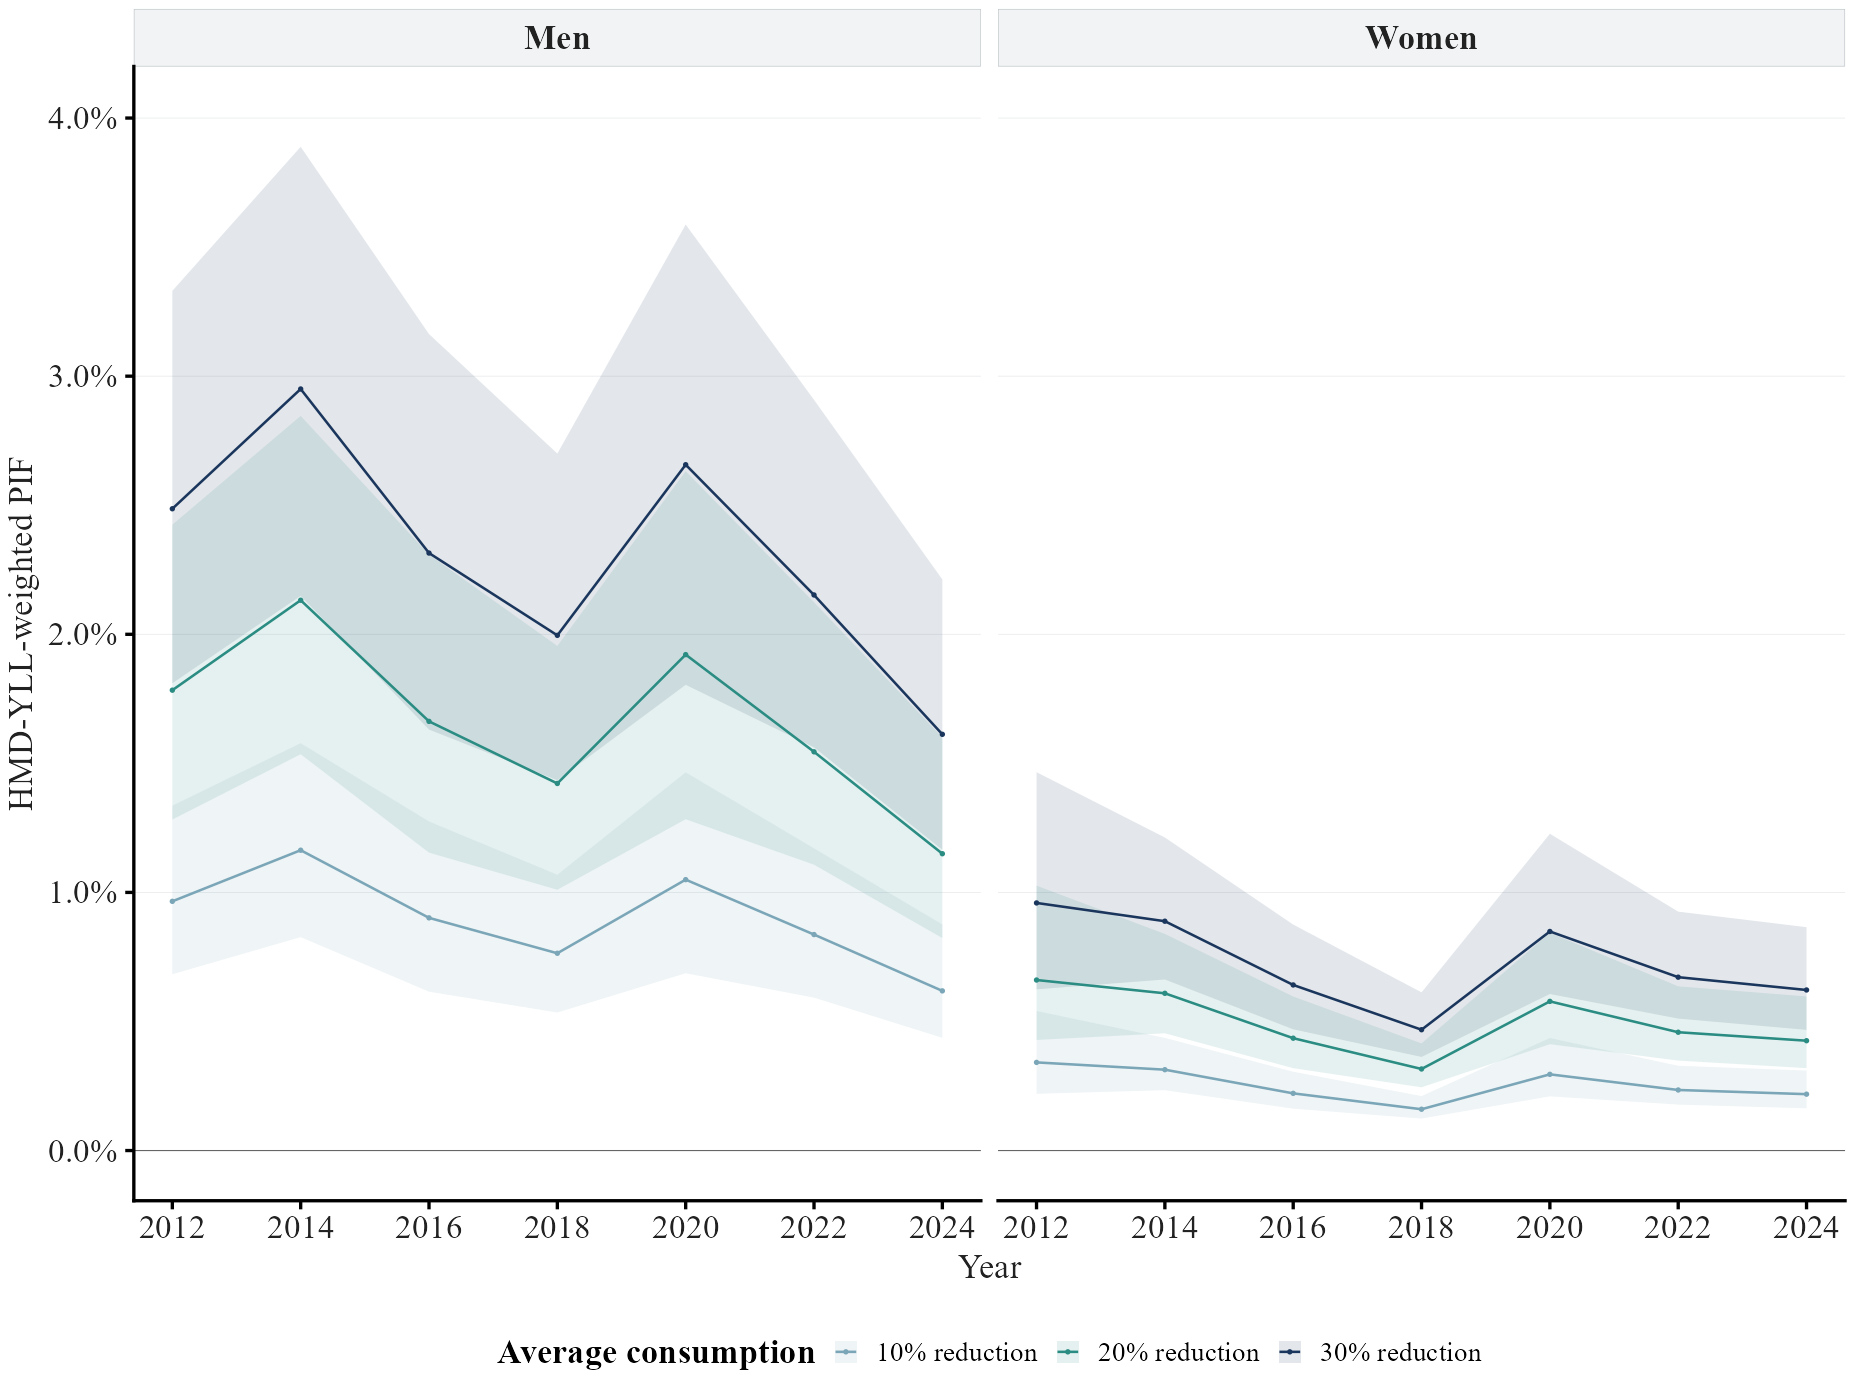

[export] Saved: figure1_volume_pif_trends.tiff and figure1_volume_pif_trends.pdf.
pif3-figure1-volume-trends elapsed minutes: 0.02


In [55]:
#| label: pif3-figure1-volume-trends
#| fig-width: 7.2
#| fig-height: 4.6
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig1_data <- pif3_burden |> dplyr::filter(.data$scenario_id %in% base::names(pif3_volume_colors), .data$applicable, base::is.finite(.data$pif)) |> pif3_weighted_pif("yll_hmd", c("year", "sex_label", "scenario_id")) |> dplyr::mutate(scenario_id = base::factor(.data$scenario_id, levels = base::names(pif3_volume_colors)))
pif3_fig1 <- ggplot2::ggplot(pif3_fig1_data, ggplot2::aes(x = .data$year, y = .data$pif, colour = .data$scenario_id, fill = .data$scenario_id, group = .data$scenario_id)) + ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.35) + ggplot2::geom_ribbon(ggplot2::aes(ymin = .data$pif_low, ymax = .data$pif_up), alpha = 0.12, colour = NA) + ggplot2::geom_line(linewidth = 0.8) + ggplot2::geom_point(size = 1.7, stroke = 0) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_x_continuous(breaks = base::sort(base::unique(pif3_fig1_data$year))) + ggplot2::scale_y_continuous(labels = scales::label_percent(accuracy = 0.1), expand = ggplot2::expansion(mult = c(0.05, 0.08))) + ggplot2::scale_colour_manual(values = pif3_volume_colors, labels = c("10% reduction", "20% reduction", "30% reduction"), name = "Average consumption") + ggplot2::scale_fill_manual(values = pif3_volume_colors, labels = c("10% reduction", "20% reduction", "30% reduction"), name = "Average consumption") + ggplot2::labs(x = "Year", y = "HMD-YLL-weighted PIF") + pif3_theme()
pif3_fig1_preview <- pif3_fig1 + pif3_theme(base_size = 23)
base::print(pif3_fig1_preview)  # readable in the notebook
pif3_save_plot(pif3_fig1, "figure1_volume_pif_trends", width = 7.2, height = 4.6)
base::message(base::sprintf("pif3-figure1-volume-trends elapsed minutes: %.2f", pif3_elapsed_min(.t0)))

### Figure 2

**Cause-specific burden-weighted PIF for a 30% reduction in average consumption in 2024.** Points summarize the four age groups using HMD YLL as weights; horizontal intervals aggregate the corresponding cell-level lower and upper limits. The vertical reference at zero makes increases in modeled burden visible. A negative PIF means that the counterfactual distribution has greater modeled risk than the observed distribution for that cause-sex combination.


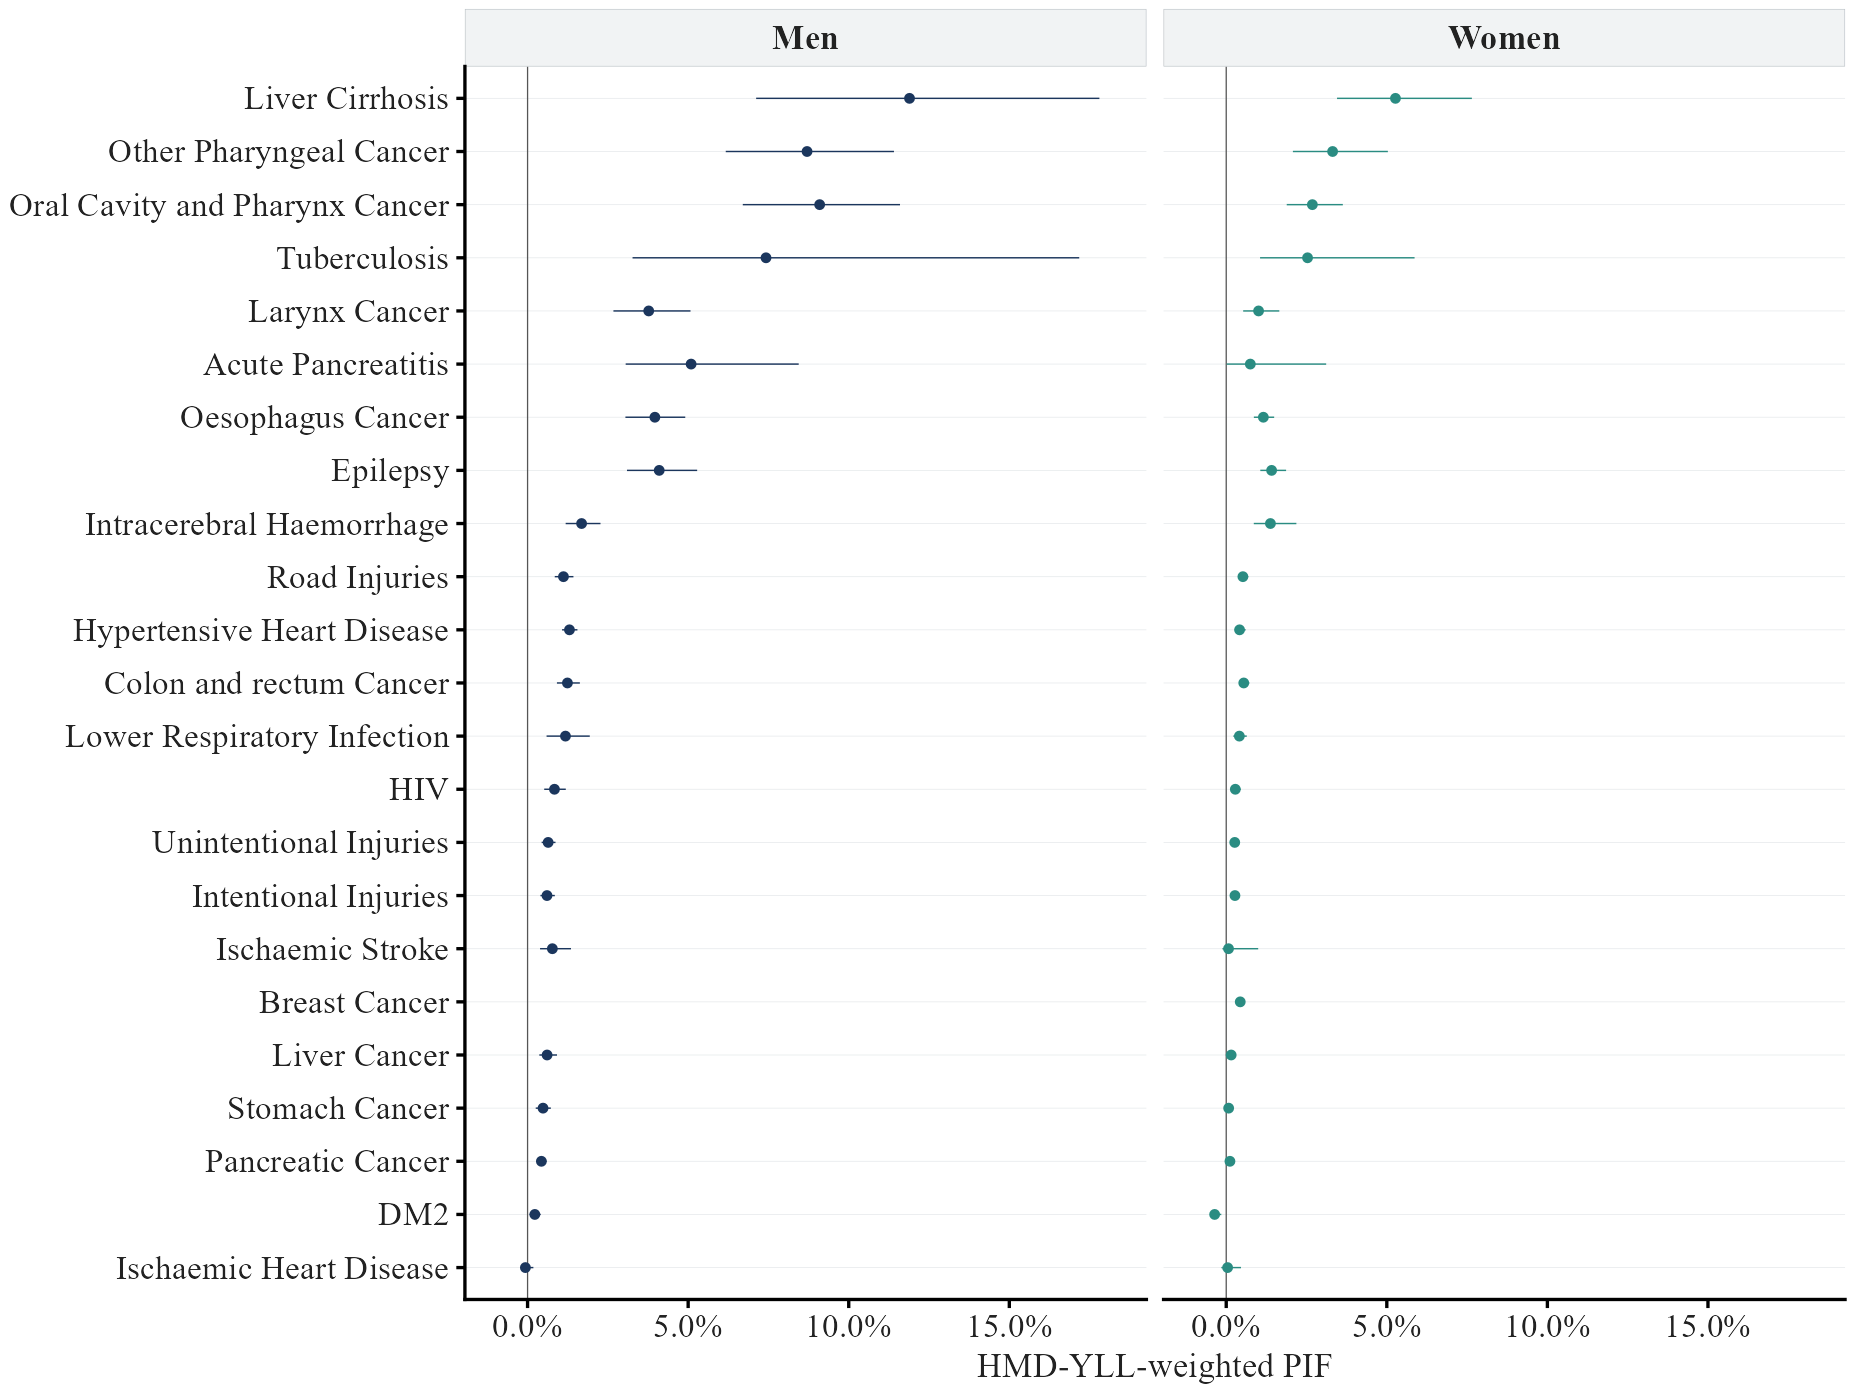

[export] Saved: figure2_cause_specific_pif_2024.tiff and figure2_cause_specific_pif_2024.pdf.
pif3-figure2-cause-pif elapsed minutes: 0.01


In [56]:
#| label: pif3-figure2-cause-pif
#| fig-width: 8.2
#| fig-height: 7.2
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig2_source <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif))
pif3_fig2_data <- pif3_fig2_source |> pif3_weighted_pif("yll_hmd", c("disease", "sex_label", "cause_category"))
pif3_fig2_order <- pif3_fig2_source |> pif3_weighted_pif("yll_hmd", c("disease")) |> dplyr::arrange(.data$pif) |> dplyr::pull(.data$disease)
pif3_fig2_data <- pif3_fig2_data |> dplyr::mutate(disease = base::factor(.data$disease, levels = pif3_fig2_order))
pif3_fig2 <- ggplot2::ggplot(pif3_fig2_data, ggplot2::aes(y = .data$disease, colour = .data$sex_label)) + ggplot2::geom_vline(xintercept = 0, colour = "#555555", linewidth = 0.4) + ggplot2::geom_segment(ggplot2::aes(x = .data$pif_low, xend = .data$pif_up, yend = .data$disease), linewidth = 0.45) + ggplot2::geom_point(ggplot2::aes(x = .data$pif), size = 2.0) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_x_continuous(labels = scales::label_percent(accuracy = 0.1), expand = ggplot2::expansion(mult = c(0.08, 0.08))) + ggplot2::scale_colour_manual(values = pif3_sex_colors, guide = "none") + ggplot2::labs(x = "HMD-YLL-weighted PIF", y = NULL) + pif3_theme(base_size = 8.5) + ggplot2::theme(panel.grid.major.y = ggplot2::element_line(colour = "#E6E9EB", linewidth = 0.25))
pif3_fig2_preview <- pif3_fig2 + pif3_theme(base_size = 23)
base::print(pif3_fig2_preview)  # readable in the notebook
pif3_save_plot(pif3_fig2, "figure2_cause_specific_pif_2024", width = 8.2, height = 7.2)
base::message(base::sprintf("pif3-figure2-cause-pif elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figure 3

**Expected avoidable deaths and national HMD YLL under a 30% reduction in average consumption in 2024.** Values are summed across sex and age groups. The 12 causes with the largest absolute national avoidable-YLL estimates are shown in both panels. Each percentage is the cause-specific contribution to the net total across all 23 modeled causes for that metric; percentages for the displayed causes therefore need not sum to 100%, and negative contributions are retained.


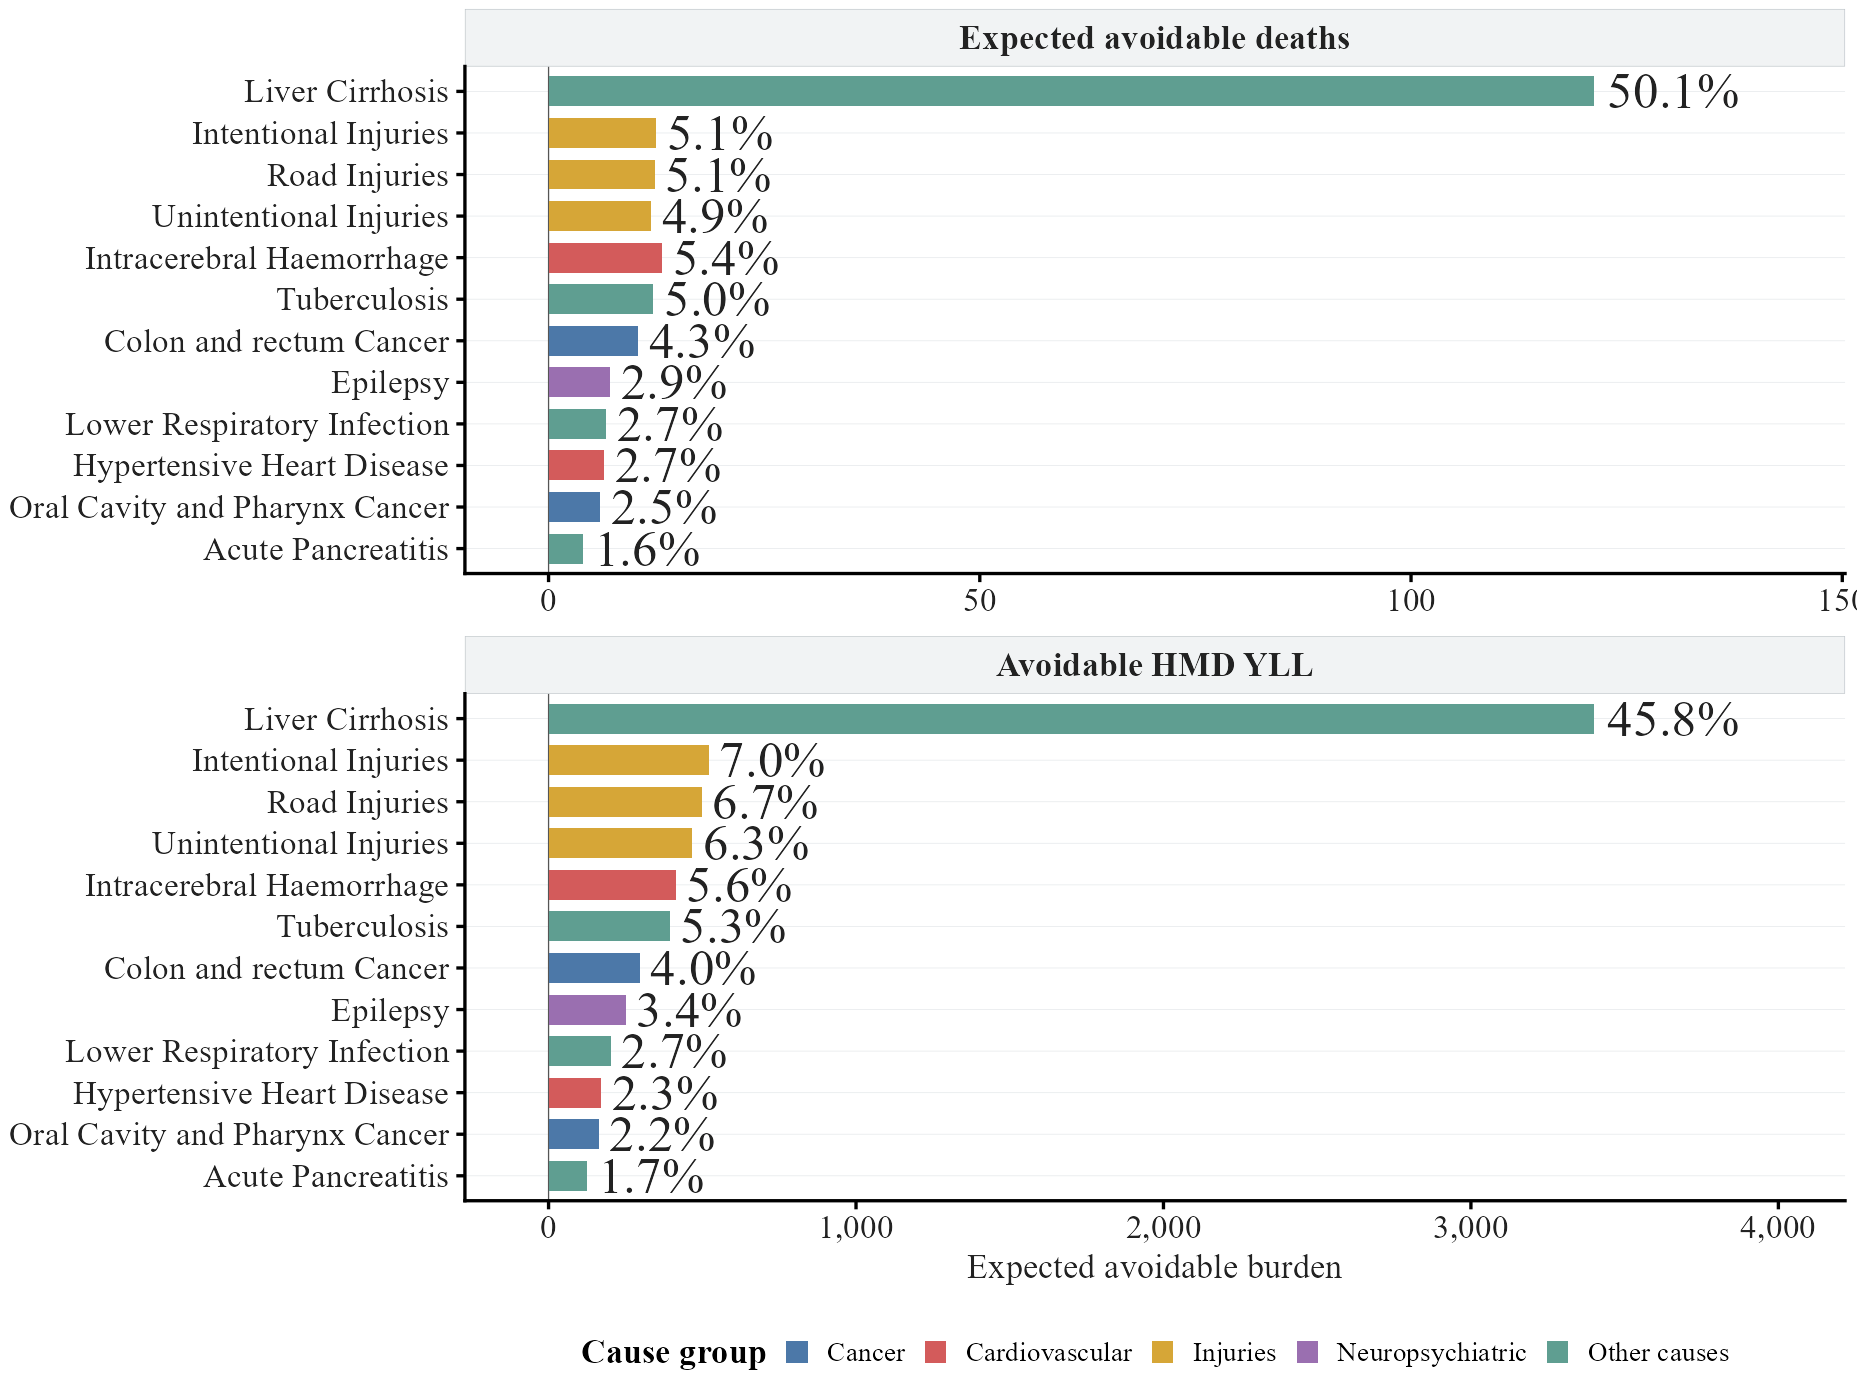

[export] Saved: figure3_avoidable_deaths_and_hmd_yll_2024.tiff and figure3_avoidable_deaths_and_hmd_yll_2024.pdf.
pif3-figure3-avoidable-burden elapsed minutes: 0.01


In [57]:
#| label: pif3-figure3-avoidable-burden
#| fig-width: 8.4
#| fig-height: 7.4
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig3_wide <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$disease, .data$cause_category) |> dplyr::summarise(avoidable_deaths = base::sum(.data$avoidable_deaths), avoidable_yll_hmd = base::sum(.data$avoidable_yll_hmd), .groups = "drop")
# Calculate net denominators over every modeled cause before selecting the 12 causes displayed in the figure.
pif3_fig3_totals <- tibble::tibble(metric = c("Expected avoidable deaths", "Avoidable HMD YLL"), total_value = c(base::sum(pif3_fig3_wide$avoidable_deaths), base::sum(pif3_fig3_wide$avoidable_yll_hmd)))
pif3_fig3_top <- pif3_fig3_wide |> dplyr::mutate(rank_value = base::abs(.data$avoidable_yll_hmd)) |> dplyr::slice_max(order_by = .data$rank_value, n = 12L, with_ties = FALSE) |> dplyr::arrange(.data$avoidable_yll_hmd) |> dplyr::pull(.data$disease)
pif3_fig3_data <- pif3_fig3_wide |> dplyr::filter(.data$disease %in% pif3_fig3_top) |> tidyr::pivot_longer(cols = c("avoidable_deaths", "avoidable_yll_hmd"), names_to = "metric", values_to = "value") |> dplyr::mutate(disease = base::factor(.data$disease, levels = pif3_fig3_top), metric = dplyr::recode(.data$metric, "avoidable_deaths" = "Expected avoidable deaths", "avoidable_yll_hmd" = "Avoidable HMD YLL")) |> dplyr::left_join(pif3_fig3_totals, by = "metric") |> dplyr::mutate(metric = base::factor(.data$metric, levels = c("Expected avoidable deaths", "Avoidable HMD YLL")), contribution_pct = 100 * .data$value / .data$total_value, contribution_label = base::sprintf("%.1f%%", .data$contribution_pct), label_hjust = dplyr::if_else(.data$value >= 0, -0.10, 1.10))
pif3_fig3 <- ggplot2::ggplot(pif3_fig3_data, ggplot2::aes(x = .data$value, y = .data$disease, fill = .data$cause_category)) + ggplot2::geom_vline(xintercept = 0, colour = "#555555", linewidth = 0.4) + ggplot2::geom_col(width = 0.72) + ggplot2::facet_wrap(ggplot2::vars(.data$metric), ncol = 1, scales = "free_x") + ggplot2::scale_x_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.08, 0.24))) + ggplot2::scale_fill_manual(values = pif3_cause_colors, name = "Cause group") + ggplot2::labs(x = "Expected avoidable burden", y = NULL) + ggplot2::coord_cartesian(clip = "off") + pif3_theme(base_size = 8.5)
pif3_fig3_preview <- pif3_fig3 + pif3_theme(base_size = 23)+ ggplot2::geom_text(ggplot2::aes(label = .data$contribution_label, hjust = .data$label_hjust), family = pif3_font_family, size = 12, colour = "#222222") 
base::print(pif3_fig3_preview)  # readable in the notebook
pif3_save_plot(pif3_fig3+ ggplot2::geom_text(ggplot2::aes(label = .data$contribution_label, hjust = .data$label_hjust), family = pif3_font_family, size = 2.65, colour = "#222222"), "figure3_avoidable_deaths_and_hmd_yll_2024", width = 8.4, height = 7.4)
base::message(base::sprintf("pif3-figure3-avoidable-burden elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figures 3A and 3B

**Age-group and sex decomposition of expected avoidable burden under a 30% reduction in average consumption in 2024.** Stacked segments represent broad cause groups and labels show the net burden across all modeled causes within each age-group and sex stratum. Figure 3A reports deaths; Figure 3B reports national HMD YLL. Negative cause-group contributions are retained.


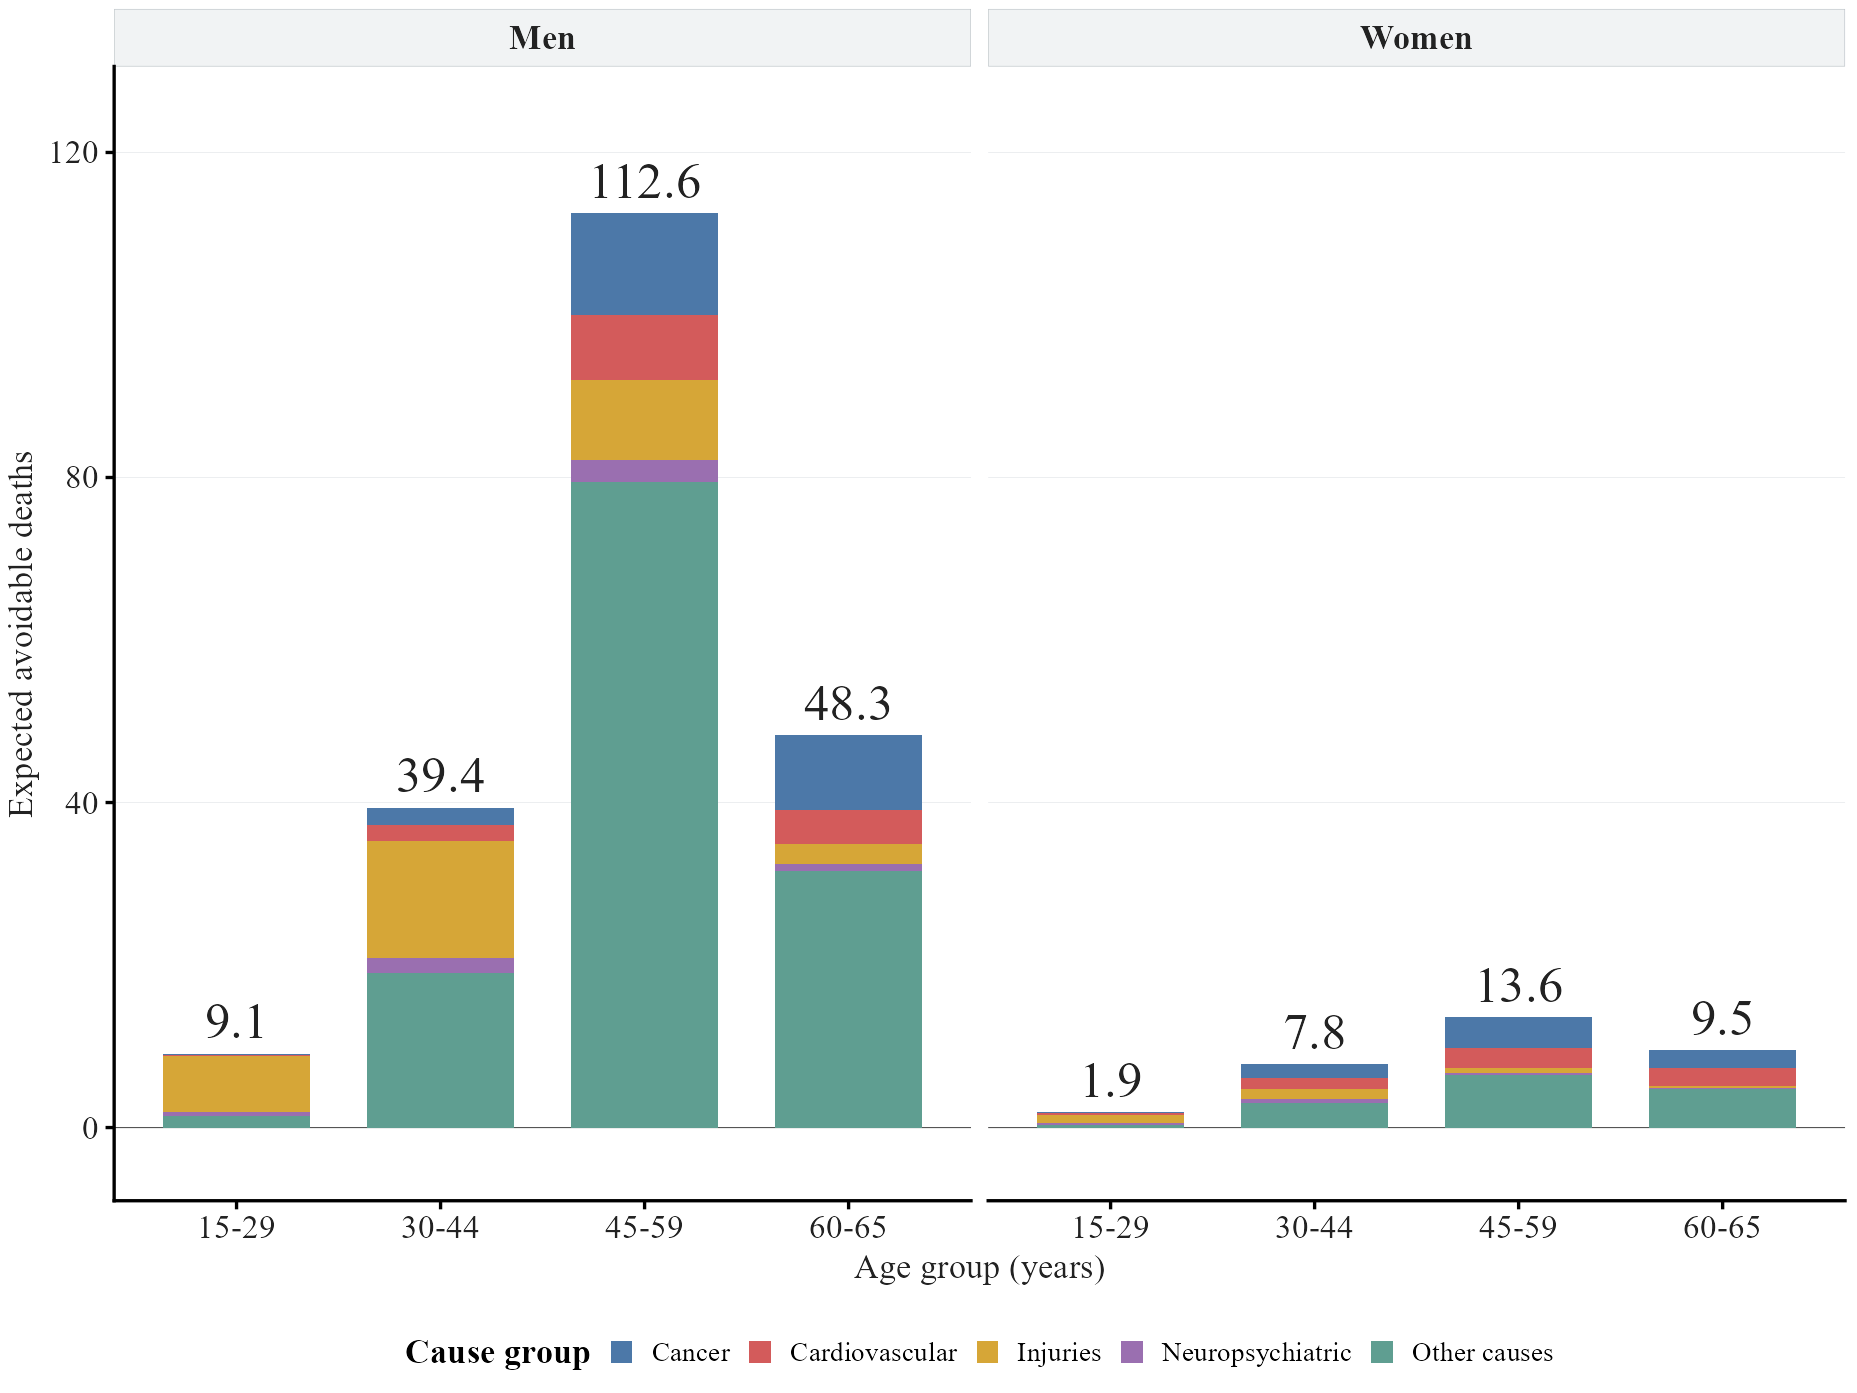

[export] Saved: figure3a_avoidable_deaths_age_sex_2024.tiff and figure3a_avoidable_deaths_age_sex_2024.pdf.
pif3-figure3a-age-sex-deaths elapsed minutes: 0.01


In [58]:
#| label: pif3-figure3a-age-sex-deaths
#| fig-width: 8.2
#| fig-height: 4.8
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig3a_data <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex_label, .data$age_label, .data$cause_category) |> dplyr::summarise(value = base::sum(.data$avoidable_deaths), .groups = "drop") |> dplyr::mutate(age_label = base::factor(.data$age_label, levels = base::unname(pif3_age_labels)))
pif3_fig3a_totals <- pif3_fig3a_data |> dplyr::group_by(.data$sex_label, .data$age_label) |> dplyr::summarise(total = base::sum(.data$value), .groups = "drop")
pif3_fig3a <- ggplot2::ggplot(pif3_fig3a_data, ggplot2::aes(x = .data$age_label, y = .data$value, fill = .data$cause_category)) + ggplot2::geom_hline(yintercept = 0, colour = "#555555", linewidth = 0.35) + ggplot2::geom_col(width = 0.72) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_y_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.08, 0.16))) + ggplot2::scale_fill_manual(values = pif3_cause_colors, name = "Cause group") + ggplot2::labs(x = "Age group (years)", y = "Expected avoidable deaths") + pif3_theme(base_size = 8.5)
pif3_fig3a_preview <- pif3_fig3a + 
  pif3_theme(base_size = 23)+ ggplot2::geom_text(data = pif3_fig3a_totals, ggplot2::aes(x = .data$age_label, y = .data$total, label = scales::number(.data$total, accuracy = 0.1), fill = NULL), vjust = -0.45, family = pif3_font_family, size = 12, colour = "#222222")
base::print(pif3_fig3a_preview)  # readable in the notebook
pif3_save_plot(
  pif3_fig3a +
    ggplot2::geom_text(
      data = pif3_fig3a_totals,
      ggplot2::aes(
        x = .data$age_label,
        y = .data$total,
        label = scales::number(.data$total, accuracy = 0.1),
        fill = NULL
      ),
      vjust = -0.45,
      family = pif3_font_family,
      size = 2.8,
      colour = "#222222"
    ),
  stem = "figure3a_avoidable_deaths_age_sex_2024", 
  width = 8.4, 
  height = 7.4
)
base::message(base::sprintf("pif3-figure3a-age-sex-deaths elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


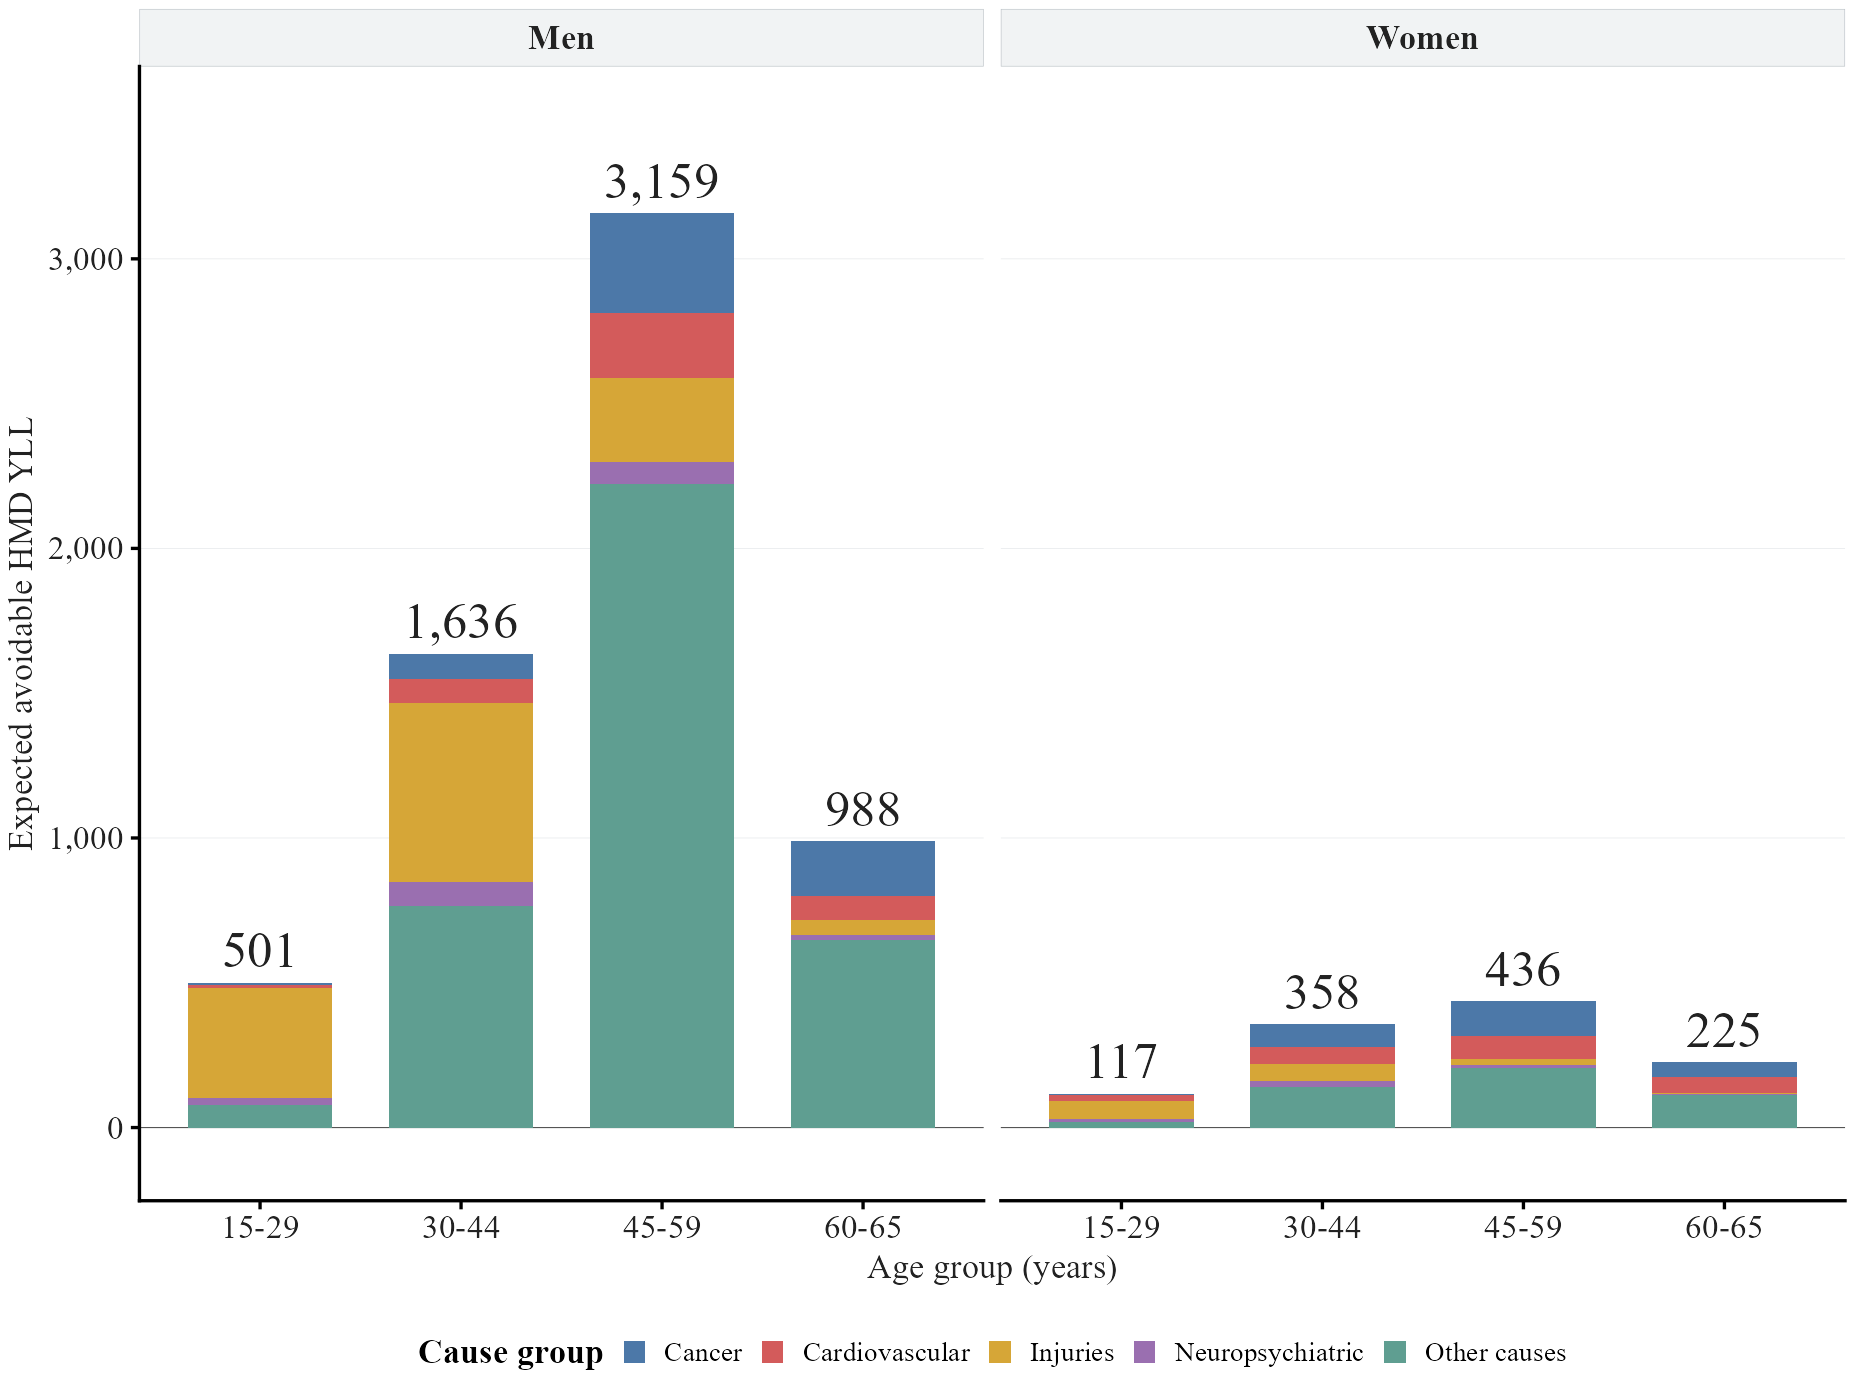

[export] Saved: figure3b_avoidable_hmd_yll_age_sex_2024.tiff and figure3b_avoidable_hmd_yll_age_sex_2024.pdf.
pif3-figure3b-age-sex-yll elapsed minutes: 0.01


In [59]:
#| label: pif3-figure3b-age-sex-yll
#| fig-width: 8.2
#| fig-height: 4.8
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig3b_data <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex_label, .data$age_label, .data$cause_category) |> dplyr::summarise(value = base::sum(.data$avoidable_yll_hmd), .groups = "drop") |> dplyr::mutate(age_label = base::factor(.data$age_label, levels = base::unname(pif3_age_labels)))
pif3_fig3b_totals <- pif3_fig3b_data |> dplyr::group_by(.data$sex_label, .data$age_label) |> dplyr::summarise(total = base::sum(.data$value), .groups = "drop")
pif3_fig3b <- ggplot2::ggplot(pif3_fig3b_data, ggplot2::aes(x = .data$age_label, y = .data$value, fill = .data$cause_category)) + ggplot2::geom_hline(yintercept = 0, colour = "#555555", linewidth = 0.35) + ggplot2::geom_col(width = 0.72) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_y_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.08, 0.16))) + ggplot2::scale_fill_manual(values = pif3_cause_colors, name = "Cause group") + ggplot2::labs(x = "Age group (years)", y = "Expected avoidable HMD YLL") + pif3_theme(base_size = 8.5)

pif3_fig3b_preview <- pif3_fig3b + 
  pif3_theme(base_size = 23)+ ggplot2::geom_text(data = pif3_fig3b_totals, ggplot2::aes(x = .data$age_label, y = .data$total, label = scales::comma(.data$total, accuracy = 1), fill = NULL), vjust = -0.45, family = pif3_font_family, size = 12, colour = "#222222") 
base::print(pif3_fig3b_preview)  # readable in the notebook

pif3_save_plot(pif3_fig3b+
  ggplot2::geom_text(data = pif3_fig3b_totals, 
    ggplot2::aes(x = .data$age_label, 
      y = .data$total, 
      label = scales::comma(.data$total, accuracy = 1), fill = NULL), 
    vjust = -0.45, 
    family = pif3_font_family, 
    size = 2.8, 
    colour = "#222222"), 
  "figure3b_avoidable_hmd_yll_age_sex_2024", 
width = 8.2, 
height = 4.8)
base::message(base::sprintf("pif3-figure3b-age-sex-yll elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figure 4

**Sensitivity of avoidable years of life lost to the YLL definition.** The same 2024 cause-sex-age PIF values from the 30% average-consumption reduction are multiplied separately by national HMD YLL, GBD standard-life-table YLL, and reference-age YPLL. Lines connect definitions only to facilitate within-sex comparison; the three quantities should never be added together.


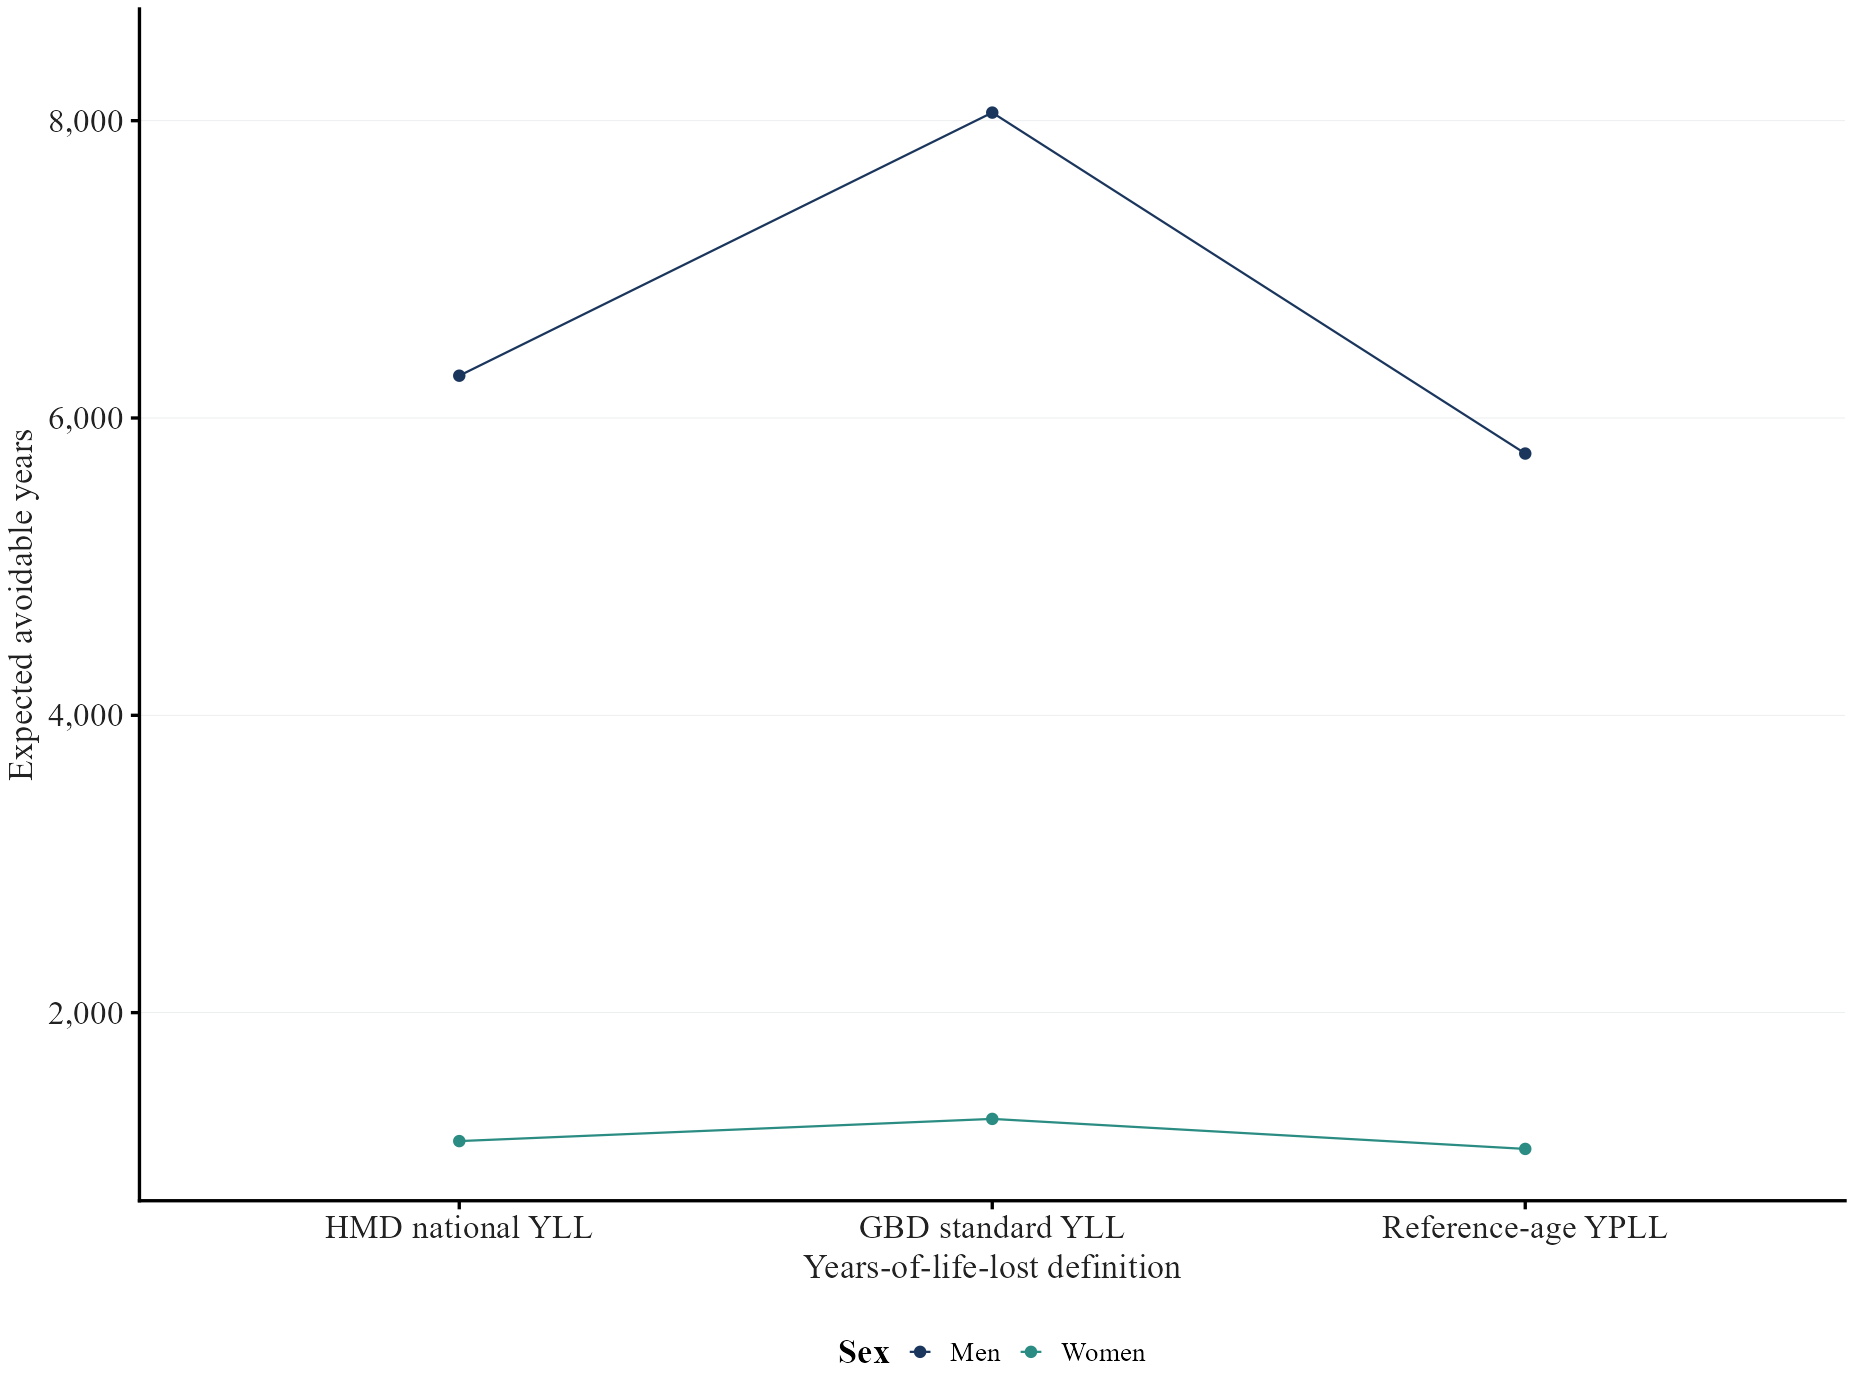

[export] Saved: figure4_yll_definition_sensitivity_2024.tiff and figure4_yll_definition_sensitivity_2024.pdf.
pif3-figure4-yll-definitions elapsed minutes: 0.01


In [60]:
#| label: pif3-figure4-yll-definitions
#| fig-width: 6.8
#| fig-height: 4.5
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig4_data <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex_label) |> dplyr::summarise(`HMD national YLL` = base::sum(.data$avoidable_yll_hmd), `GBD standard YLL` = base::sum(.data$avoidable_yll_gbd), `Reference-age YPLL` = base::sum(.data$avoidable_ypll_ref), .groups = "drop") |> tidyr::pivot_longer(cols = -c("sex_label"), names_to = "metric", values_to = "avoidable_years") |> dplyr::mutate(metric = base::factor(.data$metric, levels = c("HMD national YLL", "GBD standard YLL", "Reference-age YPLL")))
pif3_fig4 <- ggplot2::ggplot(pif3_fig4_data, ggplot2::aes(x = .data$metric, y = .data$avoidable_years, colour = .data$sex_label, group = .data$sex_label)) + ggplot2::geom_line(linewidth = 0.7) + ggplot2::geom_point(size = 2.5) + ggplot2::scale_y_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.05, 0.10))) + ggplot2::scale_colour_manual(values = pif3_sex_colors, name = "Sex") + ggplot2::labs(x = "Years-of-life-lost definition", y = "Expected avoidable years") + pif3_theme() + ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 18, hjust = 1))
pif3_fig4_preview <- pif3_fig4 + pif3_theme(base_size = 23)

base::print(pif3_fig4_preview)
pif3_save_plot(pif3_fig4, "figure4_yll_definition_sensitivity_2024", width = 6.8, height = 4.5)
base::message(base::sprintf("pif3-figure4-yll-definitions elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figure 5

**Injury PIF under reductions in HED prevalence, comparing ex-HED assignment rules in 2024.** Estimates come from the independently generated full injuries test artifact and are weighted across age groups by HMD YLL. “No shift” retains the exiting HED group's own consumption density; “Complete shift” assigns that mass to the NHED distribution. Complete-shift estimates are displaced slightly to the right and no-shift estimates slightly to the left solely to prevent graphical overlap. Intervals aggregate age-specific cell-level limits.


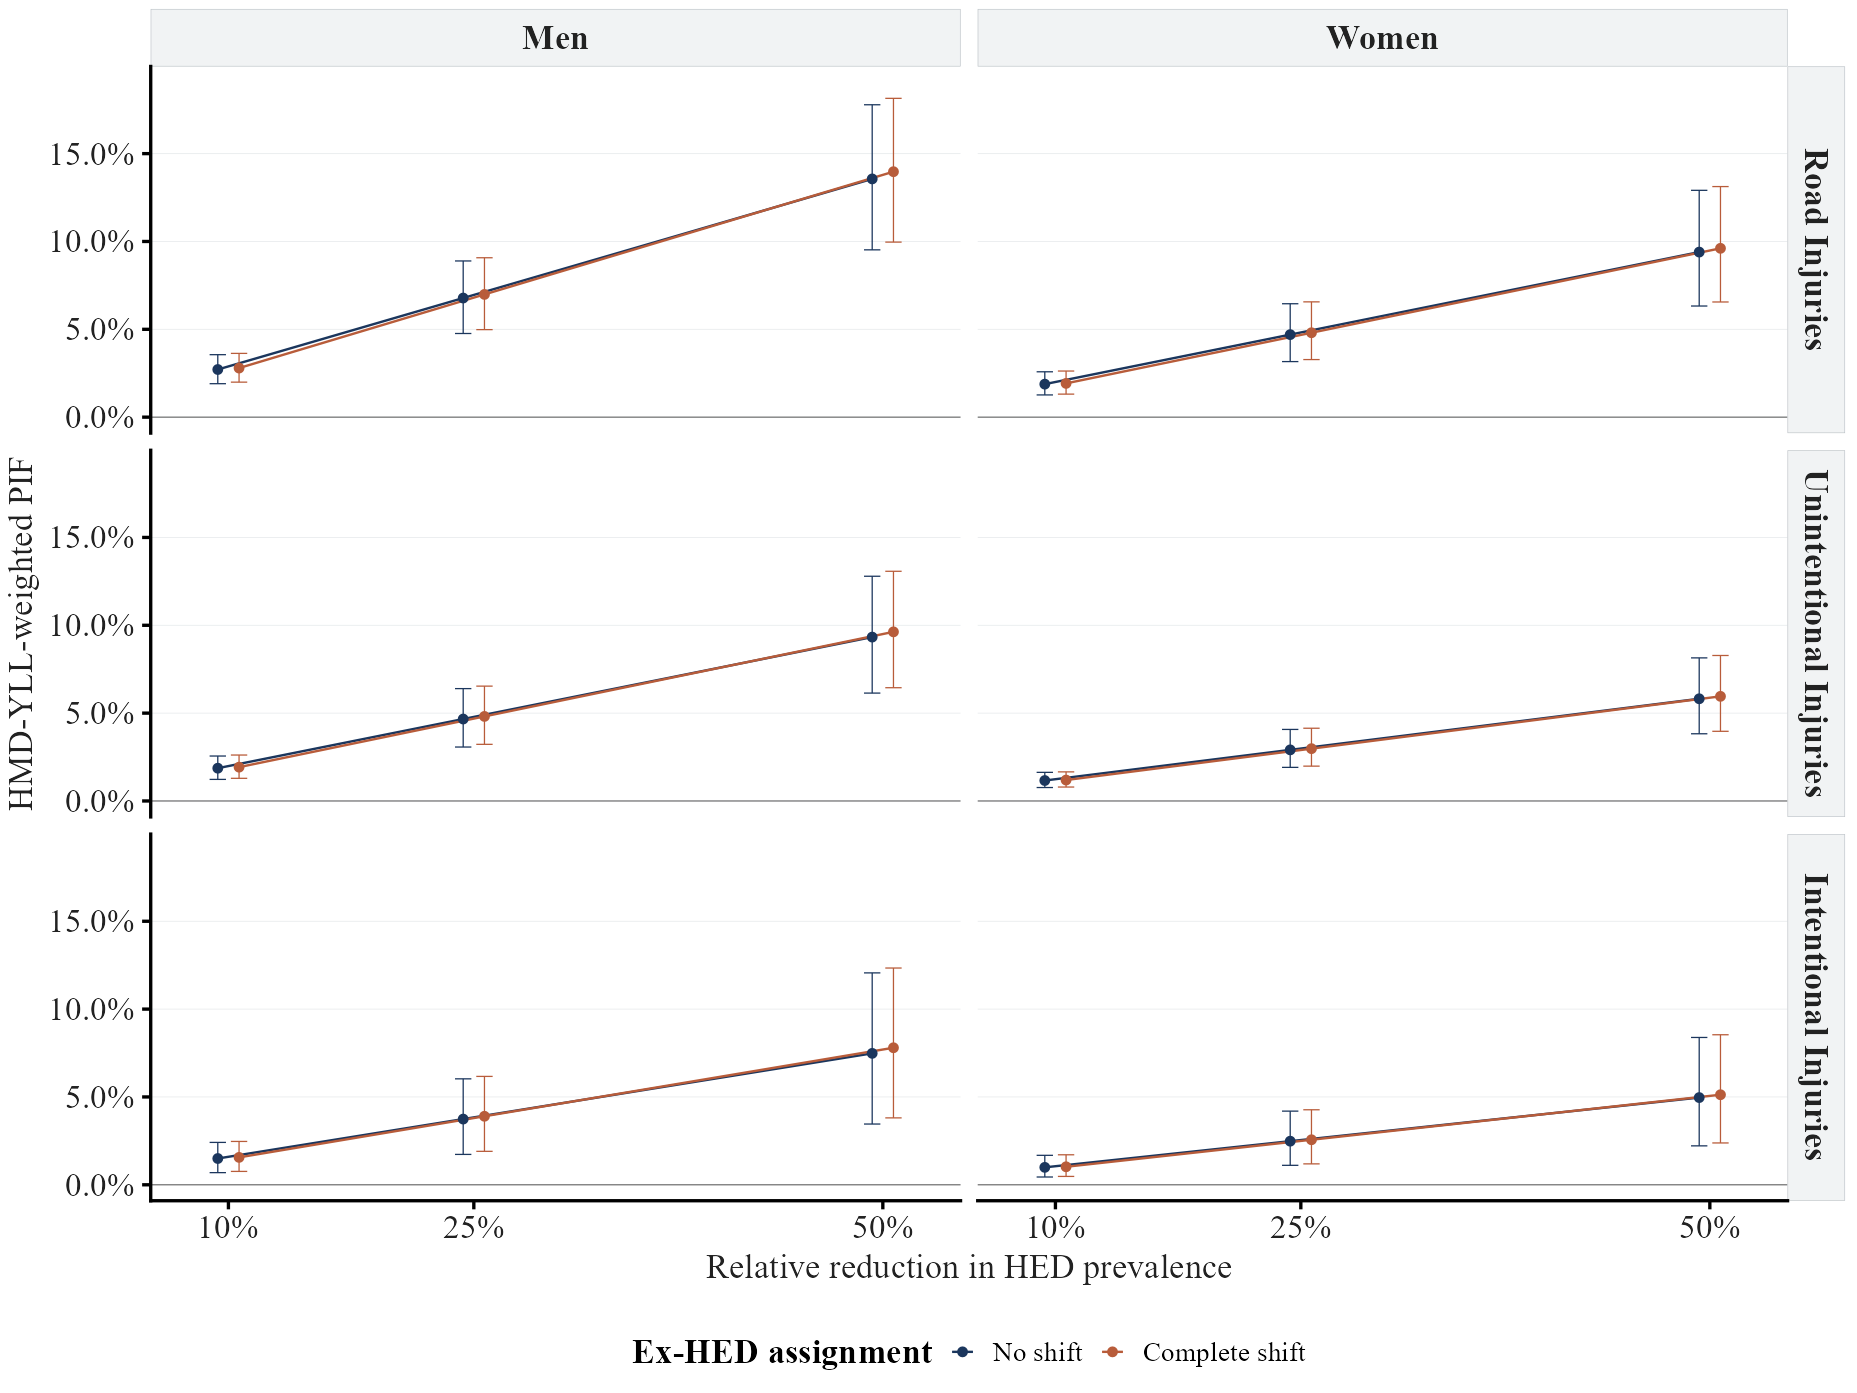

[export] Saved: figure5_injury_hed_exit_rules_2024.tiff and figure5_injury_hed_exit_rules_2024.pdf.
pif3-figure5-injury-exit-rules elapsed minutes: 0.02


In [61]:
#| label: pif3-figure5-injury-exit-rules
#| fig-width: 8.4
#| fig-height: 7.0
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig5_data <- pif3_injury_burden |> dplyr::filter(.data$year == 2024L, .data$engine_scenario == "hed", .data$scenario_id != "baseline", .data$applicable, base::is.finite(.data$pif)) |> pif3_weighted_pif("yll_hmd", c("disease", "sex_label", "exit_rule", "hed_prevalence_change_pct")) |> dplyr::mutate(exit_rule = base::factor(.data$exit_rule, levels = c("No shift", "Complete shift")), disease = base::factor(.data$disease, levels = c("Road Injuries", "Unintentional Injuries", "Intentional Injuries")), x_display = .data$hed_prevalence_change_pct + dplyr::if_else(.data$exit_rule == "Complete shift", 0.65, -0.65))
pif3_fig5 <- ggplot2::ggplot(pif3_fig5_data, ggplot2::aes(x = .data$x_display, y = .data$pif, colour = .data$exit_rule, group = .data$exit_rule)) + ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.35) + ggplot2::geom_line(linewidth = 0.75) + ggplot2::geom_errorbar(ggplot2::aes(ymin = .data$pif_low, ymax = .data$pif_up), width = 1.0, linewidth = 0.4) + ggplot2::geom_point(size = 2.0) + ggplot2::facet_grid(rows = ggplot2::vars(.data$disease), cols = ggplot2::vars(.data$sex_label)) + ggplot2::scale_x_continuous(breaks = c(10, 25, 50), labels = scales::label_number(suffix = "%"), limits = c(7.5, 52.5)) + ggplot2::scale_y_continuous(labels = scales::label_percent(accuracy = 0.1), expand = ggplot2::expansion(mult = c(0.05, 0.10))) + ggplot2::scale_colour_manual(values = pif3_exit_colors, name = "Ex-HED assignment") + ggplot2::labs(x = "Relative reduction in HED prevalence", y = "HMD-YLL-weighted PIF") + pif3_theme(base_size = 8.5)
pif3_fig5_preview <- pif3_fig5 + pif3_theme(base_size = 23)
base::print(pif3_fig5_preview)
pif3_save_plot(pif3_fig5, "figure5_injury_hed_exit_rules_2024", width = 8.4, height = 7.0)
base::message(base::sprintf("pif3-figure5-injury-exit-rules elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


## Supplementary diagnostic figure

### Figure S1

**Applicability of the 16 modeled policy scenarios by cause.** Dark cells indicate that a PIF is defined by the relative-risk structure for that cause; light cells indicate that the scenario is not applicable. HED-only and combined scenarios are unavailable for volume-only causes and remain missing in all analytical summaries.


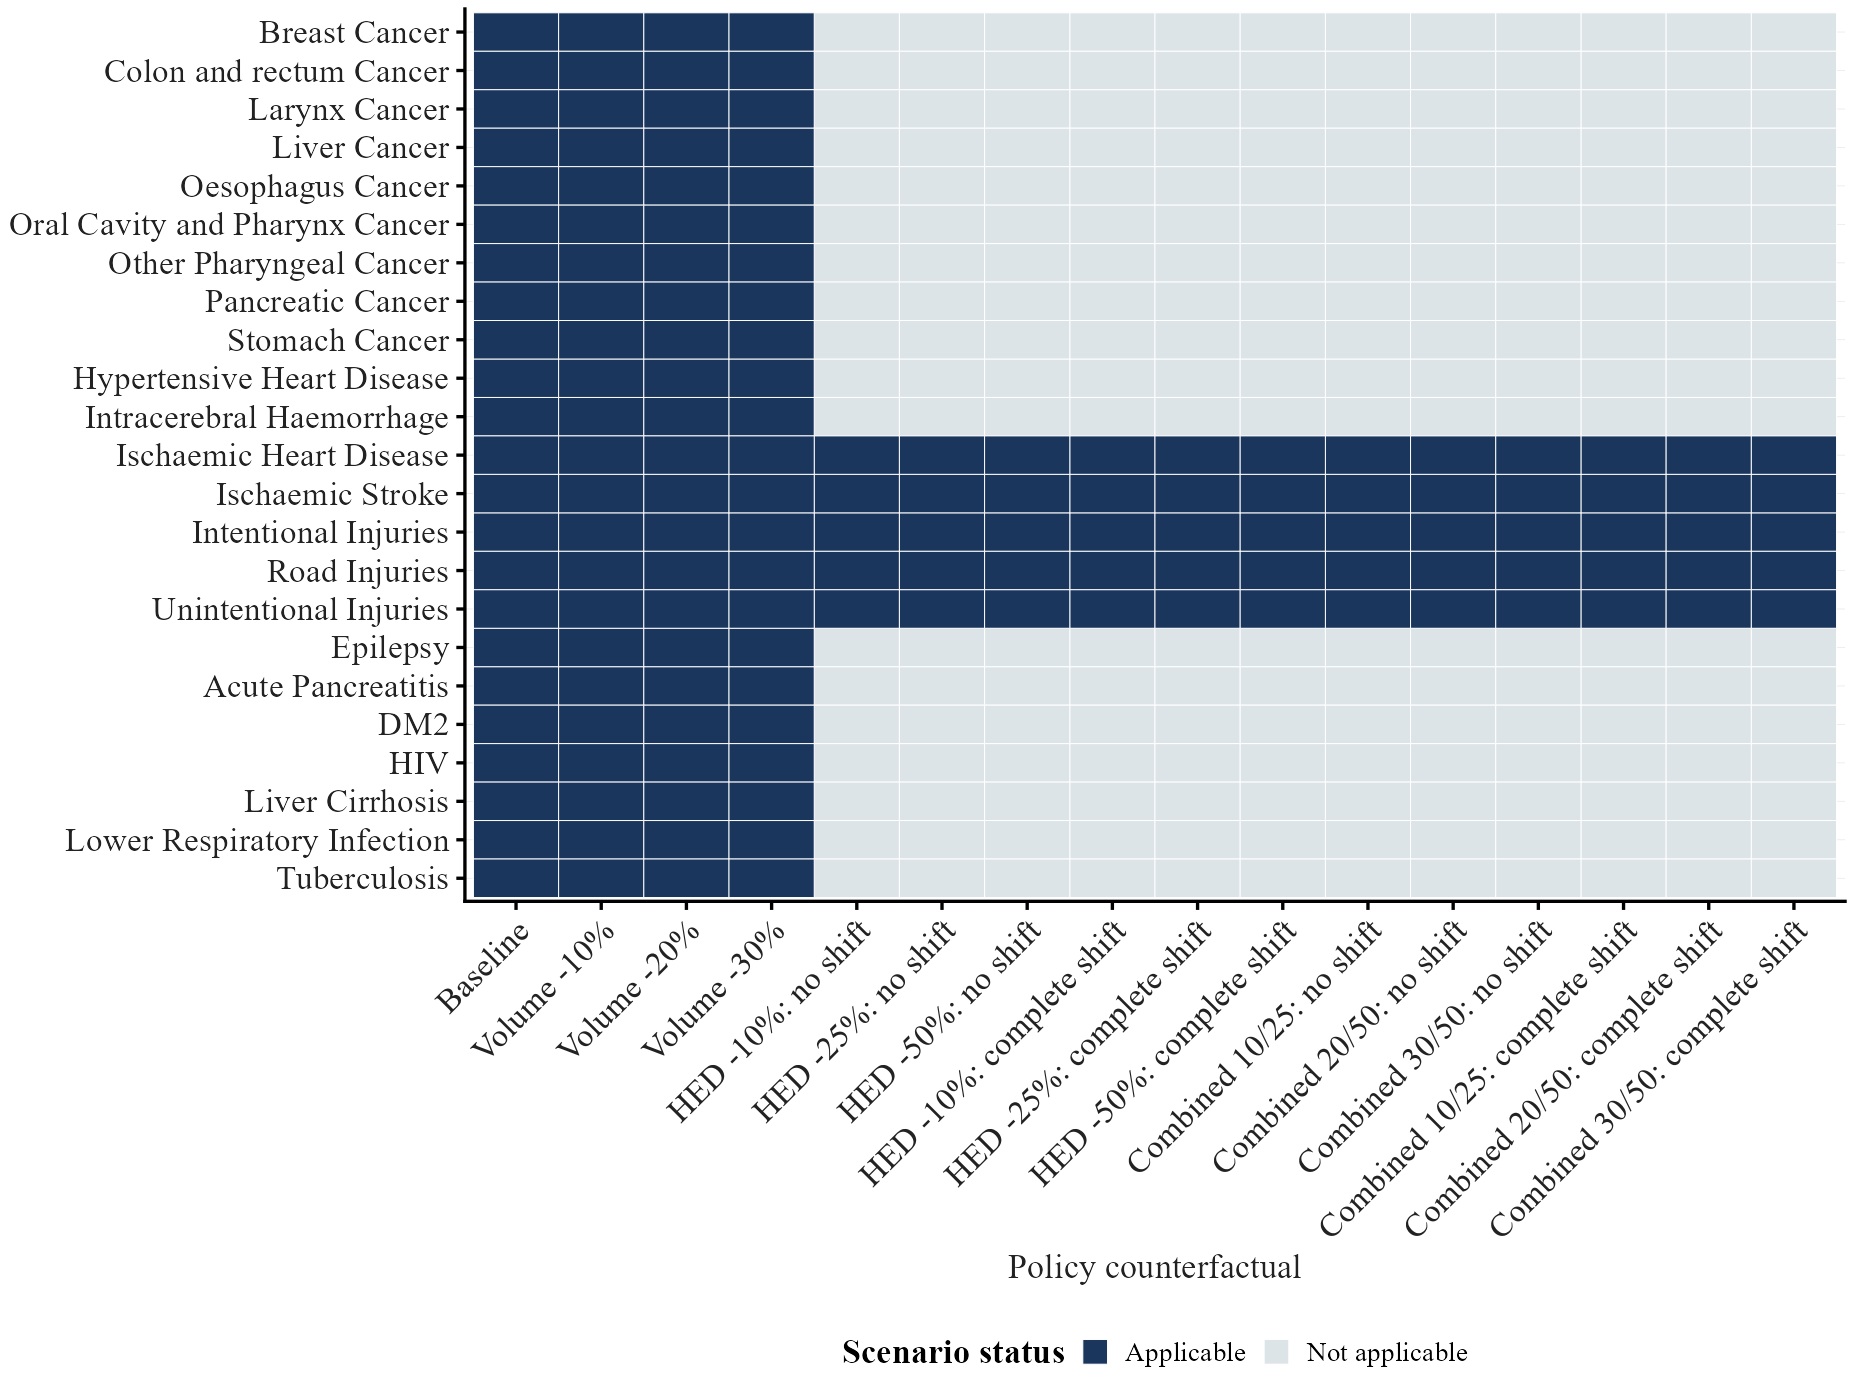

[export] Saved: figureS1_scenario_applicability.tiff and figureS1_scenario_applicability.pdf.
pif3-figure-s1-applicability elapsed minutes: 0.01


In [62]:
#| label: pif3-figure-s1-applicability
#| fig-width: 10.5
#| fig-height: 7.6
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_figs1_data <- pif3_pif_results |> dplyr::group_by(.data$disease, .data$scenario_id) |> dplyr::summarise(applicable = base::all(.data$applicable), .groups = "drop") |> dplyr::left_join(pif3_scenario_metadata |> dplyr::select(dplyr::all_of(c("scenario_id", "scenario_short", "scenario_order"))), by = "scenario_id") |> dplyr::mutate(cause_category = pif3_cause_category(.data$disease), scenario_short = base::factor(.data$scenario_short, levels = pif3_scenario_metadata |> dplyr::arrange(.data$scenario_order) |> dplyr::pull(.data$scenario_short)))
pif3_figs1_disease_order <- pif3_figs1_data |> dplyr::distinct(.data$disease, .data$cause_category) |> dplyr::arrange(base::factor(.data$cause_category, levels = c("Cancer", "Cardiovascular", "Injuries", "Neuropsychiatric", "Other causes")), .data$disease) |> dplyr::pull(.data$disease)
pif3_figs1_data <- pif3_figs1_data |> dplyr::mutate(disease = base::factor(.data$disease, levels = base::rev(pif3_figs1_disease_order)), applicability = dplyr::if_else(.data$applicable, "Applicable", "Not applicable"))
pif3_figs1 <- ggplot2::ggplot(pif3_figs1_data, ggplot2::aes(x = .data$scenario_short, y = .data$disease, fill = .data$applicability)) + ggplot2::geom_tile(colour = "white", linewidth = 0.3) + ggplot2::scale_fill_manual(values = c("Applicable" = pif3_palette[["navy"]], "Not applicable" = pif3_palette[["pale"]]), name = "Scenario status") + ggplot2::labs(x = "Policy counterfactual", y = NULL) + pif3_theme(base_size = 7.5) + ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1, vjust = 1), panel.grid = ggplot2::element_blank())

pif3_figs1_preview <- pif3_figs1 + pif3_theme(base_size = 23)+ ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1))  # 45°  turn
base::print(pif3_figs1_preview)
pif3_save_plot(pif3_figs1, "figureS1_scenario_applicability", width = 10.5, height = 7.6)
base::message(base::sprintf("pif3-figure-s1-applicability elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


## Supplementary tables

**Table S1. Avoidable YPLL rate (per 100,000 person-years) and 95% uncertainty limits by sex and counterfactual scenario, 2012–2024.** Numerators and projected-population denominators are pooled across the seven modeled years. Only cause-scenario cells marked applicable by the upstream engine are included.

**Table S2. Median annual alcohol-attributable deaths by cause group, sex, and age group, 2012–2024.** Annual cause-specific estimates are first summed within broad cause groups, then the median across the seven modeled years is reported. Fully alcohol-attributable causes are retained as a distinct group.

**Table S3. Total expected avoidable deaths by cause, counterfactual scenario, and age group, 2012–2024.** Estimates are summed over sex and the seven modeled years. Structurally non-applicable cause-scenario combinations are omitted.

For all three tables, lower and upper values are aggregated cell-level limits and should be described as uncertainty envelopes unless synchronized simulation draws are propagated upstream.


In [63]:
#| label: pif3-table-s1-ypll-rate
#| results: "asis"
# Start the timer for this chunk.
.t0 <- base::Sys.time()
# Compute the burden-weighted joint PIF (point estimate + joint synchronized-draw
# interval) for each sex x scenario group, restricted to applicable, finite-PIF
# rows, weighted by HMD-based years of life lost (yll_hmd). This is the
# numerator for the avoidable-YLL rate table.
pif3_table_s1_numerator <- pif3_burden |>
  dplyr::filter(
    .data$applicable,
    base::is.finite(.data$pif)
  ) |>
  pif3_joint_weighted_pif(
    weight_column = "yll_hmd",
    groups = c(
      "sex",
      "sex_label",
      "scenario_id",
      "scenario_short",
      "scenario_order"
    )
  )
# Count how many distinct diseases contributed applicable rows to each
# sex x scenario group, to report alongside the rate as a coverage check.
pif3_table_s1_cause_counts <- pif3_burden |>
  dplyr::filter(
    .data$applicable,
    base::is.finite(.data$pif)
  ) |>
  dplyr::group_by(
    .data$sex,
    .data$sex_label,
    .data$scenario_id,
    .data$scenario_short,
    .data$scenario_order
  ) |>
  dplyr::summarise(
    applicable_causes =
      dplyr::n_distinct(.data$disease),
    .groups = "drop"
  )
# Total person-years by sex, used as the denominator to convert avoidable YLL
# into a rate per 100,000 person-years.
pif3_table_s1_denominator <-
  pif3_population_sex_year |>
  dplyr::group_by(
    .data$sex,
    .data$sex_label
  ) |>
  dplyr::summarise(
    person_years =
      base::sum(.data$population),
    .groups = "drop"
  )
# Join the numerator, cause counts and denominator, convert the joint point
# estimate and interval into rates per 100,000 person-years, and reshape into
# the final display columns with human-readable names.
pif3_table_s1 <- pif3_table_s1_numerator |>
  dplyr::left_join(
    pif3_table_s1_cause_counts,
    by = c(
      "sex",
      "sex_label",
      "scenario_id",
      "scenario_short",
      "scenario_order"
    )
  ) |>
  dplyr::left_join(
    pif3_table_s1_denominator,
    by = c("sex", "sex_label")
  ) |>
  dplyr::mutate(
    rate_per_100000 =
      100000 * .data$avoidable_burden /
      .data$person_years,
    lower_per_100000 =
      100000 * .data$avoidable_burden_low /
      .data$person_years,
    upper_per_100000 =
      100000 * .data$avoidable_burden_up /
      .data$person_years,
    modelled_years =
      base::length(pif3_modelled_years)
  ) |>
  dplyr::arrange(
    .data$scenario_order,
    .data$sex_label
  ) |>
  dplyr::transmute(
    Sex = .data$sex_label,
    Scenario = .data$scenario_short,
    `Avoidable YLL rate per 100,000` =
      .data$rate_per_100000,
    `Joint lower 95% simulation limit` =
      .data$lower_per_100000,
    `Joint upper 95% simulation limit` =
      .data$upper_per_100000,
    `Applicable causes` =
      .data$applicable_causes,
    `Modeled years` =
      .data$modelled_years,
    `Interval method` =
      .data$interval_method
  )
# Persist the table as a CSV artifact alongside the notebook outputs.
pif3_write_table(
  pif3_table_s1,
  "tableS1_avoidable_ypll_rate_by_sex_scenario_2012_2024.csv"
)
# Render the table inline with a descriptive caption, rounded to 1 decimal.
pif3_show_table(
  pif3_table_s1,
  paste(
    "Table S1. Avoidable HMD-YLL rate per 100,000",
    "person-years with joint synchronized-draw intervals."
  ),
  digits = 1L
)
# Report elapsed time for this chunk.
base::message(base::sprintf(
  "pif3-table-s1-ypll-rate elapsed minutes: %.2f",
  pif3_elapsed_min(.t0)
))

[table export] Saved 32 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS1_avoidable_ypll_rate_by_sex_scenario_2012_2024.csv.


Sex,Scenario,"Avoidable YLL rate per 100,000",Joint lower 95% simulation limit,Joint upper 95% simulation limit,Applicable causes,Modeled years,Interval method
Men,Baseline,0.0,0.0,0.0,22,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Women,Baseline,0.0,0.0,0.0,23,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Men,Volume -10%,52.0,41.1,64.4,22,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Women,Volume -10%,6.3,5.1,8.2,23,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Men,Volume -20%,95.8,76.6,117.5,22,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Women,Volume -20%,12.3,10.0,15.8,23,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Men,Volume -30%,133.4,107.6,161.9,22,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Women,Volume -30%,17.9,14.7,22.9,23,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Men,HED -10%: no shift,69.7,59.9,79.3,5,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Women,HED -10%: no shift,10.0,8.6,11.7,5,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed


pif3-table-s1-ypll-rate elapsed minutes: 0.00


Joined mortality data with YLL and metadata of AAFs, validates that estimates of AAF reproduced the attributable mortality and map the positions of the synchronized draws. Then, groups by disease, sex and age group and for each group, calculate the annual attributable deaths using AAF draws for each cell and the observed mortality for completely attributable cells. Finally, calculate the annual median and interval limits jointly, format the table and export to CSV.

In [64]:
  #| label: pif3-table-s2-attributable-deaths                                                                                                               
  #| results: "asis"                                                                                                                                        
  .t0 <- base::Sys.time()                                                                                                                                   
  # Join the mortality workbook to the WHO/Adam synchronized AAF metadata.                                                                                  
  pif3_aaf_mortality <- pif3_mortality |>                                                                                                                   
    dplyr::left_join(                                                                                                                                       
      pif3_aaf_who$metadata |>                                                                                                                              
        dplyr::select(                                                                                                                                      
          .data$disease,                                                                                                                                    
          .data$sex,                                                                                                                                        
          .data$year,                                                                                                                                       
          .data$age_group,                                                                                                                                  
          aaf_draw_key = .data$draw_key,                                                                                                                    
          aaf_point = .data$point_estimate_raw                                                                                                              
        ),                                                                                                                                                  
      by = c("disease", "sex", "year", "age_group")                                                                                                         
    )                                                                                                                                                       
  # Mark rows represented by synchronized fractional AAF draws.                                                                                             
  pif3_aaf_fractional <- !base::is.na(pif3_aaf_mortality$aaf_draw_key)                                                                                      
  # Only fully attributable rows may legitimately lack an AAF draw.                                                                                         
  pif3_assert(                                                                                                                                              
    base::all(                                                                                                                                              
      pif3_aaf_fractional |                                                                                                                                 
        pif3_aaf_mortality$disease == "Fully attributable to alcohol"                                                                                       
    ),                                                                                                                                                      
    "An AAF mortality row lacks a synchronized draw and is not fully attributable."                                                                         
  )                                                                                                                                                         
  # A non-zero AAF point estimate is required to recover the fixed death denominator.                                                                       
  pif3_assert(                                                                                                                                              
    base::all(                                                                                                                                              
      base::is.finite(                                                                                                                                      
        pif3_aaf_mortality$aaf_point[pif3_aaf_fractional]                                                                                                   
      ) &                                                                                                                                                   
        base::abs(                                                                                                                                          
          pif3_aaf_mortality$aaf_point[pif3_aaf_fractional]                                                                                                 
        ) > 1e-12                                                                                                                                           
    ),                                                                                                                                                      
    "A synchronized AAF cell has a zero or non-finite point estimate."                                                                                      
  )                                                                                                                                                         
  # Recover observed deaths from the same mortality workbook and AAF point estimate.                                                                        
  pif3_aaf_mortality$observed_deaths <- NA_real_                                                                                                            
  pif3_aaf_implied_deaths <- (                                                                                                                              
    pif3_aaf_mortality$mort[pif3_aaf_fractional] /                                                                                                          
      pif3_aaf_mortality$aaf_point[pif3_aaf_fractional]                                                                                                     
  )                                                                                                                                                         
  pif3_aaf_implied_residual <- base::max(                                                                                                                   
    base::abs(                                                                                                                                              
      pif3_aaf_implied_deaths -                                                                                                                             
        base::round(pif3_aaf_implied_deaths)                                                                                                                
    )                                                                                                                                                       
  )                                                                                                                                                         
  pif3_assert(                                                                                                                                              
    base::is.finite(pif3_aaf_implied_residual) &&                                                                                                           
      pif3_aaf_implied_residual <= 1e-10,                                                                                                                   
    base::sprintf(                                                                                                                                          
      "Mortality/AAF scaling does not recover integer death counts; maximum residual = %.3e.",                                                              
      pif3_aaf_implied_residual                                                                                                                             
    )                                                                                                                                                       
  )                                                                                                                                                         
  pif3_aaf_mortality$observed_deaths[pif3_aaf_fractional] <- base::round(                                                                                   
    pif3_aaf_implied_deaths                                                                                                                                 
  )                                                                                                                                                         
  # Confirm that recovered deaths reproduce every fractional attributable-mortality point estimate.                                                         
  pif3_aaf_point_residual <- base::max(                                                                                                                     
    base::abs(                                                                                                                                              
      pif3_aaf_mortality$mort[pif3_aaf_fractional] -                                                                                                        
        pif3_aaf_mortality$observed_deaths[pif3_aaf_fractional] *                                                                                           
        pif3_aaf_mortality$aaf_point[pif3_aaf_fractional]                                                                                                   
    )                                                                                                                                                       
  )                                                                                                                                                         
  pif3_assert(                                                                                                                                              
    base::is.finite(pif3_aaf_point_residual) &&                                                                                                             
      pif3_aaf_point_residual <= 1e-10,                                                                                                                     
    base::sprintf(                                                                                                                                          
      "Recovered death counts do not reproduce attributable mortality; maximum residual = %.3e.",                                                           
      pif3_aaf_point_residual                                                                                                                               
    )                                                                                                                                                       
  )                                                                                                                                                         
  # Map each fractional mortality row to its synchronized AAF draw vector.                                                                                  
  pif3_aaf_draw_position <- base::unname(                                                                                                                   
    pif3_aaf_who$position[pif3_aaf_mortality$aaf_draw_key]                                                                                                  
  )                                                                                                                                                         
  pif3_assert(                                                                                                                                              
    !base::anyNA(pif3_aaf_draw_position[pif3_aaf_fractional]),                                                                                              
    "One or more AAF mortality cells cannot be mapped to synchronized draws."                                                                               
  )                                                                                                                                                         
  # Group the statistic exactly as Table S2 reports it.                                                                                                     
  pif3_aaf_grouped <- pif3_aaf_mortality |>                                                                                                                 
    dplyr::group_by(                                                                                                                                        
      .data$cause_group,                                                                                                                                    
      .data$sex_label,                                                                                                                                      
      .data$age_group,                                                                                                                                      
      .data$age_label                                                                                                                                       
    )                                                                                                                                                       
  pif3_aaf_group_keys <- dplyr::group_keys(pif3_aaf_grouped)                                                                                                
  pif3_aaf_group_rows <- dplyr::group_rows(pif3_aaf_grouped)                                                                                                
  # For each draw, calculate annual totals and then the median across modeled years.                                                                        
  pif3_table_s2_summary <- base::lapply(                                                                                                                    
    base::seq_along(pif3_aaf_group_rows),                                                                                                                   
    function(group_index) {                                                                                                                                 
      rows <- pif3_aaf_group_rows[[group_index]]                                                                                                            
      years <- base::sort(                                                                                                                                  
        base::unique(pif3_aaf_mortality$year[rows])                                                                                                         
      )                                                                                                                                                     
      annual_draws <- base::matrix(                                                                                                                         
        0,                                                                                                                                                  
        nrow = base::length(years),                                                                                                                         
        ncol = base::as.integer(pif3_aaf_who$bundle$n_sim),                                                                                                 
        dimnames = list(base::as.character(years), NULL)                                                                                                    
      )                                                                                                                                                     
      for (row_index in rows) {                                                                                                                             
        year_position <- base::match(                                                                                                                       
          pif3_aaf_mortality$year[[row_index]],                                                                                                             
          years                                                                                                                                             
        )                                                                                                                                                   
        if (pif3_aaf_fractional[[row_index]]) {                                                                                                                   
            draw_vector <- pif3_aaf_who$bundle$aaf_draws[[pif3_aaf_draw_position[[row_index]]]]                                                                     
            pif3_assert(                                                                                                                                            
              base::is.numeric(draw_vector) &&                                                                                                                      
                base::length(draw_vector) == base::as.integer(pif3_aaf_who$bundle$n_sim),                                                                           
              "An AAF draw vector is not numeric or has an unexpected length."                                                                                      
            )                                                                                                                                                       
            annual_draws[year_position, ] <- annual_draws[year_position, ] +                                                                                        
              pif3_aaf_mortality$observed_deaths[[row_index]] * draw_vector                                                                                         
          } else {                                                                                                                                                  
            annual_draws[year_position, ] <- annual_draws[year_position, ] +                                                                                        
              pif3_aaf_mortality$mort[[row_index]]                                                                                                                  
          }              
      }                                                                                                                                                     
      median_draw <- base::apply(                                                                                                                           
        annual_draws,                                                                                                                                       
        MARGIN = 2L,                                                                                                                                        
        FUN = stats::median                                                                                                                                 
      )                                                                                                                                                     
      point_annual <- base::tapply(                                                                                                                         
        pif3_aaf_mortality$mort[rows],                                                                                                                      
        pif3_aaf_mortality$year[rows],                                                                                                                      
        base::sum                                                                                                                                           
      )                                                                                                                                                     
      limits <- stats::quantile(                                                                                                                            
        median_draw,                                                                                                                                        
        probs = c(0.025, 0.975),                                                                                                                            
        names = FALSE,                                                                                                                                      
        type = 7L                                                                                                                                           
      )                                                                                                                                                     
      tibble::tibble(                                                                                                                                       
        median_annual_deaths = stats::median(point_annual),                                                                                                 
        lower_95 = limits[[1L]],                                                                                                                            
        upper_95 = limits[[2L]],                                                                                                                            
        modelled_years = base::length(years),                                                                                                               
        interval_method = paste(                                                                                                                            
          "Joint 2.5% and 97.5% quantiles of the draw-wise",                                                                                                
          "median annual AAF-attributable deaths"                                                                                                           
        )                                                                                                                                                   
      )                                                                                                                                                     
    }                                                                                                                                                       
  )                                                                                                                                                         
  pif3_table_s2 <- dplyr::bind_cols(                                                                                                                        
    pif3_aaf_group_keys,                                                                                                                                    
    dplyr::bind_rows(pif3_table_s2_summary)                                                                                                                 
  ) |>                                                                                                                                                      
    dplyr::arrange(                                                                                                                                         
      .data$cause_group,                                                                                                                                    
      .data$sex_label,                                                                                                                                      
      .data$age_group                                                                                                                                       
    ) |>                                                                                                                                                    
    dplyr::transmute(                                                                                                                                       
      `Cause group` = .data$cause_group,                                                                                                                    
      Sex = .data$sex_label,                                                                                                                                
      `Age group (years)` = .data$age_label,                                                                                                                
      `Median annual alcohol-attributable deaths` =                                                                                                         
        .data$median_annual_deaths,                                                                                                                         
      `Joint lower 95% simulation limit` = .data$lower_95,                                                                                                  
      `Joint upper 95% simulation limit` = .data$upper_95,                                                                                                  
      `Modeled years` = .data$modelled_years,                                                                                                               
      `Interval method` = .data$interval_method                                                                                                             
    )                                                                                                                                                       
  pif3_write_table(                                                                                                                                         
    pif3_table_s2,                                                                                                                                          
    "tableS2_median_annual_alcohol_attributable_deaths_2012_2024.csv"                                                                                       
  )                                                                                                                                                         
  pif3_show_table(                                                                                                                                          
    pif3_table_s2,                                                                                                                                          
    paste(                                                                                                                                                  
      "Table S2. Median annual alcohol-attributable deaths",                                                                                                
      "with joint synchronized AAF-draw intervals."                                                                                                         
    ),                                                                                                                                                      
    digits = 1L                                                                                                                                             
  )                                                                                                                                                         
  base::message(base::sprintf(                                                                                                                              
    "pif3-table-s2-attributable-deaths elapsed minutes: %.2f",                                                                                              
    pif3_elapsed_min(.t0)                                                                                                                                   
  ))

[table export] Saved 48 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS2_median_annual_alcohol_attributable_deaths_2012_2024.csv.


Cause group,Sex,Age group (years),Median annual alcohol-attributable deaths,Joint lower 95% simulation limit,Joint upper 95% simulation limit,Modeled years,Interval method
Cancer,Men,15-29,3.7,3.0,4.2,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Men,30-44,27.3,21.3,30.2,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Men,45-59,160.7,134.7,188.0,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Men,60-65,149.4,119.8,189.6,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Women,15-29,1.5,0.9,1.9,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Women,30-44,17.6,12.7,22.4,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Women,45-59,84.2,59.8,111.2,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cancer,Women,60-65,78.4,50.5,99.2,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cardiovascular,Men,15-29,3.4,2.5,4.4,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths
Cardiovascular,Men,30-44,23.0,17.6,28.7,7,Joint 2.5% and 97.5% quantiles of the draw-wise median annual AAF-attributable deaths


pif3-table-s2-attributable-deaths elapsed minutes: 0.11


In [65]:
#| label: pif3-table-s3-avoidable-deaths
#| results: "asis"
# Start the timer for this chunk.
.t0 <- base::Sys.time()
# Identify (disease, age_group) cells with zero total observed deaths across
# all years and sexes. These cells have nothing to avoid by construction (no
# deaths at all in that cause x age band), so they cannot support a
# burden-weighted joint PIF (the weight column would sum to zero) and are
# excluded from this table rather than passed into pif3_joint_weighted_pif().
pif3_table_s3_zero_burden <- pif3_burden |>
  dplyr::filter(
    .data$applicable,
    base::is.finite(.data$pif)
  ) |>
  dplyr::group_by(
    .data$disease,
    .data$age_group,
    .data$age_label
  ) |>
  dplyr::filter(
    base::sum(.data$deaths) == 0
  ) |>
  dplyr::ungroup()
# Log exactly which cause x age-group cells were excluded and why, so the
# omission is auditable rather than silent.
pif3_message(
  "[table S3] Excluding %d cause x age-group cell(s) with zero observed deaths: %s.",
  pif3_table_s3_zero_burden |>
    dplyr::distinct(.data$disease, .data$age_group) |>
    base::nrow(),
  pif3_table_s3_zero_burden |>
    dplyr::distinct(.data$disease, .data$age_label) |>
    dplyr::mutate(
      label = base::paste(.data$disease, .data$age_label, sep = " @ ")
    ) |>
    dplyr::pull(.data$label) |>
    base::paste(collapse = "; ")
)
# Burden-weighted joint PIF (point estimate + joint synchronized-draw interval)
# for each disease x scenario x age-group cell, restricted to applicable,
# finite-PIF rows with non-zero observed deaths, weighted by deaths -- this
# gives total expected avoidable deaths per cell instead of a rate.
pif3_table_s3 <- pif3_burden |>
  dplyr::filter(
    .data$applicable,
    base::is.finite(.data$pif)
  ) |>
  dplyr::group_by(
    .data$disease,
    .data$age_group
  ) |>
  dplyr::filter(
    base::sum(.data$deaths) > 0
  ) |>
  dplyr::ungroup() |>
  pif3_joint_weighted_pif(
    weight_column = "deaths",
    groups = c(
      "disease",
      "cause_category",
      "scenario_id",
      "scenario_short",
      "scenario_order",
      "age_group",
      "age_label"
    )
  ) |>
  dplyr::arrange(
    .data$scenario_order,
    .data$disease,
    .data$age_group
  ) |>
  dplyr::transmute(
    Cause = .data$disease,
    `Cause group` = .data$cause_category,
    Scenario = .data$scenario_short,
    `Age group (years)` = .data$age_label,
    `Total expected avoidable deaths` =
      .data$avoidable_burden,
    `Joint lower 95% simulation limit` =
      .data$avoidable_burden_low,
    `Joint upper 95% simulation limit` =
      .data$avoidable_burden_up,
    `Contributing cells` = .data$cells,
    `Interval method` = .data$interval_method
  )
# Persist the table as a CSV artifact alongside the notebook outputs.
pif3_write_table(
  pif3_table_s3,
  "tableS3_total_avoidable_deaths_by_cause_scenario_age_2012_2024.csv"
)
# Render the table inline with a descriptive caption, rounded to 1 decimal.
pif3_show_table(
  pif3_table_s3,
  paste(
    "Table S3. Total expected avoidable deaths by cause,",
    "scenario, and age group with joint simulation intervals.",
    "Cause x age-group cells with zero observed deaths are excluded",
    "(see console log for the excluded cells)."
  ),
  digits = 1L
)
# Report elapsed time for this chunk.
base::message(base::sprintf(
  "pif3-table-s3-avoidable-deaths elapsed minutes: %.2f",
  pif3_elapsed_min(.t0)
))

[table S3] Excluding 1 cause x age-group cell(s) with zero observed deaths: Larynx Cancer @ 15-29.
[table export] Saved 604 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS3_total_avoidable_deaths_by_cause_scenario_age_2012_2024.csv.


Cause,Cause group,Scenario,Age group (years),Total expected avoidable deaths,Joint lower 95% simulation limit,Joint upper 95% simulation limit,Contributing cells,Interval method
Acute Pancreatitis,Other causes,Baseline,15-29,0.0,0.0,0.0,14,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Acute Pancreatitis,Other causes,Baseline,30-44,0.0,0.0,0.0,14,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Acute Pancreatitis,Other causes,Baseline,45-59,0.0,0.0,0.0,14,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Acute Pancreatitis,Other causes,Baseline,60-65,0.0,0.0,0.0,14,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Breast Cancer,Cancer,Baseline,15-29,0.0,0.0,0.0,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Breast Cancer,Cancer,Baseline,30-44,0.0,0.0,0.0,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Breast Cancer,Cancer,Baseline,45-59,0.0,0.0,0.0,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Breast Cancer,Cancer,Baseline,60-65,0.0,0.0,0.0,7,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Colon and rectum Cancer,Cancer,Baseline,15-29,0.0,0.0,0.0,14,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed
Colon and rectum Cancer,Cancer,Baseline,30-44,0.0,0.0,0.0,14,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam (main) PIF draws; burden weights fixed


pif3-table-s3-avoidable-deaths elapsed minutes: 0.01


## Table 5 (Chile 2014, PUC) IHD/IS relative-risk

In [66]:
#| label: pif3-load-table5

.t0 <- Sys.time()
# The Table 5 (Chile 2014, PUC) IHD/IS relative-risk experiment is written by
# expand_pif2.ipynb under its own dated stem, so the main-grid selector cannot pick
# it up by accident. Both grids come from the same engine, the same scenario grid,
# and the same Monte Carlo configuration; only the IHD/IS RR functions differ.
pif3_table5_path <- pif3_latest_dated_file(pif3_dirs$control, "pif2_pif_results_table5_full")
pif3_table5_results <- pif3_read_rds(pif3_table5_path)
pif3_table5_diseases <- c("Ischaemic Heart Disease", "Ischaemic Stroke")
# Columns produced only by the Table 5 run. They would collide with the exit_rule that
# pif3_scenario_metadata derives from scenario_id, so they are dropped before enrichment.
pif3_table5_run_columns <- c("hed_exit_mix", "hed_exit_shift", "exit_rule", "scale",
                             "rr_source", "policy_vol_lever_pct", "implied_vol_change_pct")
pif3_cv_keys <- c("disease", "sex", "age_group", "year", "scenario_id")
pif3_cv_main_raw <- pif3_pif_results |>
  tibble::as_tibble() |>
  dplyr::filter(.data$disease %in% pif3_table5_diseases)
pif3_cv_table5_raw <- pif3_table5_results |> tibble::as_tibble()
pif3_key_vector <- function(data) {
  # Compare key sets as sorted text. pif3_read_rds attaches a "path" attribute that
  # survives dplyr verbs, so identical() on data frames would compare provenance, not keys.
  base::sort(base::do.call(base::paste, c(data[pif3_cv_keys], sep = "|")))
}
pif3_cv_applicable_t5 <- pif3_cv_table5_raw$applicable & base::is.finite(pif3_cv_table5_raw$pif)
pif3_table5_report <- tibble::tibble(
  check = c("table5_expected_diseases", "table5_unique_keys", "table5_keys_match_main",
            "table5_scenarios_match", "table5_years_match", "table5_nsim_match",
            "table5_applicability_matches", "table5_interval_ordering",
            "table5_baseline_is_zero", "table5_rr_source_labelled"),
  pass = c(
    base::setequal(base::unique(pif3_cv_table5_raw$disease), pif3_table5_diseases),
    base::anyDuplicated(pif3_cv_table5_raw[pif3_cv_keys]) == 0L,
    base::identical(pif3_key_vector(pif3_cv_main_raw), pif3_key_vector(pif3_cv_table5_raw)),
    base::setequal(base::unique(pif3_cv_main_raw$scenario_id), base::unique(pif3_cv_table5_raw$scenario_id)),
    base::setequal(base::unique(pif3_cv_main_raw$year), base::unique(pif3_cv_table5_raw$year)),
    base::setequal(base::unique(pif3_cv_main_raw$n_sim), base::unique(pif3_cv_table5_raw$n_sim)),
    base::sum(pif3_cv_main_raw$applicable) == base::sum(pif3_cv_table5_raw$applicable),
    base::all(pif3_cv_table5_raw$pif_low[pif3_cv_applicable_t5] <= pif3_cv_table5_raw$pif[pif3_cv_applicable_t5]) &&
      base::all(pif3_cv_table5_raw$pif[pif3_cv_applicable_t5] <= pif3_cv_table5_raw$pif_up[pif3_cv_applicable_t5]),
    base::max(base::abs(pif3_cv_table5_raw$pif[pif3_cv_table5_raw$scenario_id == "baseline"]), na.rm = TRUE) == 0,
    base::all(pif3_cv_table5_raw$rr_source == "table5_puc")
  ),
  note = c(
    base::paste(base::sort(base::unique(pif3_cv_table5_raw$disease)), collapse = "; "),
    base::sprintf("%d rows", base::nrow(pif3_cv_table5_raw)),
    base::sprintf("%d main IHD/IS rows vs %d Table 5 rows", base::nrow(pif3_cv_main_raw), base::nrow(pif3_cv_table5_raw)),
    base::sprintf("%d shared scenarios", dplyr::n_distinct(pif3_cv_table5_raw$scenario_id)),
    base::paste(base::sort(base::unique(pif3_cv_table5_raw$year)), collapse = ", "),
    base::sprintf("n_sim = %s", base::paste(base::unique(pif3_cv_table5_raw$n_sim), collapse = ", ")),
    base::sprintf("%d applicable cells in each grid", base::sum(pif3_cv_table5_raw$applicable)),
    "pif_low <= pif <= pif_up in all applicable Table 5 cells",
    "baseline PIF is exactly zero",
    "every Table 5 row carries rr_source = table5_puc"
  )
)
# Print table
base::print(knitr::kable(pif3_table5_report, format = "simple",
                         caption = "Table 5 (PUC) artifact validation against the main PIF grid"))
if (base::any(!pif3_table5_report$pass)) {
  base::stop("Table 5 validation failed: ",
             base::paste(pif3_table5_report$check[!pif3_table5_report$pass], collapse = ", "))
}
# The main grid carries a small number of applicable-but-missing cells. They are reported
# explicitly and excluded from the paired comparison rather than dropped silently.
pif3_cv_main_missing <- pif3_cv_main_raw |>
  dplyr::filter(.data$applicable, !base::is.finite(.data$pif)) |>
  dplyr::select(dplyr::all_of(pif3_cv_keys))
pif3_message("[table5] Loaded %s (%d rows).", base::basename(pif3_table5_path), base::nrow(pif3_cv_table5_raw))
pif3_message("[table5] Applicable-but-missing PIF cells in the main IHD/IS grid: %d.", base::nrow(pif3_cv_main_missing))
if (base::nrow(pif3_cv_main_missing)) {
  base::print(knitr::kable(pif3_cv_main_missing, format = "simple",
                           caption = "Main-grid cells excluded from the paired comparison (applicable but missing PIF)")) |> print()
}
# Locate the newest Table 5 PUC synchronized-draw artifact by its embedded date.
pif3_table5_draw_path <- pif3_latest_dated_file(
  directory = pif3_dirs$control,
  stem = "pif2_pif_synchronised_draws_table5_full"
)
# Read the artifact once because it is large and all later checks use this object.
pif3_table5_draw_bundle <- pif3_read_rds(pif3_table5_draw_path)
# Confirm the bundle-level identity: the RR source stamp must be exactly
# "table5_puc" (so this consumer can never pick up WHO/Adam draws by mistake),
# and draw_id must identify every simulation exactly once and in order.
pif3_assert(
  base::identical(
    base::as.character(pif3_table5_draw_bundle$rr_source),
    "table5_puc"
  ) &&
    base::identical(
      base::as.integer(pif3_table5_draw_bundle$draw_id),
      base::seq_len(base::as.integer(pif3_table5_draw_bundle$n_sim))
    ),
  "The Table 5 PUC draw bundle has an unexpected RR source or draw_id."
)
# Copy metadata to a tibble and preserve its row order as the draw-list order.
pif3_table5_draw_metadata <- pif3_table5_draw_bundle$metadata |>
  tibble::as_tibble() |>
  dplyr::mutate(draw_list_position = base::seq_len(dplyr::n()))
# Require one metadata row and one draw vector per modeled job, unique keys,
# and a named draw list whose keys and order match the metadata exactly.
pif3_assert(
  base::nrow(pif3_table5_draw_metadata) ==
    base::as.integer(pif3_table5_draw_bundle$n_jobs) &&
    base::length(pif3_table5_draw_bundle$pif_draws) ==
      base::as.integer(pif3_table5_draw_bundle$n_jobs) &&
    base::anyDuplicated(pif3_table5_draw_metadata$draw_key) == 0L &&
    base::identical(
      base::as.character(base::names(pif3_table5_draw_bundle$pif_draws)),
      base::as.character(pif3_table5_draw_metadata$draw_key)
    ),
  "The Table 5 PUC draw metadata are not aligned with its draw vectors."
)
# Recreate draw keys for all applicable cells in the Table 5 PUC result grid.
# Unlike the main WHO/Adam grid, these keys carry the "table5_puc" prefix so
# they match the artifact's source-prefixed draw_key format exactly.
pif3_table5_applicable <- pif3_table5_results |>
  tibble::as_tibble() |>
  dplyr::filter(.data$applicable) |>
  dplyr::mutate(
    draw_key = base::paste(
      "table5_puc",
      .data$output_name,
      .data$sex,
      .data$year,
      .data$age_group,
      .data$scenario_id,
      sep = "|"
    )
  )
# Align the result-grid rows to the exact order of the draw metadata.
pif3_table5_draw_order <- base::match(
  pif3_table5_draw_metadata$draw_key,
  pif3_table5_applicable$draw_key
)
# Require exact one-to-one coverage: every draw key must resolve to a result
# row and both sides must contain the same number of cells.
pif3_assert(
  !base::anyNA(pif3_table5_draw_order) &&
    base::nrow(pif3_table5_applicable) ==
      base::as.integer(pif3_table5_draw_bundle$n_jobs),
  "The Table 5 PUC result grid and draw bundle do not have identical coverage."
)
# Calculate both marginal 95% limits for every draw vector in one pass.
pif3_table5_quantiles <- base::vapply(
  pif3_table5_draw_bundle$pif_draws,
  function(x) {
    stats::quantile(
      x,
      probs = c(0.025, 0.975),
      names = FALSE,
      type = 7L
    )
  },
  base::numeric(2L),
  USE.NAMES = FALSE
)
# Provenance gate: the raw draws must reproduce every cached cell-level lower
# and upper limit to numerical tolerance, proving that these draws generated
# the stored Table 5 PUC summary intervals.
pif3_assert(
  base::max(base::abs(
    pif3_table5_quantiles[1L, ] -
      pif3_table5_applicable$pif_low[pif3_table5_draw_order]
  )) <= 1e-12 &&
    base::max(base::abs(
      pif3_table5_quantiles[2L, ] -
        pif3_table5_applicable$pif_up[pif3_table5_draw_order]
    )) <= 1e-12,
  "The Table 5 PUC draws do not reproduce the stored cell-level intervals."
)
# Create a named key-to-position vector so the joint aggregation helper can
# pull each cell's draw vector without re-simulating anything.
pif3_table5_draw_position <- stats::setNames(
  pif3_table5_draw_metadata$draw_list_position,
  pif3_table5_draw_metadata$draw_key
)
# Create a named point-estimate lookup aligned to the draw order, used by the
# helper's cross-source guard rail (a row whose PIF does not match the stored
# point estimate for its key is rejected).
pif3_table5_point_by_draw_key <- stats::setNames(
  pif3_table5_applicable$pif[pif3_table5_draw_order],
  pif3_table5_draw_metadata$draw_key
)
# Release the temporary quantile matrix; keep the bundle and lookup objects.
base::rm(pif3_table5_quantiles)
# Report the validated dimensions and the source file for the provenance log.
pif3_message(
  "[Table 5 draws] Validated %d cells x %d draws from %s.",
  pif3_table5_draw_bundle$n_jobs,
  pif3_table5_draw_bundle$n_sim,
  base::basename(pif3_table5_draw_path)
)
base::message(base::sprintf("pif3-load-table5 elapsed minutes: %.2f", pif3_elapsed_min(.t0)))

[latest-file] Pattern: ^pif2_pif_results_table5_full_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: pif2_pif_results_table5_full_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_table5_full_20260723.rds


Table: Table 5 (PUC) artifact validation against the main PIF grid

check                          pass   note                                                     
-----------------------------  -----  ---------------------------------------------------------
table5_expected_diseases       TRUE   Ischaemic Heart Disease; Ischaemic Stroke                
table5_unique_keys             TRUE   1792 rows                                                
table5_keys_match_main         TRUE   1792 main IHD/IS rows vs 1792 Table 5 rows               
table5_scenarios_match         TRUE   16 shared scenarios                                      
table5_years_match             TRUE   2012, 2014,

This chunk constructs two separated groups (WHO2024 and PUC) for their PIFs. Then, it calculates the joints ICs for each with their own synchronized draws, without mixing sources. Improtant: WHO/Adam does not include a prefix, only PUC does.

In [67]:
#| label: pif3-table5-comparison                                                                                                                          
#| results: "hold"                                                                                                                                        
.t0 <- base::Sys.time()                                                                                                                                   
# Verify that the two source-specific synchronized PIF draw systems were loaded before aggregation.                                                       
pif3_assert(                                                                                                                                              
  base::exists("pif3_draw_bundle") &&                                                                                                                     
    base::exists("pif3_draw_position") &&                                                                                                                 
    base::exists("pif3_main_point_by_draw_key") &&                                                                                                        
    base::exists("pif3_table5_draw_bundle") &&                                                                                                            
    base::exists("pif3_table5_draw_position") &&                                                                                                          
    base::exists("pif3_table5_point_by_draw_key"),                                                                                                        
  "Both WHO/Adam and Table 5 PUC synchronized PIF draw objects must be loaded before this chunk."                                                         
)                                                                                                                                                         
# Enrich one PIF source through the shared burden pathway and construct the source-correct draw key.                                                      
pif3_cv_enrich <- function(pif_data, rr_label, table5_puc = FALSE) {                                                                                      
  enriched <- pif_data |>                                                                                                                                 
    dplyr::select(-dplyr::any_of(pif3_table5_run_columns)) |>                                                                                             
    pif3_enrich_pif()                                                                                                                                     
  # Main WHO/Adam draw keys are output_name|sex|year|age_group|scenario_id.                                                                               
  # Table 5 PUC draw keys use table5_puc as an additional leading source identifier.                                                                      
  if (base::isTRUE(table5_puc)) {                                                                                                                         
    enriched <- enriched |>                                                                                                                               
      dplyr::mutate(                                                                                                                                      
        draw_key = base::paste(                                                                                                                           
          "table5_puc",                                                                                                                                   
          .data$output_name,                                                                                                                              
          .data$sex,                                                                                                                                      
          .data$year,                                                                                                                                     
          .data$age_group,                                                                                                                                
          .data$scenario_id,                                                                                                                              
          sep = "|"                                                                                                                                       
        )                                                                                                                                                 
      )                                                                                                                                                   
  }                                                                                                                                                       
  enriched |>                                                                                                                                             
    dplyr::mutate(rr_source = rr_label)                                                                                                                   
}                                                                                                                                                         
# Define stable source labels and order for every downstream comparison figure and table.                                                                 
pif3_rr_source_levels <- c("WHO/Adam (main)", "Table 5 PUC")                                                                                              
# Enrich the main and PUC grids independently so each row retains its own valid draw key.
pif3_cv_burden <- dplyr::bind_rows(                                                                                                                       
  pif3_cv_enrich(                                                                                                                                         
    pif3_cv_main_raw,                                                                                                                                     
    rr_label = pif3_rr_source_levels[[1L]],                                                                                                               
    table5_puc = FALSE                                                                                                                                    
  ),                                                                                                                                                      
  pif3_cv_enrich(                                                                                                                                         
    pif3_cv_table5_raw,                                                                                                                                   
    rr_label = pif3_rr_source_levels[[2L]],                                                                                                               
    table5_puc = TRUE                                                                                                                                     
  )                                                                                                                                                       
) |>                                                                                                                                                      
  dplyr::mutate(                                                                                                                                          
    rr_source = base::factor(                                                                                                                             
      .data$rr_source,                                                                                                                                    
      levels = pif3_rr_source_levels                                                                                                                      
    )                                                                                                                                                     
  )                                                                                                                                                       
# Compare point estimates at the individual-cell level only where both sources are finite.                                                                
pif3_cv_cell_compare <- pif3_cv_main_raw |>                                                                                                               
  dplyr::select(
    dplyr::all_of(pif3_cv_keys),                                                                                                                          
    pif_who = "pif",                                                                                                                                      
    pif_low_who = "pif_low",                                                                                                                              
    pif_up_who = "pif_up"                                                                                                                                 
  ) |>                                                                                                                                                    
  dplyr::inner_join(                                                                                                                                      
    pif3_cv_table5_raw |>                                                                                                                                 
      dplyr::select(                                                                                                                                      
        dplyr::all_of(pif3_cv_keys),                                                                                                                      
        pif_table5 = "pif",                                                                                                                               
        pif_low_table5 = "pif_low",                                                                                                                       
        pif_up_table5 = "pif_up"                                                                                                                          
      ),                                                                                                                                                  
    by = pif3_cv_keys,                                                                                                                                    
    relationship = "one-to-one"                                                                                                                           
  ) |>                                                                                                                                                    
  dplyr::filter(                                                                                                                                          
    base::is.finite(.data$pif_who),                                                                                                                       
    base::is.finite(.data$pif_table5)                                                                                                                     
  ) |>                                                                                                                                                    
  dplyr::mutate(                                                                                                                                          
    pif_diff = .data$pif_table5 - .data$pif_who,                                                                                                          
    pif_ratio = dplyr::if_else(                                                                                                                           
      .data$pif_who > 0,                                                                                                                                  
      .data$pif_table5 / .data$pif_who,                                                                                                                   
      NA_real_                                                                                                                                            
    ),                                                                                                                                                    
    sign_disagreement =                                                                                                                                   
      .data$pif_who != 0 &                                                                                                                                
      .data$pif_table5 != 0 &                                                                                                                             
      base::sign(.data$pif_who) != base::sign(.data$pif_table5),                                                                                          
    sex_label = base::unname(pif3_sex_labels[.data$sex]),                                                                                                 
    scenario_short = base::unname(pif3_scenario_short[.data$scenario_id])                                                                                 
  )                                                                                                                                                       
# Aggregate WHO/Adam rows with the WHO/Adam synchronized PIF draws.                                                                                       
pif3_cv_weighted_main <- pif3_cv_burden |>                                                                                                                
  dplyr::filter(                                                                                                                                          
    .data$rr_source == pif3_rr_source_levels[[1L]],                                                                                                       
    .data$applicable,                                                                                                                                     
    base::is.finite(.data$pif)                                                                                                                            
  ) |>                                                                                                                                                    
  pif3_joint_weighted_pif(                                                                                                                                
    weight_column = "yll_hmd",                                                                                                                            
    groups = c(                                                                                                                                           
      "year",                                                                                                                                             
      "disease",                                                                                                                                          
      "sex_label",                                                                                                                                        
      "scenario_id",                                                                                                                                      
      "rr_source"                                                                                                                                         
    ),                                                                                                                                                    
    draw_bundle = pif3_draw_bundle,
    draw_position = pif3_draw_position,                                                                                                                   
    point_by_draw_key = pif3_main_point_by_draw_key,                                                                                                      
    source_label = "WHO/Adam"                                                                                                                             
  )                                                                                                                                                       
# Aggregate Table 5 PUC rows with the separate Table 5 synchronized PIF draws.                                                                            
pif3_cv_weighted_table5 <- pif3_cv_burden |>                                                                                                              
  dplyr::filter(                                                                                                                                          
    .data$rr_source == pif3_rr_source_levels[[2L]],                                                                                                       
    .data$applicable,                                                                                                                                     
    base::is.finite(.data$pif)                                                                                                                            
  ) |>                                                                                                                                                    
  pif3_joint_weighted_pif(                                                                                                                                
    weight_column = "yll_hmd",                                                                                                                            
    groups = c(                                                                                                                                           
      "year",                                                                                                                                             
      "disease",                                                                                                                                          
      "sex_label",                                                                                                                                        
      "scenario_id",                                                                                                                                      
      "rr_source"                                                                                                                                         
    ),                                                                                                                                                    
    draw_bundle = pif3_table5_draw_bundle,                                                                                                                
    draw_position = pif3_table5_draw_position,                                                                                                            
    point_by_draw_key = pif3_table5_point_by_draw_key,                                                                                                    
    source_label = "Table 5 PUC"                                                                                                                          
  )                                                                                                                                                       
# Combine source-specific summaries only after each source received its own joint interval.
pif3_cv_weighted <- dplyr::bind_rows(                                                                                                                     
  pif3_cv_weighted_main,                                                                                                                                  
  pif3_cv_weighted_table5                                                                                                                                 
) |>
  dplyr::mutate(                                                                                                                                          
    scenario_short = base::unname(pif3_scenario_short[.data$scenario_id]),                                                                                
    scenario_order = base::match(.data$scenario_id, pif3_scenario_order),                                                                                 
    rr_source = base::factor(.data$rr_source, levels = pif3_rr_source_levels)                                                                             
  )                                                                                                                                                       
# Summarize point-estimate divergence without claiming a joint interval for the WHO-versus-PUC difference.
pif3_cv_divergence <- pif3_cv_cell_compare |>                                                                                                             
  dplyr::filter(.data$scenario_id != "baseline") |>                                                                                                       
  dplyr::group_by(.data$disease, .data$sex_label) |>                                                                                                      
  dplyr::summarise(                                                                                                                                       
    cells = dplyr::n(),                                                                                                                                   
    mean_pif_who = base::mean(.data$pif_who),                                                                                                             
    mean_pif_table5 = base::mean(.data$pif_table5),                                                                                                       
    mean_difference = base::mean(.data$pif_diff),                                                                                                         
    min_difference = base::min(.data$pif_diff),                                                                                                           
    max_difference = base::max(.data$pif_diff),                                                                                                           
    median_ratio = stats::median(.data$pif_ratio, na.rm = TRUE),                                                                                          
    sign_disagreements = base::sum(.data$sign_disagreement),                                                                                              
    .groups = "drop"                                                                                                                                      
  )                                                                                                                                                       
base::print(knitr::kable(                                                                                                                                 
  pif3_cv_divergence,                                                                                                                                     
  format = "simple",                                                                                                                                      
  digits = 4,                                                                                                                                             
  caption = "Cell-level divergence between WHO/Adam and Table 5 PUC relative risks, non-baseline scenarios"                                               
))                                                                                                                                                        
pif3_message(                                                                                                                                             
  "[table5] Paired comparable cells: %d of %d.",                                                                                                          
  base::nrow(pif3_cv_cell_compare),                                                                                                                       
  base::nrow(pif3_cv_main_raw)                                                                                                                            
)                                                                                                                                                         
pif3_message(                                                                                                                                             
  "[table5] Cells where the two RR sources disagree in sign: %d.",                                                                                        
  base::sum(pif3_cv_cell_compare$sign_disagreement)                                                                                                       
)                                                                                                                                                         
base::message(base::sprintf(                                                                                                                              
  "pif3-table5-comparison elapsed minutes: %.2f",                                                                                                         
  pif3_elapsed_min(.t0)                                                                                                                                   
))



Table: Cell-level divergence between WHO/Adam and Table 5 PUC relative risks, non-baseline scenarios

disease                   sex_label    cells   mean_pif_who   mean_pif_table5   mean_difference   min_difference   max_difference   median_ratio   sign_disagreements
------------------------  ----------  ------  -------------  ----------------  ----------------  ---------------  ---------------  -------------  -------------------
Ischaemic Heart Disease   Men            420         0.0081            0.0163            0.0081          -0.0022           0.0367         1.5874                   59
Ischaemic Heart Disease   Women          420         0.0040            0.0059            0.0020          -0.0005           0.0149         1.2664                    9
Ischaemic Stroke          Men            420         0.0134            0.0139            0.0005          -0.0015           0.0030         1.0417                    0
Ischaemic Stroke          Women          420         0.0118       

In case of Ischaemic stroke, ratios are close to 1 and differences are tiny. 

However, for Ischaemic Heart Disease, there is a large and systematic diveregence, with ~59% higher PIFs than WHO2024 for men and ~27% higher for women, with a max single-cell gap of 3.7pp (men). Also, sign (direction) disagreements show that escenarios might have radically different impacts depending on the  RR sources (whether they will derive in increases or decreases in the outcome).

### Why do the women’s PIFs look extreme?

- This is not a general pattern in women: it is concentrated in the **PUC/Table 5 estimate for female ischaemic heart disease**.

- The PIF point estimates are small. The problem is the **very large upper uncertainty limits**.

- The plot is capped at ~5%; several PUC female-IHD intervals actually extend to **10–100%**, so they are visually truncated at the right edge.

- The PUC RR function is highly sensitive at high consumption levels (Roerecke & Rehm, 2012):

  $$
  \log(RR) = -0.052526x + 0.014704x\log(x)
  $$

- Simulated uncertainty in this nonlinear RR curve can generate extremely large RR values, pushing simulated PIFs towards 100%.

- The curve is J-shaped, so volume- and HED-based scenarios are not expected to be perfectly monotonic.

- `Fact = 1/20` is reported for female IHD, but its intended use is not defined in the available source. It should be verified before interpreting these uncertainty intervals substantively.

| Exposure | WHO2024 IHD male | Table 5 IHD male |
|----------|-------------------|------------------|
| 30 g/d   | 0.779             | 0.797            |
| 60 g/d   | 1.000             | 0.867            |
| 80 g/d   | 1.000 ← flat plateau | 1.103         |
| 99 g/d   | 1.000             | 1.665            |
| 150 g/d  | 1.822             | 16.58            |

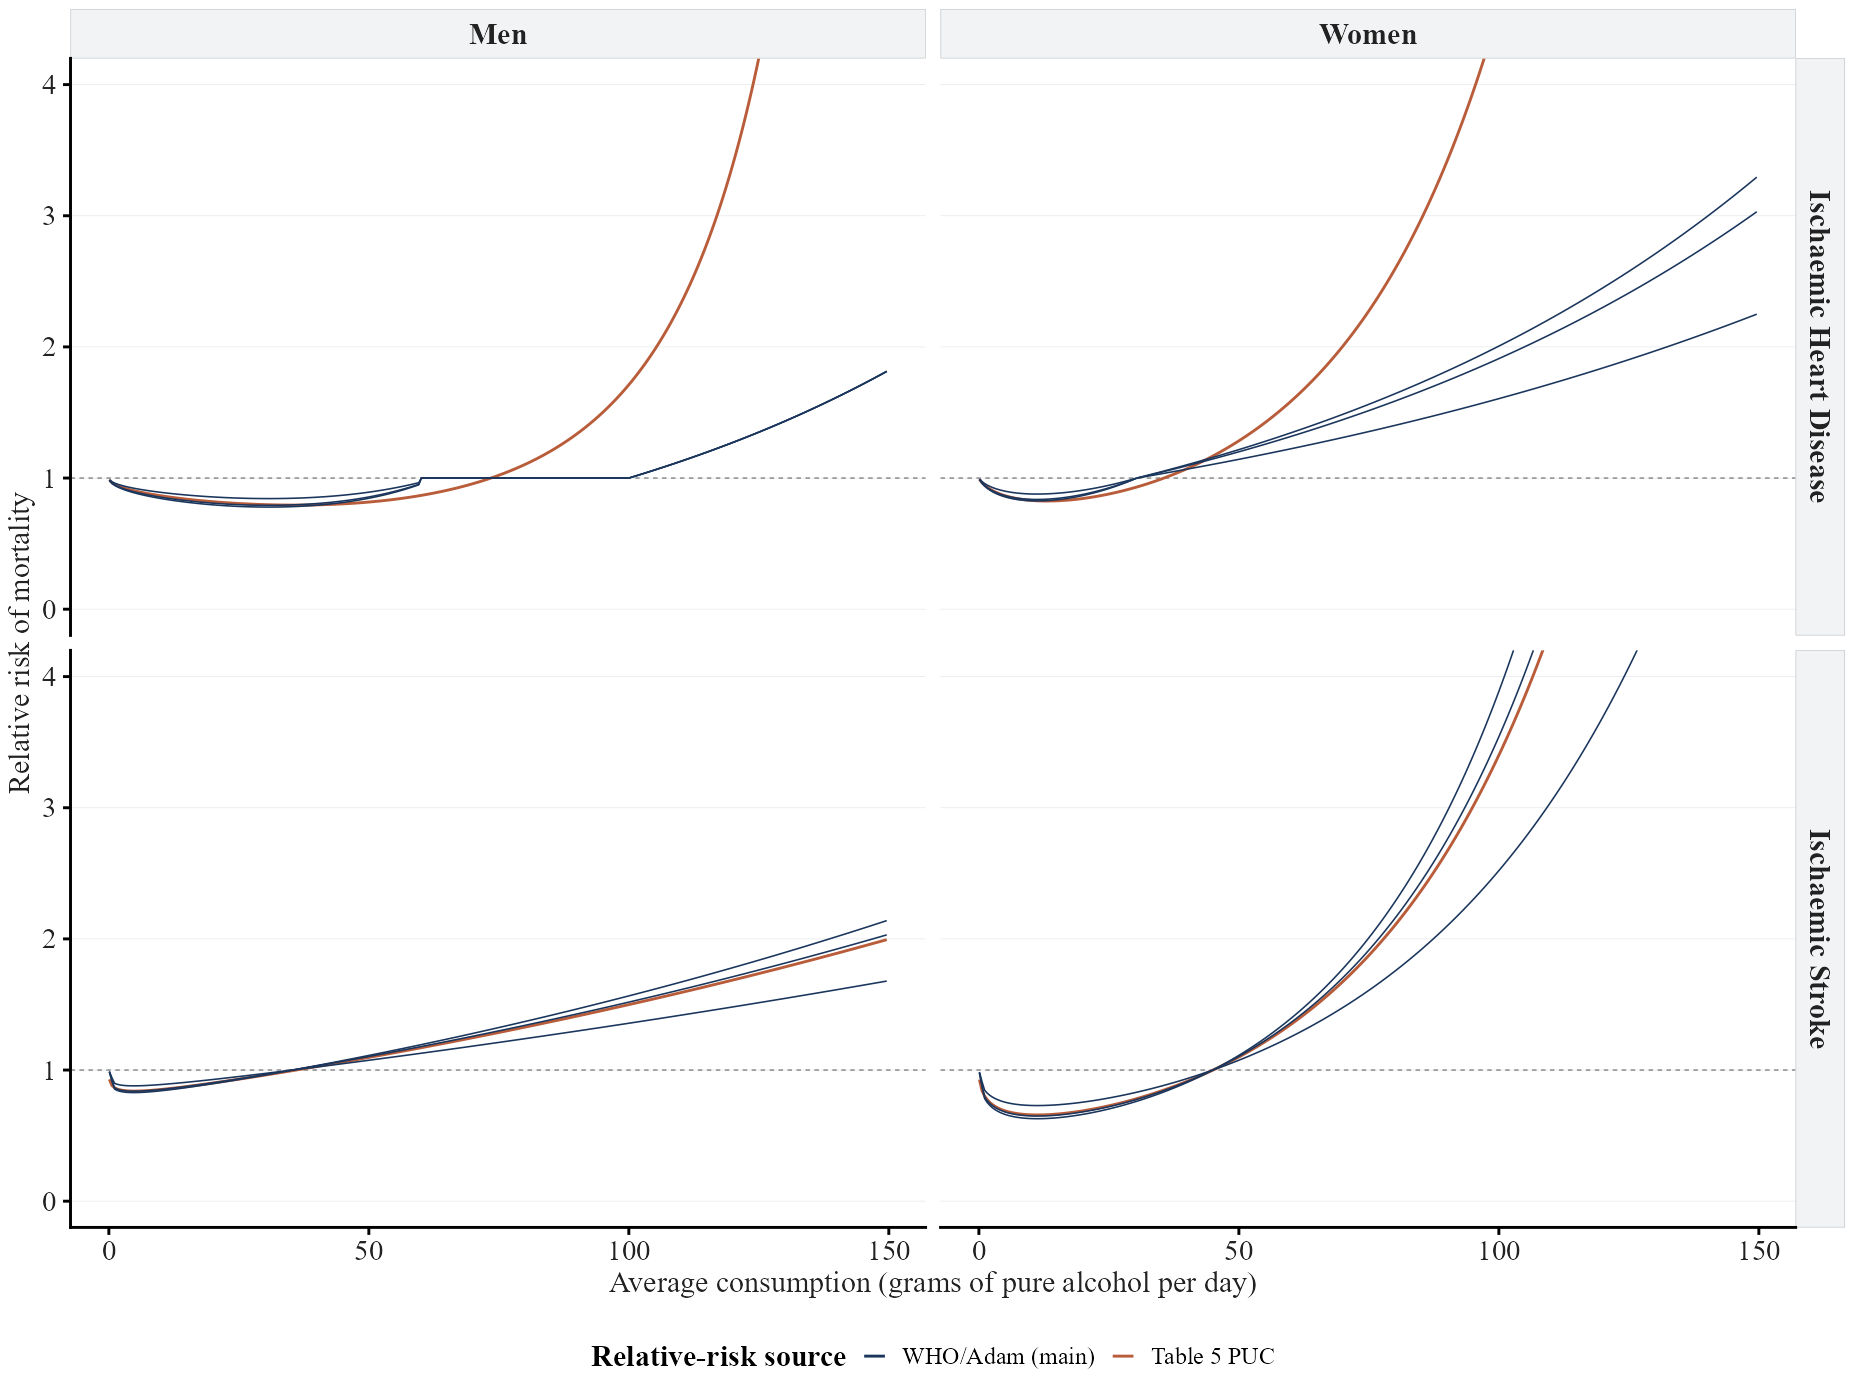

[export] Saved: figure8_ihd_is_rr_curve_mechanism.tiff and figure8_ihd_is_rr_curve_mechanism.pdf.
pif3-figure8-rr-curve-mechanism elapsed minutes: 0.01


In [78]:
#| label: pif3-figure8-rr-curve-mechanism
#| fig-width: 7.2 
#| fig-height: 5.2 
#| fig-dpi: 300

.t0 <- Sys.time()
pif3_rr_registry_loader <- base::file.path(pif3_dirs$control, "rr_registry_adam.R")
if (!base::exists("load_adam_rr_registry")) {
  if (!base::file.exists(pif3_rr_registry_loader)) base::stop("rr_registry_adam.R not found: ", pif3_rr_registry_loader)
  base::source(pif3_rr_registry_loader)
  pif3_message("[rr-curve] Sourced %s for load_adam_rr_registry().", base::basename(pif3_rr_registry_loader))
}
pif3_rr_registry_ihd <- load_adam_rr_registry(scope = "ihd", control_dir = pif3_dirs$control, verbose = FALSE)
pif3_rr_registry_is  <- load_adam_rr_registry(scope = "is",  control_dir = pif3_dirs$control, verbose = FALSE)
# Table 5 PUC closed forms and coefficients, replicated from aaf_table5_ihd_is_experiment.R.
pif3_table5_curves <- list(
  "Ischaemic Heart Disease::male"   = function(x) exp(-0.046271 * sqrt(x) + 0.000001 * x^3),
  "Ischaemic Heart Disease::female" = function(x) exp(-0.052526 * x + 0.014704 * x * base::log(x)),
  "Ischaemic Stroke::male"          = function(x) exp(-0.141950 * sqrt(x) + 0.039613 * sqrt(x) * base::log(x)),
  "Ischaemic Stroke::female"        = function(x) exp(-0.249674 * sqrt(x) + 0.037207 * x)
)
pif3_rr_grid <- base::seq(0.1, 150, by = 0.5)
pif3_rr_who_curve <- function(registry, disease_label, sex_key) {
  records <- registry[base::grepl(base::paste0("^", sex_key, "::"), base::names(registry))]
  dplyr::bind_rows(base::lapply(base::seq_along(records), function(i) {
    rec <- records[[i]]
    tibble::tibble(disease = disease_label, sex = sex_key, rr_source = "WHO/Adam (main)",
                   series = base::paste0("WHO band ", rec$adam_age_band), g_per_day = pif3_rr_grid,
                   rr = vapply(pif3_rr_grid, function(v) rec$RRCurrent(v, rec$betaCurrent), numeric(1)))
  }))
}
pif3_rr_table5_curve <- function(disease_label, sex_key) {
  fun <- pif3_table5_curves[[base::paste0(disease_label, "::", sex_key)]]
  tibble::tibble(disease = disease_label, sex = sex_key, rr_source = "Table 5 PUC",
                 series = "Table 5 PUC", g_per_day = pif3_rr_grid, rr = fun(pif3_rr_grid))
}
pif3_rr_curve_data <- dplyr::bind_rows(
  pif3_rr_who_curve(pif3_rr_registry_ihd, "Ischaemic Heart Disease", "male"),
  pif3_rr_who_curve(pif3_rr_registry_ihd, "Ischaemic Heart Disease", "female"),
  pif3_rr_who_curve(pif3_rr_registry_is,  "Ischaemic Stroke",        "male"),
  pif3_rr_who_curve(pif3_rr_registry_is,  "Ischaemic Stroke",        "female"),
  pif3_rr_table5_curve("Ischaemic Heart Disease", "male"),
  pif3_rr_table5_curve("Ischaemic Heart Disease", "female"),
  pif3_rr_table5_curve("Ischaemic Stroke",        "male"),
  pif3_rr_table5_curve("Ischaemic Stroke",        "female")
) |>
  dplyr::mutate(sex_label = base::unname(pif3_sex_labels[.data$sex]),
                rr_source = base::factor(.data$rr_source, levels = pif3_rr_source_levels))
pif3_fig8 <- ggplot2::ggplot(pif3_rr_curve_data,
                             ggplot2::aes(x = .data$g_per_day, y = .data$rr,
                                          colour = .data$rr_source, group = .data$series)) +
  ggplot2::geom_hline(yintercept = 1, colour = "#666666", linewidth = 0.35, linetype = "dashed") +
  ggplot2::geom_line(ggplot2::aes(linewidth = .data$rr_source)) +
  ggplot2::facet_grid(rows = ggplot2::vars(.data$disease), cols = ggplot2::vars(.data$sex_label),
                      scales = "free_y") +
  ggplot2::scale_colour_manual(values = pif3_rr_source_colors) +
  ggplot2::scale_linewidth_manual(values = c("WHO/Adam (main)" = 0.5, "Table 5 PUC" = 0.9), guide = "none") +
  ggplot2::coord_cartesian(ylim = c(0, 4)) +
  ggplot2::labs(x = "Average consumption (grams of pure alcohol per day)",
                y = "Relative risk of mortality", colour = "Relative-risk source") +
  pif3_theme()
base::print(pif3_fig8+ pif3_theme(base_size=20))
pif3_save_plot(pif3_fig8, "figure8_ihd_is_rr_curve_mechanism", width = 7.2, height = 5.2)
base::message(base::sprintf("pif3-figure8-rr-curve-mechanism elapsed minutes: %.2f", pif3_elapsed_min(.t0)))




Table: Uncertainty intervals extending beyond the plotted range (display cap 4.1%)

disease                   sex_label   rr_source      intervals_beyond_panel
------------------------  ----------  ------------  -----------------------
Ischaemic Heart Disease   Women       Table 5 PUC                        12


Table: Table 5 PUC Monte Carlo upper-tail behaviour by cause and sex

disease                   sex       cells   median_pif   upper_above_50pct   upper_above_90pct
------------------------  -------  ------  -----------  ------------------  ------------------
Ischaemic Heart Disease   female      420       0.0047                 231                 147
Ischaemic Heart Disease   male        420       0.0139                   0                   0
Ischaemic Stroke          female      420       0.0103                   0                   0
Ischaemic Stroke          male        420       0.0116                   0                   0


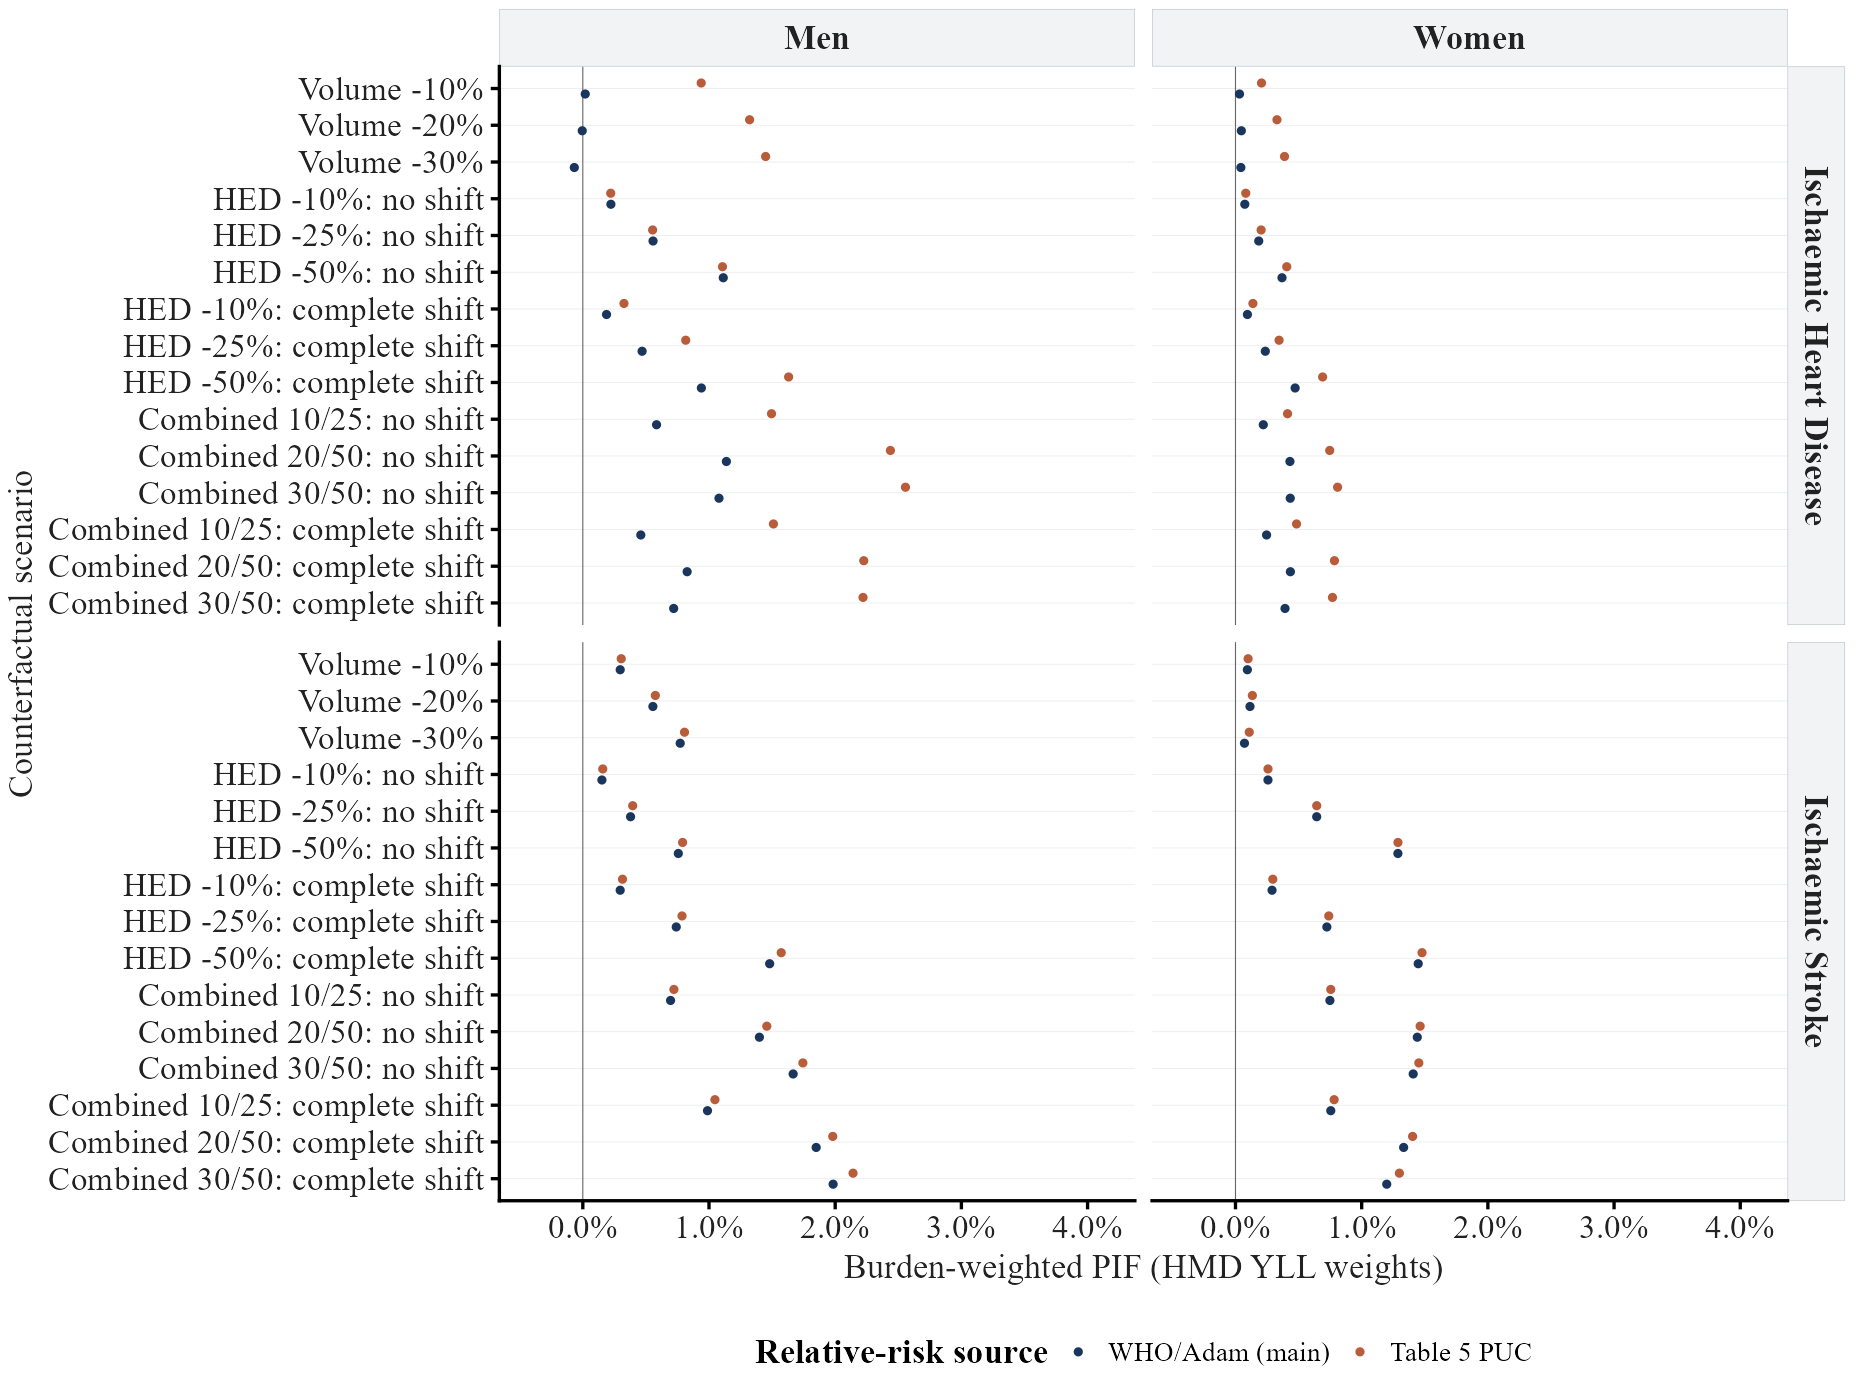

[export] Saved: figure6_table5_vs_who_ihd_is.tiff and figure6_table5_vs_who_ihd_is.pdf.
pif3-figure6-table5-rr-comparison elapsed minutes: 0.01


In [68]:
#| label: pif3-figure6-table5-rr-comparison

.t0 <- Sys.time()
pif3_rr_source_colors <- c("WHO/Adam (main)" = pif3_palette[["navy"]], "Table 5 PUC" = pif3_palette[["rust"]])
pif3_fig6_year <- base::max(pif3_cv_weighted$year)
# Baseline is dropped from the level set as well as from the data, otherwise coord_flip
# would render an empty "Baseline" row at the top of every panel.
pif3_fig6_levels <- base::unname(pif3_scenario_short[base::rev(base::setdiff(pif3_scenario_order, "baseline"))])
pif3_fig6_data <- pif3_cv_weighted |>
  dplyr::filter(.data$year == pif3_fig6_year, .data$scenario_id != "baseline") |>
  dplyr::mutate(scenario_short = base::factor(.data$scenario_short, levels = pif3_fig6_levels))

pif3_fig6_interval_data <- pif3_fig6_data |>
  dplyr::filter(
    base::is.finite(.data$pif_low),
    base::is.finite(.data$pif_up)
  )
pif3_assert(
  base::nrow(pif3_fig6_interval_data) > 0L,
  "Figure 6 has no valid joint intervals to display."
)
# The Table 5 IHD-female Monte Carlo upper tail is degenerate: a large share of its cells
# return upper limits near 1 while the point estimate stays near zero. Plotting the raw range
# would compress every other estimate into an unreadable strip at the left edge, so the panel
# is bounded by a high percentile of the upper limits and the overflow is counted, not hidden.
pif3_fig6_cap <- base::max(
  stats::quantile(
    pif3_fig6_interval_data$pif_up,
    probs = 0.90,
    names = FALSE
  ),
  base::max(
    pif3_fig6_data$pif,
    na.rm = TRUE
  )
) * 1.05
pif3_fig6_truncated <- pif3_fig6_interval_data |>
  dplyr::filter(.data$pif_up > pif3_fig6_cap) |>
  dplyr::count(
    .data$disease,
    .data$sex_label,
    .data$rr_source,
    name = "intervals_beyond_panel"
  )
# Construct the plot
pif3_fig6 <- ggplot2::ggplot(
  pif3_fig6_data,
  ggplot2::aes(x = .data$scenario_short, y = .data$pif, colour = .data$rr_source)
) +
  ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.35) +
  ggplot2::geom_point(position = ggplot2::position_dodge(width = 0.6), size = 1.5) +
  # The Table 5 IHD-female Monte Carlo upper tail is degenerate (see the diagnostic below), so
  # the panel is limited to a readable range. coord_flip(ylim = ...) clips the display only; no
  # row is dropped, and the number of intervals running past the edge is reported explicitly.
  ggplot2::coord_flip(
    ylim = c(
      base::min(
        pif3_fig6_interval_data$pif_low
      ),
      pif3_fig6_cap
    )
  )+
  ggplot2::facet_grid(rows = ggplot2::vars(.data$disease), cols = ggplot2::vars(.data$sex_label)) +
  ggplot2::scale_colour_manual(values = pif3_rr_source_colors) +
  ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  ggplot2::labs(x = "Counterfactual scenario", y = "Burden-weighted PIF (HMD YLL weights)",
                colour = "Relative-risk source") +
  pif3_theme()

pif3_fig6_preview <- pif3_fig6 + pif3_theme(base_size = 23)

base::print(pif3_fig6_preview)

if (base::nrow(pif3_fig6_truncated)) {
  base::print(knitr::kable(pif3_fig6_truncated, format = "simple",
                           caption = base::sprintf("Uncertainty intervals extending beyond the plotted range (display cap %.1f%%)",
                                                   100 * pif3_fig6_cap)))
}
# Degenerate-tail diagnostic for the cell-level Table 5 grid, independent of the display cap.
pif3_table5_tail <- pif3_cv_table5_raw |>
  dplyr::filter(.data$scenario_id != "baseline", .data$applicable, base::is.finite(.data$pif_up)) |>
  dplyr::group_by(.data$disease, .data$sex) |>
  dplyr::summarise(cells = dplyr::n(),
                   median_pif = stats::median(.data$pif),
                   upper_above_50pct = base::sum(.data$pif_up > 0.5),
                   upper_above_90pct = base::sum(.data$pif_up > 0.9),
                   .groups = "drop")
base::print(knitr::kable(pif3_table5_tail, format = "simple", digits = 4,
                         caption = "Table 5 PUC Monte Carlo upper-tail behaviour by cause and sex")) 
pif3_save_plot(pif3_fig6, "figure6_table5_vs_who_ihd_is", width = 7.2, height = 6.4)
base::message(base::sprintf("pif3-figure6-table5-rr-comparison elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Translating to PIFs

There are 16 missing rows come from PUC-IHD for women, joint ICs are valid, but the deterministic points is below the lower bound. This can occur because point estimates use fixed coeeficients and the interval use the Monte Carlo distribution.

In [74]:
#| label: pif3-table-s4-table5-comparison                                                                                                                 
#| results: "asis"                                                                                                                                        
.t0 <- base::Sys.time()                                                                                                                                   
# Verify that both source-specific joint-draw summaries exist before building Table S4.                                                                   
pif3_assert(                                                                                                                                              
  base::exists("pif3_cv_weighted") &&                                                                                                                     
    base::exists("pif3_draw_bundle") &&                                                                                                                   
    base::exists("pif3_table5_draw_bundle"),                                                                                                              
  "Table S4 requires completed WHO/Adam and Table 5 PUC joint-draw summaries."                                                                            
)                                                                                                                                                         
# Require exactly one result from each RR source for every comparison cell.                                                                               
pif3_table_s4_source_check <- pif3_cv_weighted |>                                                                                                         
  dplyr::group_by(                                                                                                                                        
    .data$year,                                                                                                                                           
    .data$disease,                                                                                                                                        
    .data$sex_label,                                                                                                                                      
    .data$scenario_id                                                                                                                                     
  ) |>                                                                                                                                                    
  dplyr::summarise(                                                                                                                                       
    source_count = dplyr::n_distinct(.data$rr_source),                                                                                                    
    .groups = "drop"                                                                                                                                      
  )                                                                                                                                                       
pif3_assert(                                                                                                                                              
  base::all(pif3_table_s4_source_check$source_count == 2L),                                                                                               
  "Table S4 does not contain exactly one WHO/Adam and one Table 5 PUC result per comparison cell."                                                        
)                                                                                                                                                         
# Joint intervals must be finite and ordered, but they do not need to contain the deterministic point estimate.                                           
pif3_assert(                                                                                                                                              
  base::all(base::is.finite(pif3_cv_weighted$pif_low)) &&                                                                                                 
    base::all(base::is.finite(pif3_cv_weighted$pif_up)) &&                                                                                                
    base::all(pif3_cv_weighted$pif_low <= pif3_cv_weighted$pif_up),                                                                                       
  "Table S4 received non-finite or reversed joint PIF intervals."                                                                                         
)                                                                                                                                                         
# Add interval provenance and explicitly flag when the deterministic point lies outside its joint draw interval.                                          
pif3_table_s4_input <- pif3_cv_weighted |>                                                                                                                
  dplyr::mutate(                                                                                                                                          
    interval_n_sim = dplyr::if_else(                                                                                                                      
      .data$rr_source == "WHO/Adam (main)",                                                                                                               
      base::as.integer(pif3_draw_bundle$n_sim),                                                                                                           
      base::as.integer(pif3_table5_draw_bundle$n_sim)                                                                                                     
    ),                                                                                                                                                    
    point_inside_joint_interval =                                                                                                                         
      .data$pif >= .data$pif_low &                                                                                                                        
      .data$pif <= .data$pif_up                                                                                                                           
  )                                                                                                                                                       
# Pivot the two independently aggregated RR-source results into one auditable comparison row.                                                             
pif3_table_s4 <- pif3_table_s4_input |>                                                                                                                   
  dplyr::select(                                                                                                                                          
    dplyr::all_of(c(
      "year",                                                                                                                                             
      "disease",                                                                                                                                          
      "sex_label",                                                                                                                                        
      "scenario_id",                                                                                                                                      
      "scenario_short",                                                                                                                                   
      "rr_source",                                                                                                                                        
      "observed_burden",                                                                                                                                  
      "avoidable_burden",                                                                                                                                 
      "avoidable_burden_low",                                                                                                                             
      "avoidable_burden_up",                                                                                                                              
      "pif",                                                                                                                                              
      "pif_low",                                                                                                                                          
      "pif_up",                                                                                                                                           
      "cells",                                                                                                                                            
      "interval_n_sim",                                                                                                                                   
      "interval_method",                                                                                                                                  
      "point_inside_joint_interval"                                                                                                                       
    ))                                                                                                                                                    
  ) |>                                                                                                                                                    
  tidyr::pivot_wider(                                                                                                                                     
    id_cols = dplyr::all_of(c(                                                                                                                            
      "year",                                                                                                                                             
      "disease",                                                                                                                                          
      "sex_label",                                                                                                                                        
      "scenario_id",                                                                                                                                      
      "scenario_short"                                                                                                                                    
    )),                                                                                                                                                   
    names_from = "rr_source",                                                                                                                             
    values_from = dplyr::all_of(c(                                                                                                                        
      "observed_burden",                                                                                                                                  
      "avoidable_burden",                                                                                                                                 
      "avoidable_burden_low",                                                                                                                             
      "avoidable_burden_up",                                                                                                                              
      "pif",                                                                                                                                              
      "pif_low",                                                                                                                                          
      "pif_up",                                                                                                                                           
      "cells",                                                                                                                                            
      "interval_n_sim",                                                                                                                                   
      "interval_method",                                                                                                                                  
      "point_inside_joint_interval"                                                                                                                       
    )),                                                                                                                                                   
    names_sep = "__"                                                                                                                                      
  ) |>                                                                                                                                                    
  dplyr::arrange(                                                                                                                                         
    .data$disease,                                                                                                                                        
    .data$sex_label,                                                                                                                                      
    .data$year,                                                                                                                                           
    base::match(.data$scenario_id, pif3_scenario_order)                                                                                                   
  )                                                                                                                                                       
# Save the complete longitudinal supplementary table with joint-draw provenance.                                                                          
pif3_write_table(                                                                                                                                         
  pif3_table_s4,                                                                                                                                          
  "tableS4_ihd_is_who_vs_table5_pif_2012_2024.csv"                                                                                                        
)
# Display the latest non-baseline comparison, including the interval method and point-versus-interval flag.                                               
pif3_show_table(                                                                                                                                          
  pif3_table_s4 |>                                                                                                                                        
    dplyr::filter(                                                                                                                                        
      .data$year == pif3_fig6_year,                                                                                                                       
      .data$scenario_id != "baseline"                                                                                                                     
    ) |>                                                                                                                                                  
    dplyr::select(                                                                                                                                        
      dplyr::all_of(c(                                                                                                                                    
        "disease",                                                                                                                                        
        "sex_label",                                                                                                                                      
        "scenario_short"                                                                                                                                  
      )),                                                                                                                                                 
      tidyselect::starts_with("avoidable_burden__"),                                                                                                      
      tidyselect::starts_with("pif__"),                                                                                                                   
      tidyselect::starts_with("interval_n_sim__"),                                                                                                        
      tidyselect::starts_with("point_inside_joint_interval__"),                                                                                           
      tidyselect::starts_with("interval_method__")                                                                                                        
    ),                                                                                                                                                    
  digits = 4,                                                                                                                                             
  caption = "Supplementary Table S4. WHO/Adam versus Table 5 PUC burden-weighted PIFs with source-specific joint synchronized-draw intervals."            
)                                                                                                                                                         
pif3_message(
  "[table5] Supplementary Table S4 rows: %d.",                                                                                                            
  base::nrow(pif3_table_s4)                                                                                                                               
)                                                                                                                                                         
base::message(base::sprintf(                                                                                                                              
  "pif3-table-s4-table5-comparison elapsed minutes: %.2f",                                                                                                
  pif3_elapsed_min(.t0)                                                                                                                                   
))  

[table export] Saved 448 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS4_ihd_is_who_vs_table5_pif_2012_2024.csv.


disease,sex_label,scenario_short,avoidable_burden__WHO/Adam (main),avoidable_burden__Table 5 PUC,pif__WHO/Adam (main),pif__Table 5 PUC,interval_n_sim__WHO/Adam (main),interval_n_sim__Table 5 PUC,point_inside_joint_interval__WHO/Adam (main),point_inside_joint_interval__Table 5 PUC,interval_method__WHO/Adam (main),interval_method__Table 5 PUC
Ischaemic Heart Disease,Men,Volume -10%,10.8502,529.1339,0.0002,0.0094,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,Volume -20%,-2.5795,745.4587,0.0000,0.0132,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,Volume -30%,-38.0099,817.0861,-0.0007,0.0145,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,HED -10%: no shift,125.5467,124.8400,0.0022,0.0022,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,HED -25%: no shift,313.8667,312.0999,0.0056,0.0055,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,HED -50%: no shift,627.7334,624.1998,0.0111,0.0111,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,HED -10%: complete shift,105.9870,183.9730,0.0019,0.0033,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,HED -25%: complete shift,264.9675,459.9325,0.0047,0.0082,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,HED -50%: complete shift,529.9350,919.8650,0.0094,0.0163,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed
Ischaemic Heart Disease,Men,Combined 10/25: no shift,329.5775,843.4138,0.0058,0.0150,10000,10000,TRUE,TRUE,Joint 2.5% and 97.5% quantiles across synchronized WHO/Adam PIF draws; burden weights fixed,Joint 2.5% and 97.5% quantiles across synchronized Table 5 PUC PIF draws; burden weights fixed


[table5] Supplementary Table S4 rows: 448.
pif3-table-s4-table5-comparison elapsed minutes: 0.00


 - HED-only scenarios agree substantially, mainly due to HED/binge component of the RR function is nearly identical across sources.
 - Pure volume scenarios diverge sharply and WHO show a reversal, where cutting men's average volume might increase IHD mortality burden. 
 - Sign disagreements are concentrated in men.
 - Complete shif and combined scenarios inherit the volume-reduction impact.
 - IS stays clean across every scenario

[latest-file] Pattern: ^pif2_pif_results_table5_full_([0-9]{8})\.rds$
[latest-file] Candidate count: 1
[latest-file] Selected by embedded date: pif2_pif_results_table5_full_20260723.rds
[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_table5_full_20260723.rds


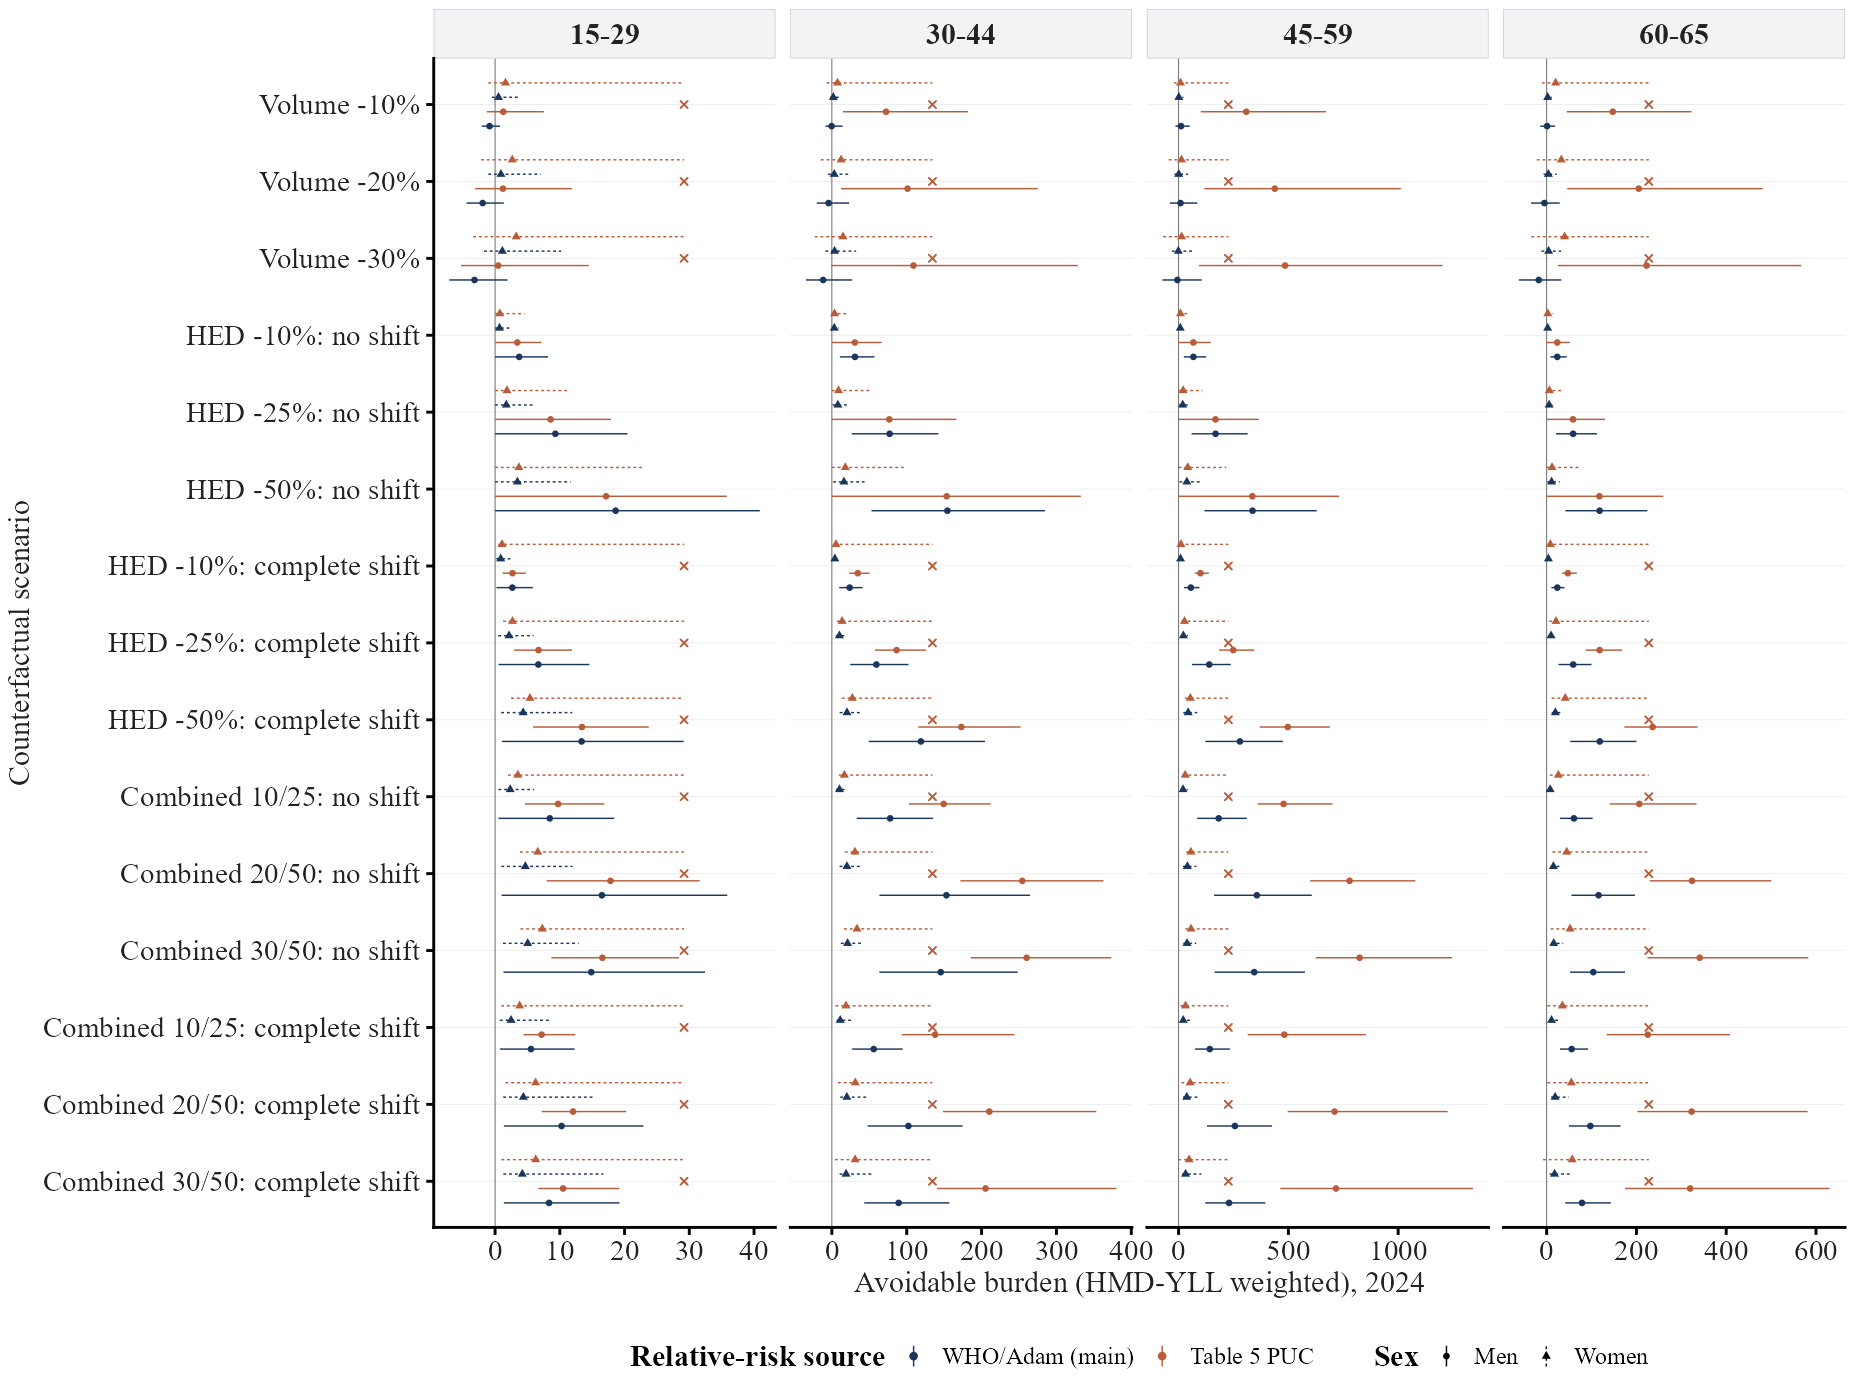

[export] Saved: figure_burden_who_vs_table5_ihd.tiff and figure_burden_who_vs_table5_ihd.pdf.


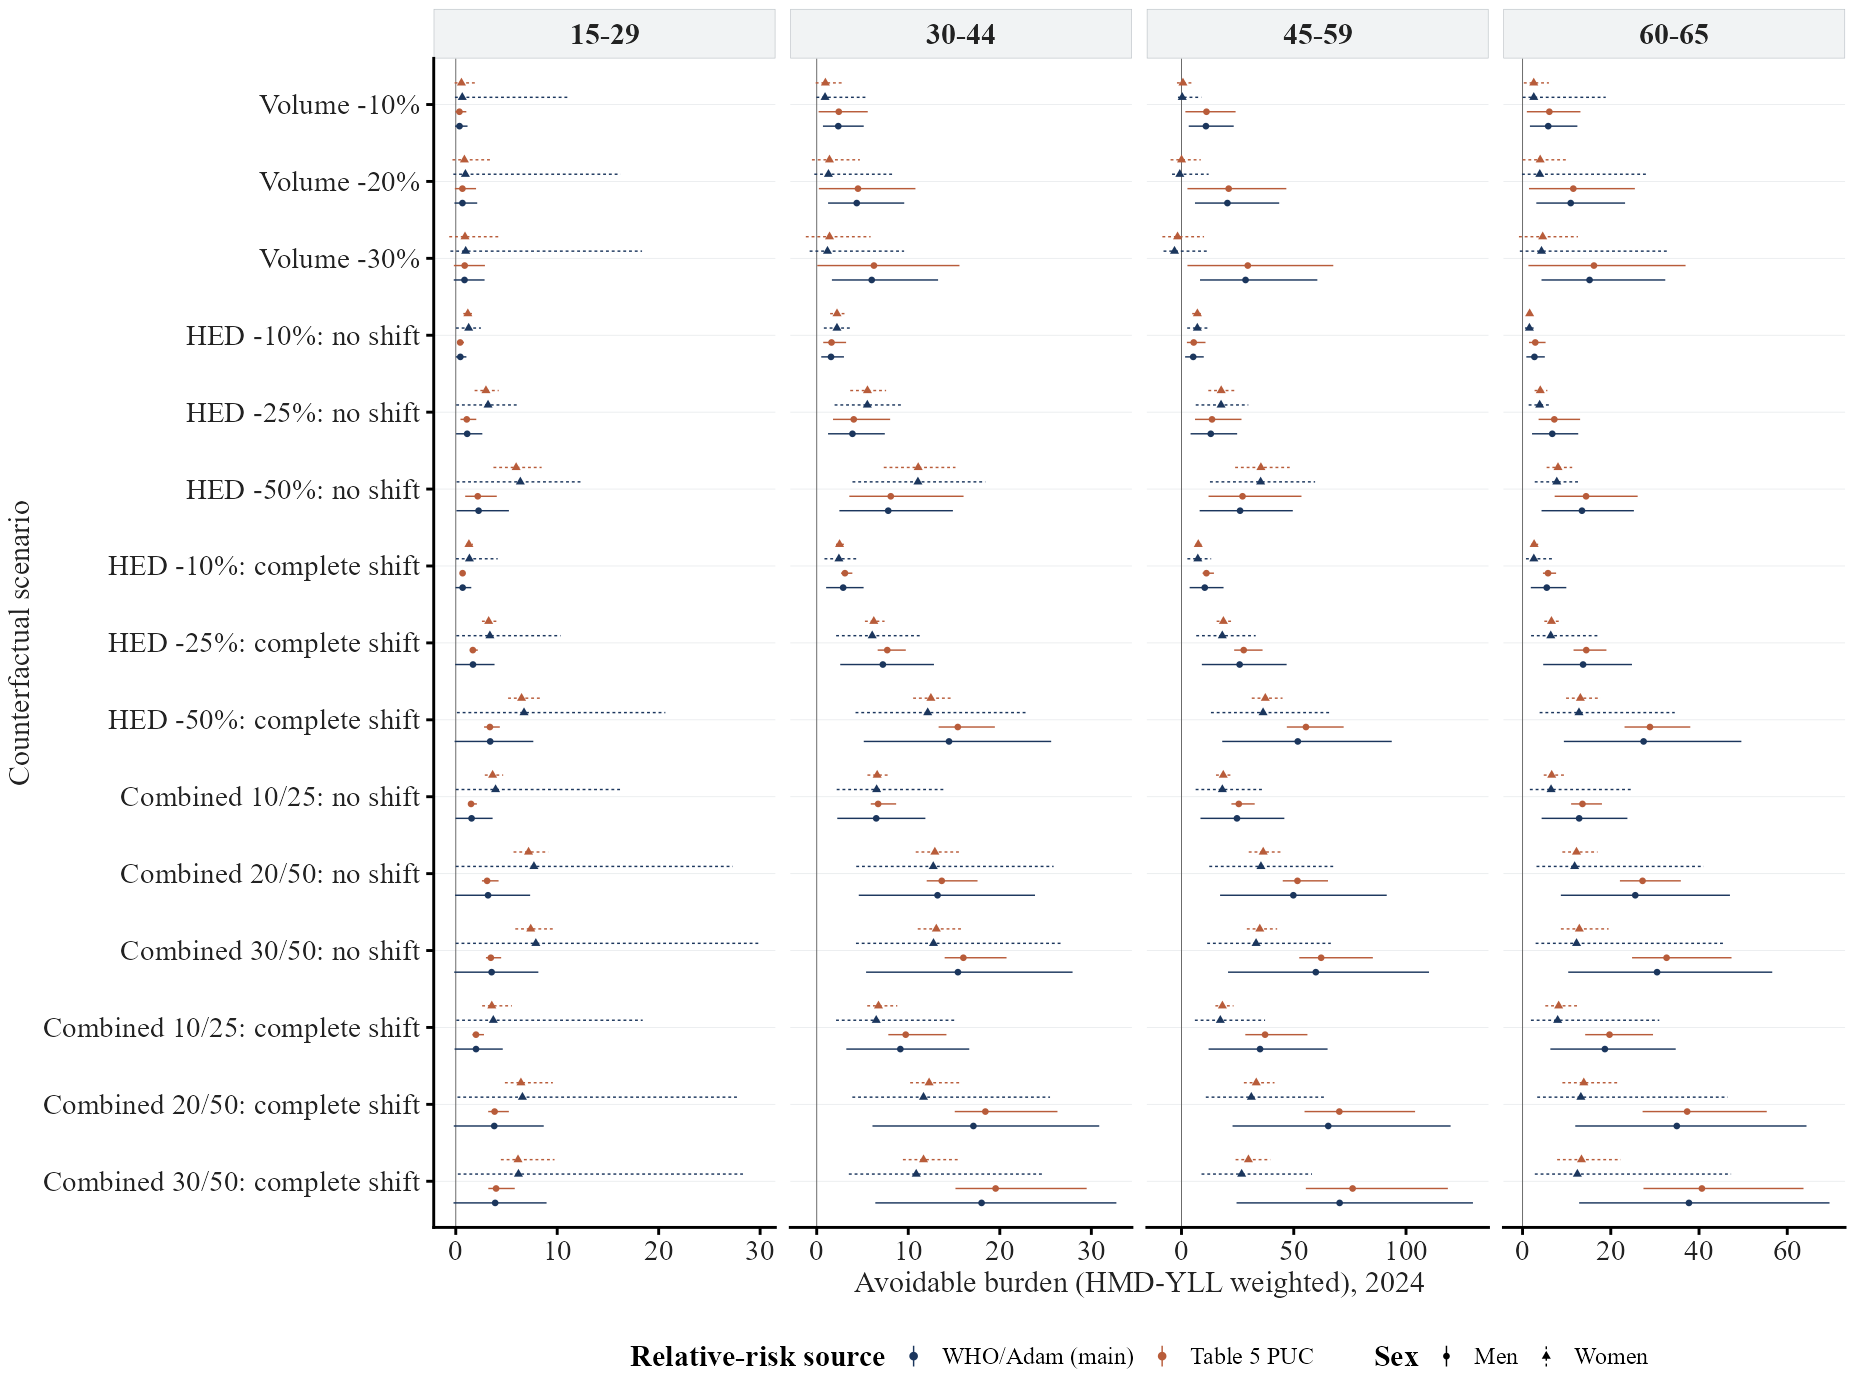

[export] Saved: figure_burden_who_vs_table5_is.tiff and figure_burden_who_vs_table5_is.pdf.
pif3-figure-burden-who-vs-table5 elapsed minutes: 0.05


In [76]:
#| label: pif3-figure-burden-who-vs-table5
#| fig-width: 11
#| fig-height: 6.8
#| fig-dpi: 300
.t0 <- Sys.time()
# One chunk, ONE figure per cause (IHD, then IS): avoidable HMD-YLL burden, WHO/Adam vs Table 5
# PUC relative risks, by age group (panels), year 2024, with cell-level lower and upper limits.
# Colour = relative-risk source; SEX = line type and point shape. Loads the latest Table 5 PUC
# grid and reuses the notebook's own pif3_burden for the WHO/Adam source.
pif3_cv_levels <- c("WHO/Adam (main)", "Table 5 PUC")
pif3_cv_diseases <- c("Ischaemic Heart Disease", "Ischaemic Stroke")
pif3_t5_burden <- pif3_read_rds(pif3_latest_dated_file(pif3_dirs$control, "pif2_pif_results_table5_full")) |>
  tibble::as_tibble() |>
  dplyr::select(-dplyr::any_of(c("hed_exit_mix", "hed_exit_shift", "exit_rule", "scale",
                                 "rr_source", "policy_vol_lever_pct", "implied_vol_change_pct"))) |>
  pif3_enrich_pif() |>
  dplyr::mutate(rr_source = "Table 5 PUC")
pif3_burden_compare <- dplyr::bind_rows(
  pif3_burden |>
    dplyr::filter(.data$disease %in% pif3_cv_diseases) |>
    dplyr::mutate(rr_source = "WHO/Adam (main)"),
  pif3_t5_burden
) |>
  dplyr::filter(.data$year == 2024, .data$applicable, base::is.finite(.data$avoidable_yll_hmd),
                .data$scenario_id != "baseline") |>
  dplyr::mutate(
    rr_source = base::factor(.data$rr_source, levels = pif3_cv_levels),
    sex_label = base::factor(.data$sex_label, levels = c("Men", "Women")),
    age_label = base::factor(.data$age_label, levels = base::unname(pif3_age_labels)),
    scenario_short = base::factor(base::unname(pif3_scenario_short[.data$scenario_id]),
                                  levels = base::unname(pif3_scenario_short[base::rev(base::setdiff(pif3_scenario_order, "baseline"))])),
    series = base::interaction(.data$rr_source, .data$sex_label, drop = TRUE)
  ) |>
  # Per-series (disease x age x sex) display cap: Table 5 IHD-female upper limit is degenerate
  # (missing b1/b2 covariance). Cap each sex against its OWN effect size so a female clipped line
  # does not span the whole panel; never clip the WHO/Adam source.
  dplyr::group_by(.data$disease, .data$age_label, .data$sex_label) |>
  dplyr::mutate(
    cap = base::max(4 * base::max(base::abs(.data$avoidable_yll_hmd)),
                    1.05 * base::max(.data$avoidable_yll_hmd_up[.data$rr_source == "WHO/Adam (main)"])),
    up_display = base::pmin(.data$avoidable_yll_hmd_up, .data$cap),
    clipped = .data$avoidable_yll_hmd_up > .data$cap
  ) |>
  dplyr::ungroup()
pif3_dodge <- ggplot2::position_dodge(width = 0.75)
pif3_burden_disease_fig <- function(cause) {
  dat <- pif3_burden_compare |> dplyr::filter(.data$disease == cause)
  ggplot2::ggplot(dat, ggplot2::aes(x = .data$scenario_short, y = .data$avoidable_yll_hmd,
                                    colour = .data$rr_source, linetype = .data$sex_label,
                                    shape = .data$sex_label, group = .data$series)) +
    ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.3) +
    ggplot2::geom_linerange(ggplot2::aes(ymin = .data$avoidable_yll_hmd_low, ymax = .data$up_display),
                            position = pif3_dodge, linewidth = 0.45) +
    ggplot2::geom_point(position = pif3_dodge, size = 1.5) +
    ggplot2::geom_point(data = dplyr::filter(dat, .data$clipped), ggplot2::aes(y = .data$up_display),
                        position = pif3_dodge, shape = 4, size = 1.6, show.legend = FALSE) +
    ggplot2::coord_flip() +
    ggplot2::facet_wrap(ggplot2::vars(.data$age_label), nrow = 1, scales = "free_x") +
    ggplot2::scale_colour_manual(values = c("WHO/Adam (main)" = pif3_palette[["navy"]], "Table 5 PUC" = pif3_palette[["rust"]])) +
    ggplot2::scale_linetype_manual(values = c("Men" = "solid", "Women" = "22")) +
    ggplot2::scale_shape_manual(values = c("Men" = 16, "Women" = 17)) +
    ggplot2::labs(x = "Counterfactual scenario", y = "Avoidable burden (HMD-YLL weighted), 2024",
                  colour = "Relative-risk source", linetype = "Sex", shape = "Sex") +
    pif3_theme(base_size = 8)
}
pif3_fig_burden_ihd <- pif3_burden_disease_fig("Ischaemic Heart Disease")
base::print(pif3_fig_burden_ihd+ pif3_theme(base_size=20))
pif3_save_plot(pif3_fig_burden_ihd, "figure_burden_who_vs_table5_ihd", width = 11, height = 6.8)
pif3_fig_burden_is <- pif3_burden_disease_fig("Ischaemic Stroke")
base::print(pif3_fig_burden_is+ pif3_theme(base_size=20))
pif3_save_plot(pif3_fig_burden_is, "figure_burden_who_vs_table5_is", width = 11, height = 6.8)
base::message(base::sprintf("pif3-figure-burden-who-vs-table5 elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


## References

Kilian C, Buckley C, Lemp JM, et al. Targeting alcohol use in high risk population groups: a US microsimulation study of beverage-specific pricing policies. *The Lancet Public Health*. 2025. https://doi.org/10.1016/S2468-2667(25)00165-3

Shield K, Franklin A, Wettlaufer A, et al. National, regional, and global statistics on alcohol consumption and associated burden of disease 2000-20: a modelling study and comparative risk assessment. *The Lancet Public Health*. 2025;10:e751.

Roerecke M, Rehm J. The cardioprotective association of average alcohol consumption and ischaemic heart disease: a systematic review and meta-analysis. Addiction. 2012 Jul;107(7):1246-60. doi: 10.1111/j.1360-0443.2012.03780.x. Epub 2012 Mar 21. PMID: 22229788; PMCID: PMC3348338.

## Reporting notes for a manuscript

- Report the intervention as a **relative reduction** in average consumption or HED prevalence, not as a percentage-point reduction.
- State the ex-HED assignment rule whenever an HED or combined scenario is reported; this notebook uses the concise labels “No shift” and “Complete shift”.
- Use HMD YLL for national estimates and GBD YLL for international comparability; do not mix or sum the definitions.
- Describe negative PIFs as modeled increases in burden under the counterfactual and retain them in totals.
- Describe non-applicable HED scenarios as structurally undefined for volume-only causes, not as null effects.
- Interpret “2012–2024” summaries as the seven complete modeled years listed above.
- If aggregate 95% uncertainty intervals are required for a manuscript, rerun the engine while retaining synchronized simulation draws across cells. The summed limits in this notebook are descriptive envelopes, not a substitute for joint propagation.

The visual conventions are compatible with a restrained epidemiology-journal style: high contrast, no decorative backgrounds, limited colors, direct units, 600-dpi TIFF exports, and vector PDF companions.


# Session info


In [77]:
#| label: pif3-session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
.t0 <- Sys.time()
base::message(base::paste0("R library: ", base::Sys.getenv("R_LIBS_USER")))
base::message(base::paste0("Date: ", withr::with_locale(new = c("LC_TIME" = "C"), code = base::Sys.time())))
base::message(base::paste0("Editor context: ", base::getwd()))
pif3_quarto_executable <- base::Sys.which("quarto")
if (base::nzchar(pif3_quarto_executable)) {
  pif3_quarto_version <- base::tryCatch(base::system2(pif3_quarto_executable, "--version", stdout = TRUE, stderr = FALSE)[[1L]], error = function(e) base::paste0("unavailable: ", base::conditionMessage(e)))
  base::message(base::paste0("Quarto version: ", pif3_quarto_version))
} else {
  base::message("Quarto command-line executable was not found on PATH.")
}
pif3_session_info <- utils::sessionInfo()
base::print(pif3_session_info)
pif3_package_descriptions <- c(pif3_session_info$otherPkgs, pif3_session_info$loadedOnly)
tabla_pkg <- tibble::tibble(Package = base::names(pif3_package_descriptions), Version = base::vapply(pif3_package_descriptions, function(package) package$Version, character(1)), Source = base::vapply(pif3_package_descriptions, function(package) if (base::is.null(package$Repository)) "local" else package$Repository, character(1)))
tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "Row number")
pif3_session_table <- knitr::kable(tabla_pkg, format = "html", table.attr = "style='border-collapse:collapse;width:max-content;min-width:100%;white-space:nowrap;font-family:Arial,sans-serif;font-size:70%;'")
htmltools::browsable(htmltools::tags$div(style = "max-height:420px;overflow:auto;border:1px solid #ddd;width:100%;", htmltools::tags$p(style = "font-family:Arial,sans-serif;font-size:84%;font-style:italic;margin:6px 4px;", "R packages"), htmltools::HTML(pif3_session_table)))
base::message(base::sprintf("pif3-session-info elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


R library: C:\Users\nDP\AppData\Local/R/win-library/4.4
Date: 2026-07-24 12:43:01.874691
Editor context: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control
Quarto version: 1.9.38
R version 4.4.1 (2024-06-14 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default


locale:
[1] LC_COLLATE=Spanish_Chile.utf8  LC_CTYPE=Spanish_Chile.utf8   
[3] LC_MONETARY=Spanish_Chile.utf8 LC_NUMERIC=C                  
[5] LC_TIME=Spanish_Chile.utf8    

time zone: America/Santiago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] tibble_3.3.1 purrr_1.2.1  dplyr_1.2.0 

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       compiler_4.4.1     renv_1.2.2         tidyselect_1.2.1  
 [5] stringr_1.6.0      snakecase_0.11.1   tidyr_1.3.2        textshaping_1.0.5 
 [9] systemfonts_1.3.2  scales_1.4.0       fastmap_1.2.0      readxl_1.4.5

Row number,Package,Version,Source
1,tibble,3.3.1,CRAN
2,purrr,1.2.1,CRAN
3,dplyr,1.2.0,CRAN
4,gtable,0.3.6,CRAN
5,compiler,4.4.1,local
6,renv,1.2.2,CRAN
7,tidyselect,1.2.1,CRAN
8,stringr,1.6.0,CRAN
9,snakecase,0.11.1,CRAN
10,tidyr,1.3.2,CRAN


pif3-session-info elapsed minutes: 0.00
